Install Required Libraries
To ensure all required libraries are available, install the following:
1. **kagglehub**: Used to easily download datasets from Kaggle.
2. **xgboost**: A gradient boosting framework for building and training tree-based models, widely used for structured data.
3. **lightgbm**: A highly efficient gradient boosting framework optimized for speed, memory usage, and performance, especially for large datasets.
4. **mplfinance**: A library for creating financial visualizations, such as candlestick charts and other market-specific plots.


In [ ]:
!pip install kagglehub xgboost lightgbm mplfinance dask[dataframe]

INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 11.1 MB/s eta 0:00:00


Import Required Libraries

Libraries for Data Manipulation and Analysis:
- **pandas**: For data manipulation, analysis, and creating time series visualizations (e.g., autocorrelation plots).
- **numpy**: For numerical operations and array manipulation.

Libraries for Data Visualization:
- **mplfinance**: For creating financial visualizations such as candlestick charts.
- **matplotlib.pyplot**: For creating static, animated, and interactive visualizations.
- **seaborn**: For enhanced data visualization, built on top of Matplotlib.

Libraries for Preprocessing and Evaluation:
- **sklearn.preprocessing.MinMaxScaler**: For scaling features to a normalized range.
- **sklearn.metrics**: For evaluating regression models with metrics like Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² Score.

Libraries for Machine Learning Models:
- **tensorflow.keras.models.Sequential**: For building sequential neural network models.
- **tensorflow.keras.layers**: To include various layers such as RNN, LSTM, Dense, Dropout, Conv1D, and GRU in neural networks.
- **tensorflow.keras.preprocessing.sequence.TimeseriesGenerator**: For generating time series data for models.
- **lightgbm.LGBMRegressor**: For training LightGBM gradient boosting regression models.
- **xgboost.XGBRegressor**: For training XGBoost gradient boosting regression models.

Libraries for Time Series Analysis:
- **statsmodels.tsa.seasonal.seasonal_decompose**: For decomposing time series into trend, seasonal, and residual components.
- **pandas.plotting.autocorrelation_plot**: For creating autocorrelation plots of time series data.

Utility Libraries:
- **kagglehub**: For downloading datasets directly from Kaggle.
- **os**: For interacting with the operating system, such as file and directory handling.

In [ ]:
import pandas as pd
from pandas.plotting import autocorrelation_plot
import numpy as np
import mplfinance as mpf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout, Conv1D, Flatten, GRU, Input
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
import kagglehub
import os
import csv

Download and Explore the Dataset
- **Downloading the dataset**: Using `kagglehub`, the dataset `"crypto-currencies-daily-prices"` is downloaded.
- **Checking directory contents**: After downloading, the script lists all the files in the dataset directory.

In [ ]:
print("Downloading data...")
data_dir = kagglehub.dataset_download("svaningelgem/crypto-currencies-daily-prices")

print("Checking directory contents...")
print("Files in the directory:")
for file in os.listdir(data_dir):
    print(file)

100%|██████████| 3.12M/3.12M [00:00<00:00, 34.1MB/s]

Extracting files...


Checking directory contents...
Files in the directory:
FET.csv
FTT.csv
RAY.csv
USDD.csv
IOTA.csv
LTC.csv
BTC.csv
QTUM.csv
XDC.csv
ETC.csv
DAI.csv
BNB.csv
AAVE.csv
ETH.csv
WEMIX.csv
ICP.csv
RVN.csv
ONE.csv
RUNE.csv
TWT.csv
FLOW.csv
GT.csv
BCH.csv
SC.csv
THETA.csv
HOT.csv
RSR.csv
WOO.csv
MANA.csv
NEO.csv
EGLD.csv
LINK.csv
BTG.csv
PAXG.csv
ENS.csv
CRV.csv
TRX.csv
XAUt.csv
TUSD.csv
AVAX.csv
DASH.csv
UNI.csv
ALGO.csv
XMR.csv
APE.csv
USDC.csv
KDA.csv
SOL.csv
SAND.csv
ZRX.csv
FXS.csv
CVX.csv
SKL.csv
OKB.csv
LRC.csv
EOS.csv
XTZ.csv
GRT.csv
NEXO.csv
FTM.csv
NFT.csv
HNT.csv
QNT.csv
FIL.csv
STX.csv
XCH.csv
CELO.csv
AR.csv
DYDX.csv
XEC.csv
JST.csv
SNX.csv
XRP.csv
CFX.csv
GNO.csv
ENJ.csv
BSV.csv
ROSE.csv
ASTR.csv
HBAR.csv
TRAC.csv
KCS.csv
AXS.csv
ANKR.csv
CKB.csv
OSMO.csv
VET.csv
BAT.csv
XLM.csv
LEO.csv
BTT.csv
KAVA.csv
LPT.csv
GALA.csv
AMP.csv
IOTX.csv
GLM.csv
DOGE.csv
1INCH.csv
MINA.csv
MATIC.csv
TFUEL.csv
ELF.csv
INJ.csv
USDT.csv
ETHW.csv
CRO.csv
COMP.csv
DOT.csv
GMT.csv
ZEC.csv
IMX.csv
ZIL.csv


Loading BTC and ETH Data Files
- Search for BTC and ETH file names in the dataset directory based on their filenames.
- Construct the full file paths for BTC and ETH files using `os.path.join`.
- Load the data from these files into pandas DataFrames (`df_btc` and `df_eth`) using `pd.read_csv`.


In [ ]:
btc_file = [file for file in os.listdir(data_dir) if "BTC" in file][0]
eth_file = [file for file in os.listdir(data_dir) if "ETH" in file][0]

btc_path = os.path.join(data_dir, btc_file)
eth_path = os.path.join(data_dir, eth_file)

print("Loading BTC and ETH data files...")
df_btc = pd.read_csv(btc_path)
df_eth = pd.read_csv(eth_path)

Loading BTC and ETH data files...


Counting Records in DataFrames
- Prints the number of records in the df_btc DataFrame, which contains data for Bitcoin.
- Prints the number of records in the df_eth DataFrame, which contains data for Ethereum.

In [ ]:
print(f"Liczba rekordów w df_btc: {len(df_btc)}")
print(f"Liczba rekordów w df_eth: {len(df_eth)}")

Liczba rekordów w df_btc: 5260
Liczba rekordów w df_eth: 3413


Checking for Missing Values
- Calculates the number of missing values in each column of the df_btc DataFrame using isnull() and sum().
- Prints the results of the missing value analysis for df_btc.
- Calculates the number of missing values in each column of the df_eth DataFrame using the same approach.
- Prints the results of the missing value analysis for df_eth.
Based on the results:
- Prints a message indicating whether missing values are present or absent in df_btc.
- Prints a message indicating whether missing values are present or absent in df_eth.

In [ ]:
missing_btc = df_btc.isnull().sum()
print("Brakujące wartości w df_btc:")
print(missing_btc)

missing_eth = df_eth.isnull().sum()
print("\nBrakujące wartości w df_eth:")
print(missing_eth)

if missing_btc.sum() > 0:
    print("\nBrakujące dane wykryte w df_btc.")
else:
    print("\nBrakujące dane nie zostały wykryte w df_btc.")

if missing_eth.sum() > 0:
    print("Brakujące dane wykryte w df_eth.")
else:
    print("Brakujące dane nie zostały wykryte w df_eth.")

Brakujące wartości w df_btc:
ticker    0
date      0
open      0
high      0
low       0
close     0
dtype: int64

Brakujące wartości w df_eth:
ticker    0
date      0
open      0
high      0
low       0
close     0
dtype: int64

Brakujące dane nie zostały wykryte w df_btc.
Brakujące dane nie zostały wykryte w df_eth.


Adding the 'ticker' Column
- Add a new column `ticker` to the `df_btc` and `df_eth` DataFrames.
- Label the rows with either "BTC" or "ETH" to distinguish between the datasets.


In [ ]:
df_btc['ticker'] = 'BTC'
df_eth['ticker'] = 'ETH'

print("Ticker column added to BTC and ETH data.")

Ticker column added to BTC and ETH data.


Merging and Sorting Data
- Merge the BTC and ETH DataFrames into a single DataFrame `df` using `pd.concat`.
- Convert the `date` column to datetime format for easier time-series analysis.
- Sort the combined DataFrame by `ticker` and `date` to organize the data chronologically.

In [ ]:
print("Merging BTC and ETH data...")
df = pd.concat([df_btc, df_eth], ignore_index=True)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['ticker', 'date']).reset_index(drop=True)

print("Data merged and sorted by ticker and date.")

Merging BTC and ETH data...
Data merged and sorted by ticker and date.


Filtering Selected Cryptocurrencies
- Filter the combined DataFrame to include only rows with tickers for BTC and ETH.
- Store the filtered data in a new DataFrame `data`.
- Print the available cryptocurrencies to confirm the filtering process.

In [ ]:
selected_cryptos = ['BTC', 'ETH']
data = df[df['ticker'].isin(selected_cryptos)]

print(f"Available cryptocurrencies: {data['ticker'].unique()}")

Available cryptocurrencies: ['BTC' 'ETH']


Displaying Sample Data
- Print a preview of the filtered data using the `head()` function.
- This provides the first few rows of the `data` DataFrame for quick verification and exploration.

Display Columns and Check Required Columns
- Print the available column names in the DataFrame to verify its structure.
- Check if the required columns `close` and `ticker` exist.
- If the columns are missing, display an error message and stop further processing.


In [ ]:
print("Available columns in df:", df.columns)

if 'close' in df.columns and 'ticker' in df.columns:
    print("Required columns are present. Proceeding...")
else:
    print("The 'close' or 'ticker' column does not exist - check the data structure.")

Available columns in df: Index(['ticker', 'date', 'open', 'high', 'low', 'close'], dtype='object')
Required columns are present. Proceeding...


In [ ]:
print("Sample data:")
print(data.head())

Sample data:
  ticker       date     open     high      low    close
0    BTC 2010-07-17  0.04951  0.04951  0.04951  0.04951
1    BTC 2010-07-18  0.04951  0.08585  0.04951  0.08584
2    BTC 2010-07-19  0.08584  0.09307  0.07723  0.08080
3    BTC 2010-07-20  0.08080  0.08181  0.07426  0.07474
4    BTC 2010-07-21  0.07474  0.07921  0.06634  0.07921


iltering Data for Visualization
- Print a message indicating the start of the visualization process.
- Filter the combined `data` DataFrame to separate BTC and ETH data into `btc_data` and `eth_data`.
- These filtered datasets will be used for plotting and analysis.

In [ ]:
print("Visualizing data...")
btc_data = data[data['ticker'] == 'BTC']
eth_data = data[data['ticker'] == 'ETH']

Visualizing data...


Distribution Plots for BTC and ETH Close Prices

Purpose:
- Visualize the distribution of close prices for Bitcoin (BTC) and Ethereum (ETH).
- Understand the spread, central tendency, and possible skewness or anomalies in the data.

Description:
1. **BTC Distribution Plot (Left)**:
   - Displays the frequency and probability density of BTC close prices.
   - A kernel density estimate (KDE) overlay is included to highlight the shape of the distribution.

2. **ETH Distribution Plot (Right)**:
   - Shows the frequency and KDE overlay for ETH close prices.
   - Helps compare the price range and spread with BTC.

Visualization Details:
- **X-axis**: Represents the close price values.
- **Y-axis**: Represents the frequency or density of occurrences.
- **Legend**: Highlights the respective cryptocurrency (BTC or ETH).
- **Layout**: The two plots are shown side by side for easy comparison.

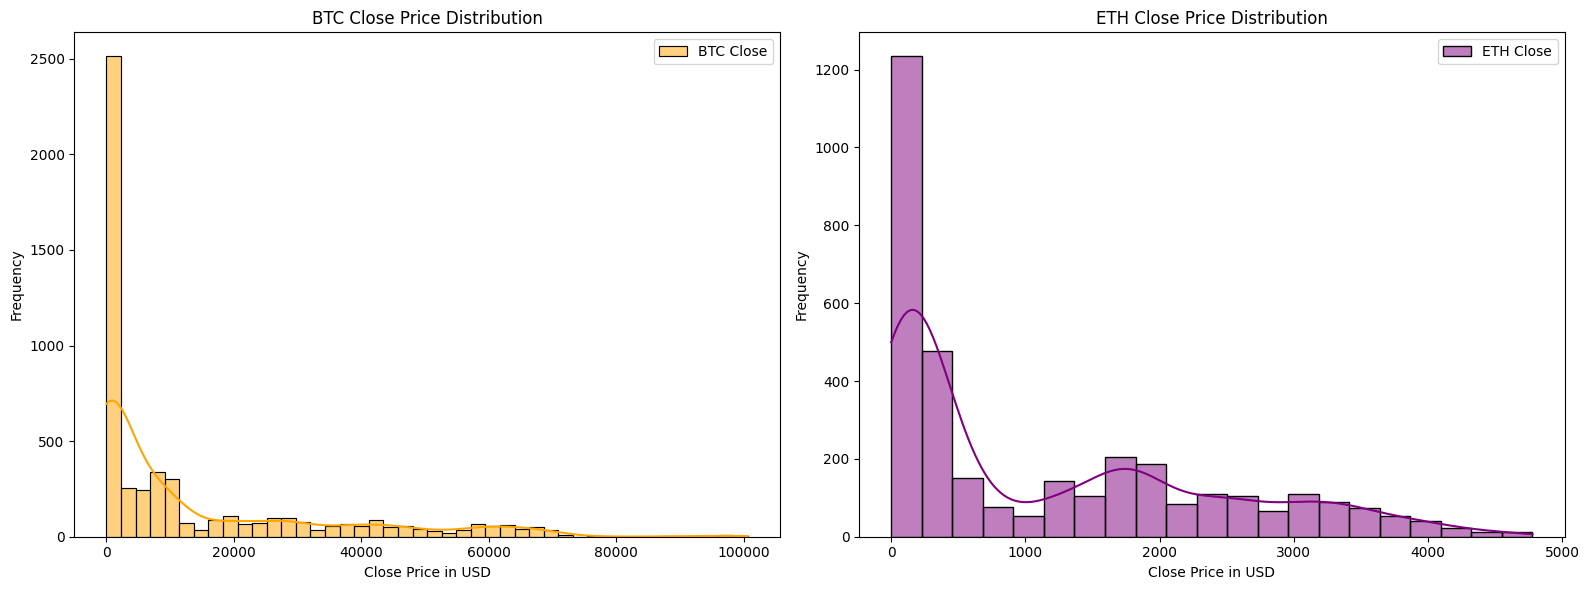

In [ ]:
plt.figure(figsize=(16, 6))

# BTC Distribution Plot
plt.subplot(1, 2, 1)
sns.histplot(btc_data['close'], kde=True, color='orange', label='BTC Close')
plt.title("BTC Close Price Distribution")
plt.xlabel("Close Price in USD")
plt.ylabel("Frequency")
plt.legend()

# ETH Distribution Plot
plt.subplot(1, 2, 2)
sns.histplot(eth_data['close'], kde=True, color='purple', label='ETH Close')
plt.title("ETH Close Price Distribution")
plt.xlabel("Close Price in USD")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

Box Plots for BTC and ETH Close Prices

Purpose:
- Display the range, interquartile range (IQR), and potential outliers in the close prices for Bitcoin (BTC) and Ethereum (ETH).
- Compare the variability and identify any extreme values in both datasets.

Description:
1. **BTC Box Plot (Left)**:
   - Shows the distribution of BTC close prices along the horizontal axis (X-axis).
   - Highlights the median, lower and upper quartiles, and any potential outliers in BTC prices.

2. **ETH Box Plot (Right)**:
   - Displays the same statistical summary for ETH close prices along the horizontal axis (X-axis).
   - Useful for understanding the price range and outlier behavior of Ethereum compared to Bitcoin.

Visualization Details:
- **X-axis**: Represents the close price values for BTC and ETH.
- **Y-axis**: Indicates the single category (BTC or ETH) on separate plots.
- **Color**:
  - BTC is represented in blue.
  - ETH is represented in orange.
- **Layout**: Both plots are displayed side by side to compare distributions individually.

Insights:
- Helps determine the spread and symmetry of the price distributions for BTC and ETH.
- Highlights the presence of outliers, which may indicate unusual market conditions, volatility, or potential errors in the data.
- By switching the axes, it is easier to interpret the spread of prices along a continuous scale (X-axis).

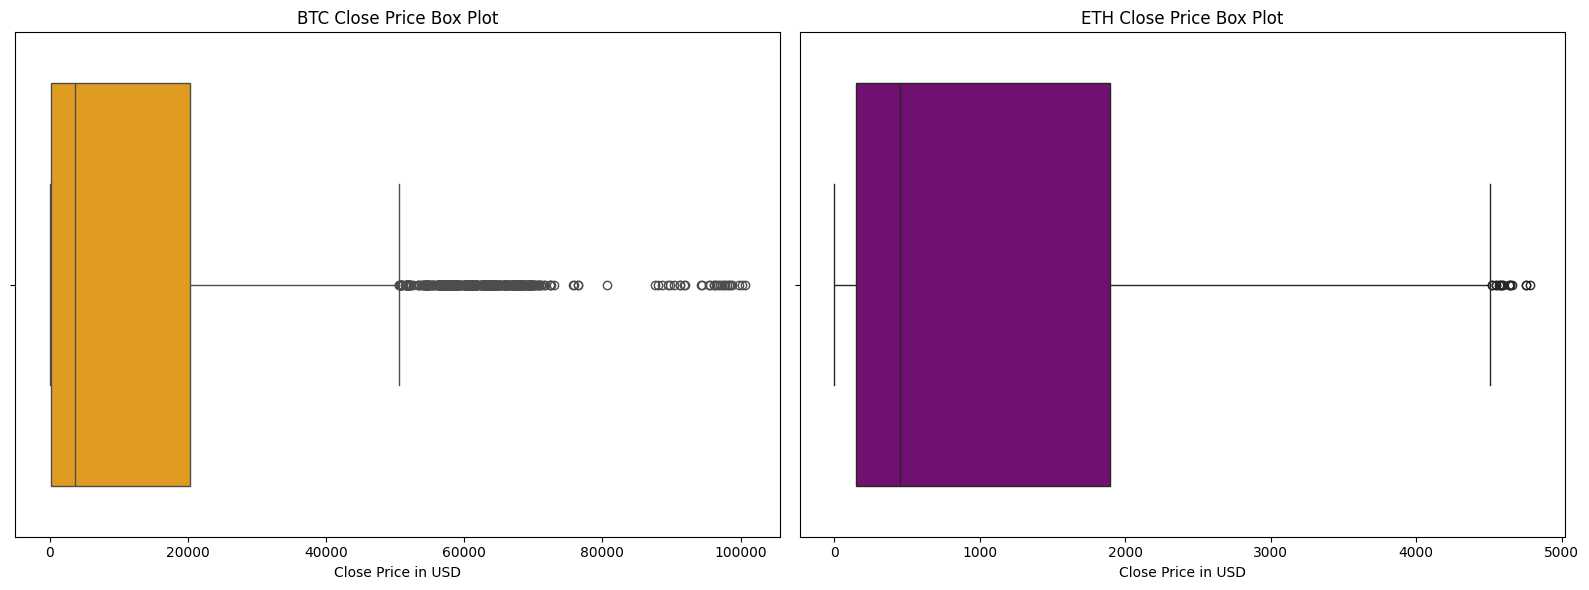

In [ ]:
plt.figure(figsize=(16, 6))

# BTC Box Plot
plt.subplot(1, 2, 1)
sns.boxplot(x=btc_data['close'], color="orange")
plt.title("BTC Close Price Box Plot")
plt.xlabel("Close Price in USD")
plt.ylabel("")

# ETH Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(x=eth_data['close'], color="purple")
plt.title("ETH Close Price Box Plot")
plt.xlabel("Close Price in USD")
plt.ylabel("")

plt.tight_layout()
plt.show()

Line Plots for BTC and ETH Close Prices Over Time

Purpose:
- Visualize the historical trends in close prices for Bitcoin (BTC) and Ethereum (ETH).
- Identify patterns, trends, or anomalies in price movements over time.

Description:
1. **BTC Line Plot (Left)**:
   - Plots BTC close prices against time.
   - Highlights trends, price fluctuations, and potential turning points in Bitcoin's market history.

2. **ETH Line Plot (Right)**:
   - Displays Ethereum close prices over the same period.
   - Useful for comparing the behavior of ETH prices with BTC.

Visualization Details:
- **X-axis**: Represents the time (date).
- **Y-axis**: Represents the close price values for BTC and ETH.
- **Color**:
  - BTC prices are shown in blue.
  - ETH prices are shown in orange.
- **Legend**: Indicates the respective cryptocurrency.
- **Layout**: Plots are displayed side by side for simultaneous comparison.

Insights:
- These plots help identify market trends, periods of stability or volatility, and any significant price changes.
- Comparing BTC and ETH side by side provides a clear view of their individual and relative market dynamics.

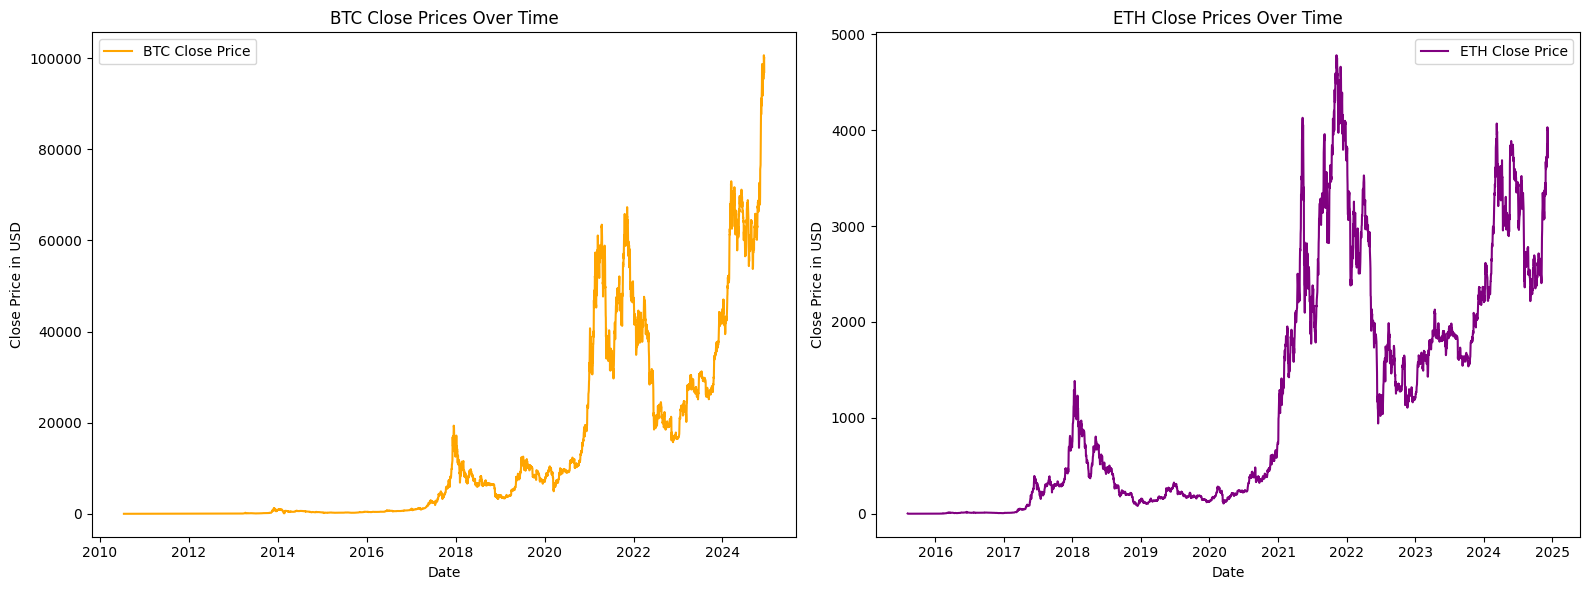

In [ ]:
plt.figure(figsize=(16, 6))

# BTC Line Plot
plt.subplot(1, 2, 1)
plt.plot(btc_data['date'], btc_data['close'], label='BTC Close Price', color='orange')
plt.title("BTC Close Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price in USD")
plt.legend()

# ETH Line Plot
plt.subplot(1, 2, 2)
plt.plot(eth_data['date'], eth_data['close'], label='ETH Close Price', color='purple')
plt.title("ETH Close Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price in USD")
plt.legend()

plt.tight_layout()
plt.show()

30-Day Moving Averages for BTC and ETH Close Prices

Purpose:
- Highlight long-term trends in Bitcoin (BTC) and Ethereum (ETH) close prices by smoothing out short-term fluctuations.
- Identify overall market direction for both cryptocurrencies.

Description:
1. **BTC Moving Average (Left)**:
   - Displays the 30-day moving average of BTC close prices.
   - Smooths out daily price volatility to reveal long-term trends in Bitcoin's market behavior.

2. **ETH Moving Average (Right)**:
   - Shows the 30-day moving average of ETH close prices.
   - Provides insights into Ethereum's market direction over an extended period.

Visualization Details:
- **X-axis**: Represents the time (date).
- **Y-axis**: Represents the smoothed price values for BTC and ETH.
- **Color**:
  - BTC moving average is shown in blue.
  - ETH moving average is shown in orange.
- **Legend**: Indicates the cryptocurrency and the 30-day moving average.
- **Layout**: Plots are displayed side by side for simultaneous comparison.

Insights:
- Helps observe general price movements and trends, filtering out daily volatility.
- Useful for comparing the overall market behavior of BTC and ETH over time.

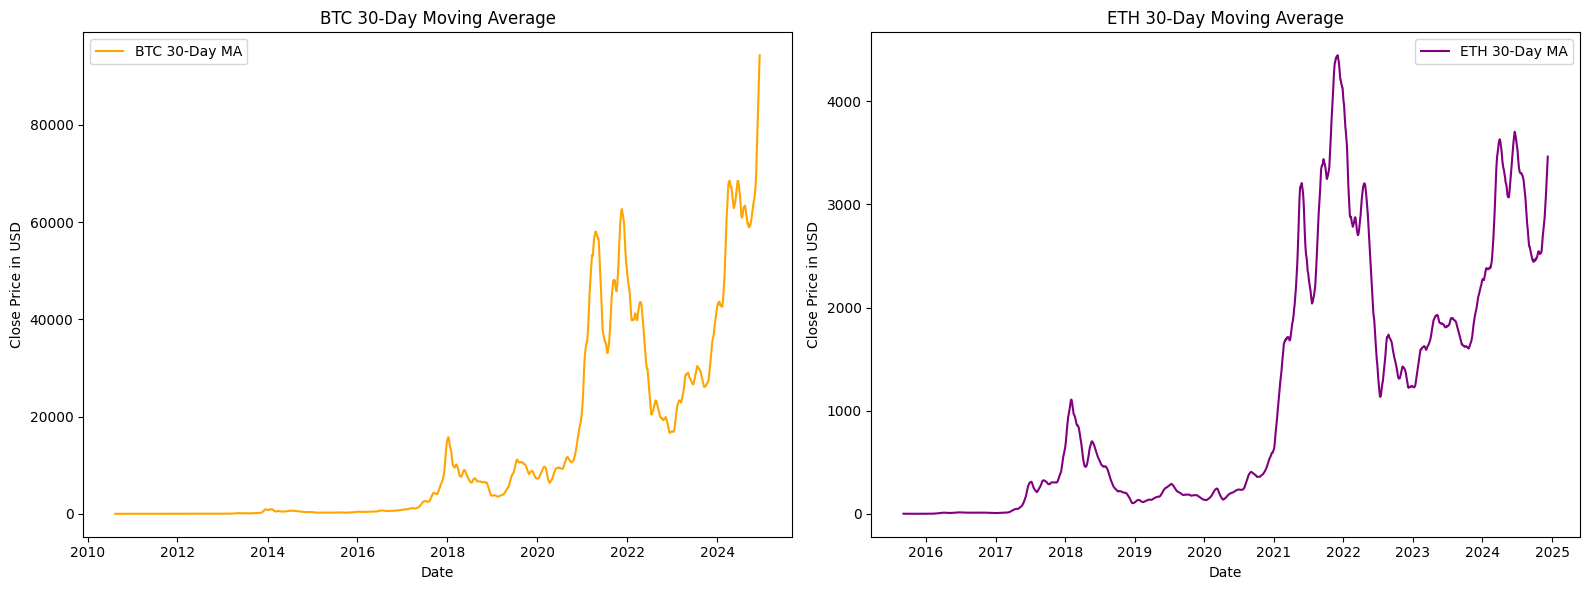

In [ ]:
btc_data = data[data['ticker'] == 'BTC'].copy()
eth_data = data[data['ticker'] == 'ETH'].copy()

btc_data['moving_avg'] = btc_data['close'].rolling(window=30).mean()
eth_data['moving_avg'] = eth_data['close'].rolling(window=30).mean()

plt.figure(figsize=(16, 6))

# BTC Moving Average
plt.subplot(1, 2, 1)
plt.plot(btc_data['date'], btc_data['moving_avg'], label='BTC 30-Day MA', color='orange')
plt.title("BTC 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Close Price in USD")
plt.legend()

# ETH Moving Average
plt.subplot(1, 2, 2)
plt.plot(eth_data['date'], eth_data['moving_avg'], label='ETH 30-Day MA', color='purple')
plt.title("ETH 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Close Price in USD")
plt.legend()

plt.tight_layout()
plt.show()

Percentage Change for BTC and ETH Close Prices

Purpose:
- Visualize the daily percentage change in close prices for Bitcoin (BTC) and Ethereum (ETH).
- Understand the volatility of each cryptocurrency over time.

Description:
1. **BTC Percentage Change (Left)**:
   - Plots the percentage change in BTC close prices on a daily basis.
   - Highlights periods of high volatility or stable price movement in Bitcoin's market.

2. **ETH Percentage Change (Right)**:
   - Shows the daily percentage change in ETH close prices.
   - Useful for identifying similar volatility patterns and comparing them to BTC.

Visualization Details:
- **X-axis**: Represents the time (date).
- **Y-axis**: Represents the daily percentage change in close prices.
- **Color**:
  - BTC percentage change is shown in blue.
  - ETH percentage change is shown in orange.
- **Legend**: Indicates the respective cryptocurrency and the type of data displayed.
- **Layout**: Plots are displayed side by side for easy comparison.

Insights:
- Helps evaluate the risk and stability of BTC and ETH markets over time.
- Allows for the identification of highly volatile periods or steady growth/decline phases.

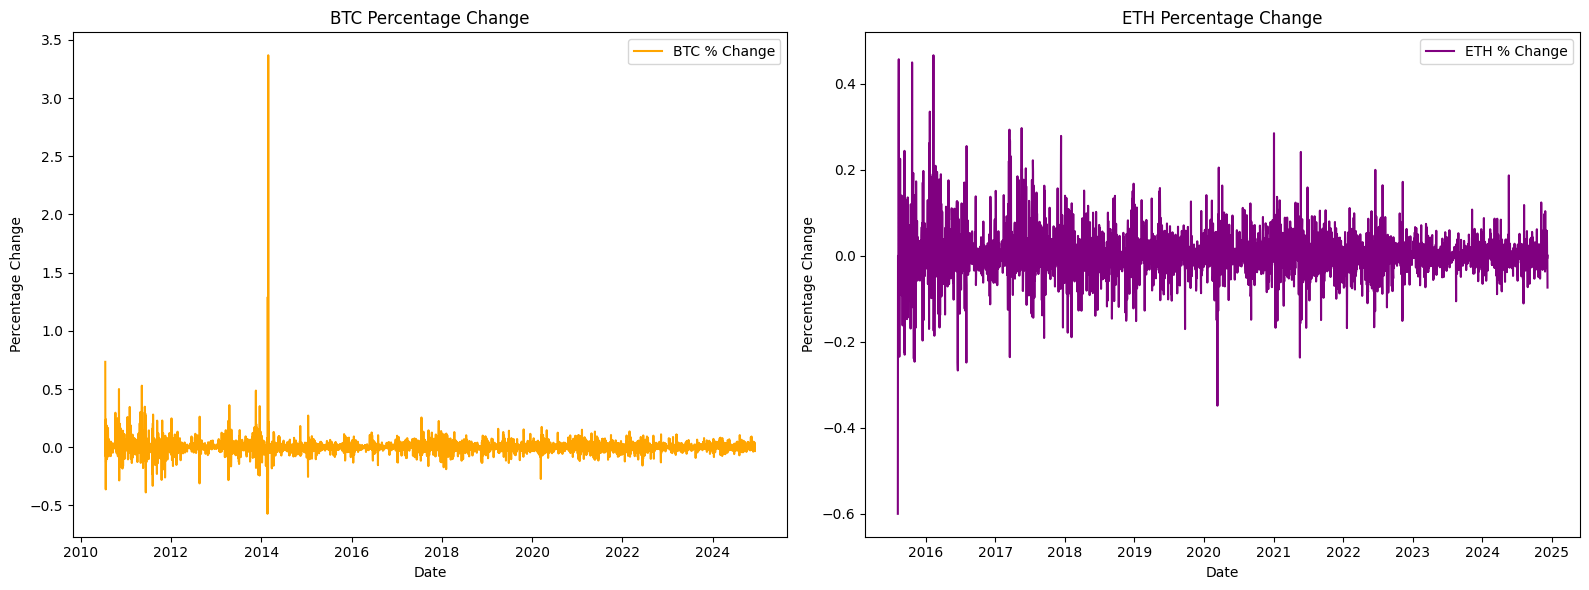

In [ ]:
btc_data = data[data['ticker'] == 'BTC'].copy()
eth_data = data[data['ticker'] == 'ETH'].copy()

btc_data['pct_change'] = btc_data['close'].pct_change()
eth_data['pct_change'] = eth_data['close'].pct_change()

plt.figure(figsize=(16, 6))

# BTC Percentage Change
plt.subplot(1, 2, 1)
plt.plot(btc_data['date'], btc_data['pct_change'], label='BTC % Change', color='orange')
plt.title("BTC Percentage Change")
plt.xlabel("Date")
plt.ylabel("Percentage Change")
plt.legend()

# ETH Percentage Change
plt.subplot(1, 2, 2)
plt.plot(eth_data['date'], eth_data['pct_change'], label='ETH % Change', color='purple')
plt.title("ETH Percentage Change")
plt.xlabel("Date")
plt.ylabel("Percentage Change")
plt.legend()

plt.tight_layout()
plt.show()


Density Plots for BTC and ETH Close Prices

Purpose:
- Visualize the probability density of close prices for Bitcoin (BTC) and Ethereum (ETH).
- Identify the most common price ranges and the overall distribution of values.

Description:
1. **BTC Density Plot (Left)**:
   - Shows the density distribution of BTC close prices.
   - Highlights the concentration of prices in certain ranges and provides insights into the shape of the distribution.

2. **ETH Density Plot (Right)**:
   - Displays the density distribution of ETH close prices.
   - Useful for comparing the price concentration and distribution with BTC.

Visualization Details:
- **X-axis**: Represents the close price values.
- **Y-axis**: Represents the probability density of the prices.
- **Color**:
  - BTC density is shown in blue.
  - ETH density is shown in orange.
- **Legend**: Indicates the cryptocurrency and the type of data displayed.
- **Layout**: Plots are shown side by side to allow for easy comparison.

Insights:
- Helps identify common price ranges and the spread of close prices for each cryptocurrency.
- Useful for detecting skewness or irregularities in the price distributions.

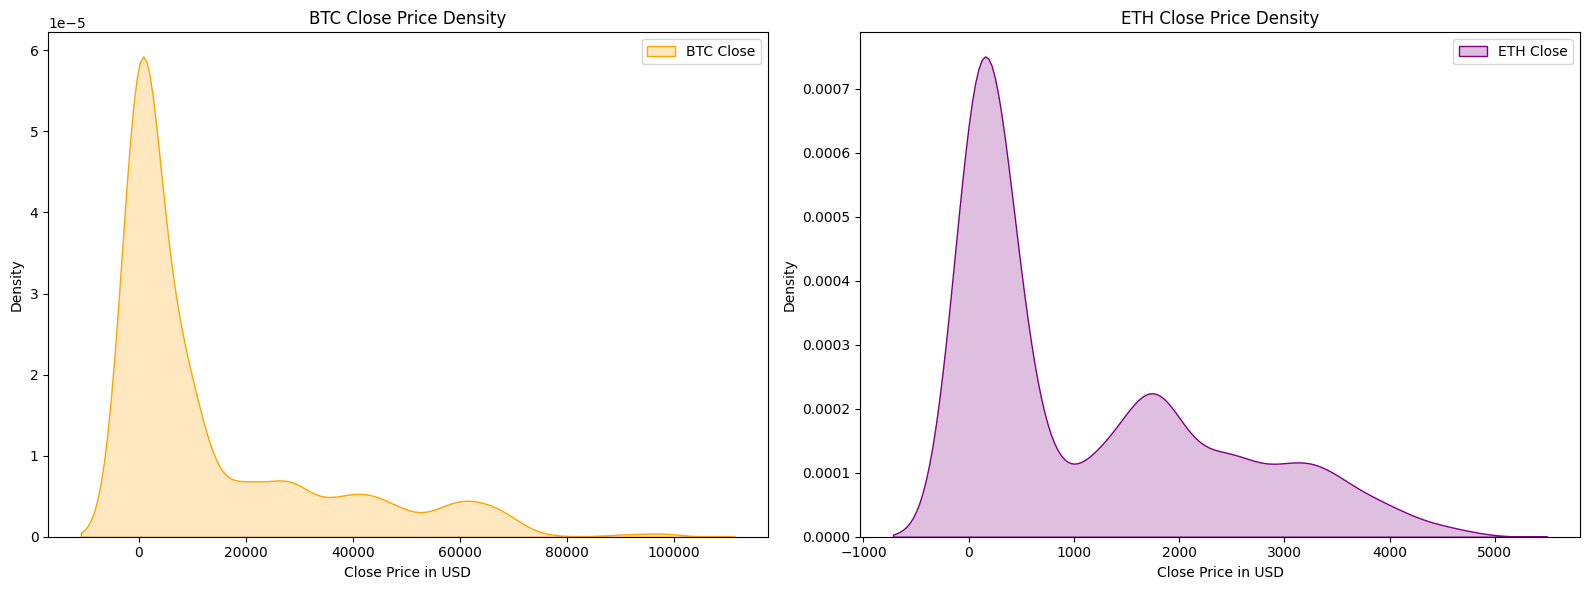

In [ ]:
plt.figure(figsize=(16, 6))

# BTC Density Plot
plt.subplot(1, 2, 1)
sns.kdeplot(btc_data['close'], fill=True, color='orange', label='BTC Close')
plt.title("BTC Close Price Density")
plt.xlabel("Close Price in USD")
plt.ylabel("Density")
plt.legend()

# ETH Density Plot
plt.subplot(1, 2, 2)
sns.kdeplot(eth_data['close'], fill=True, color='purple', label='ETH Close')
plt.title("ETH Close Price Density")
plt.xlabel("Close Price in USD")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

Correlation Heatmaps for BTC and ETH Features

Purpose:
- Analyze the relationships between numerical features in Bitcoin (BTC) and Ethereum (ETH) datasets.
- Identify which features are strongly positively or negatively correlated.

Description:
1. **BTC Correlation Heatmap (Left)**:
   - Displays the correlation matrix for BTC numerical features (e.g., `open`, `high`, `low`, `close`, etc.).
   - Strong correlations (positive or negative) are highlighted, aiding feature selection or analysis of interdependencies.

2. **ETH Correlation Heatmap (Right)**:
   - Shows the correlation matrix for ETH numerical features.
   - Allows for a direct comparison with BTC to identify similarities or differences in feature relationships.

Visualization Details:
- **Heatmap Colors**:
  - Blue to red gradient: Indicates negative to positive correlations.
  - Dark blue: Strong negative correlation.
  - Dark red: Strong positive correlation.
- **Annotations**:
  - Numeric values of correlations are displayed within the cells for clarity.
- **Titles**:
  - Clearly distinguish between BTC and ETH heatmaps.

Insights:
- Helps identify highly correlated features, which can be useful for predictive modeling or feature engineering.
- Allows for direct comparison of correlation structures between BTC and ETH markets.

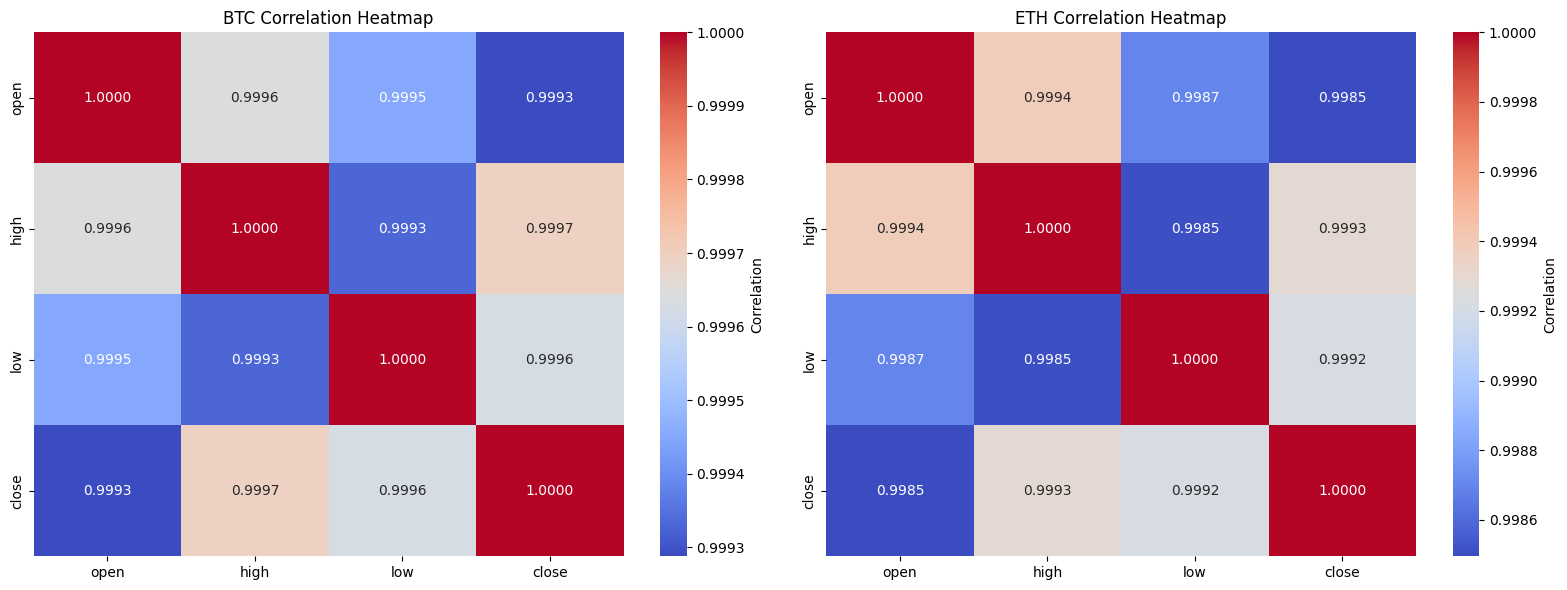

In [ ]:
plt.figure(figsize=(16, 6))

# BTC Correlation Heatmap
plt.subplot(1, 2, 1)
btc_corr = df[df['ticker'] == 'BTC'].corr(numeric_only=True)
sns.heatmap(btc_corr, annot=True, fmt=".4f", cmap='coolwarm', cbar_kws={'label': 'Correlation'})
plt.title("BTC Correlation Heatmap")

# ETH Correlation Heatmap
plt.subplot(1, 2, 2)
eth_corr = df[df['ticker'] == 'ETH'].corr(numeric_only=True)
sns.heatmap(eth_corr, annot=True, fmt=".4f", cmap='coolwarm', cbar_kws={'label': 'Correlation'})
plt.title("ETH Correlation Heatmap")

plt.tight_layout()
plt.show()


Autocorrelation Plots for BTC and ETH Close Prices

Purpose:
- Visualize the degree of correlation between a time series and its lagged values for Bitcoin (BTC) and Ethereum (ETH).
- Detect patterns, trends, or seasonality in the data.

Description:
1. **BTC Autocorrelation Plot (Left)**:
   - Displays the autocorrelation of BTC close prices over multiple lags.
   - Helps identify recurring patterns or significant dependencies between values over time.

2. **ETH Autocorrelation Plot (Right)**:
   - Shows the autocorrelation of ETH close prices over the same lags.
   - Useful for comparing seasonality or persistence in Ethereum's data relative to Bitcoin.

Visualization Details:
- **X-axis**: Represents the number of lags (time shifts).
- **Y-axis**: Represents the correlation coefficient at each lag.
- **Bars**:
  - Height of the bars indicates the strength of correlation for each lag.
  - Bars outside the confidence intervals suggest statistically significant correlations.

Insights:
- Helps detect potential seasonality, periodic patterns, or long-term dependencies in BTC and ETH prices.
- Can guide model selection, especially for time-series models (e.g., ARIMA, LSTM).

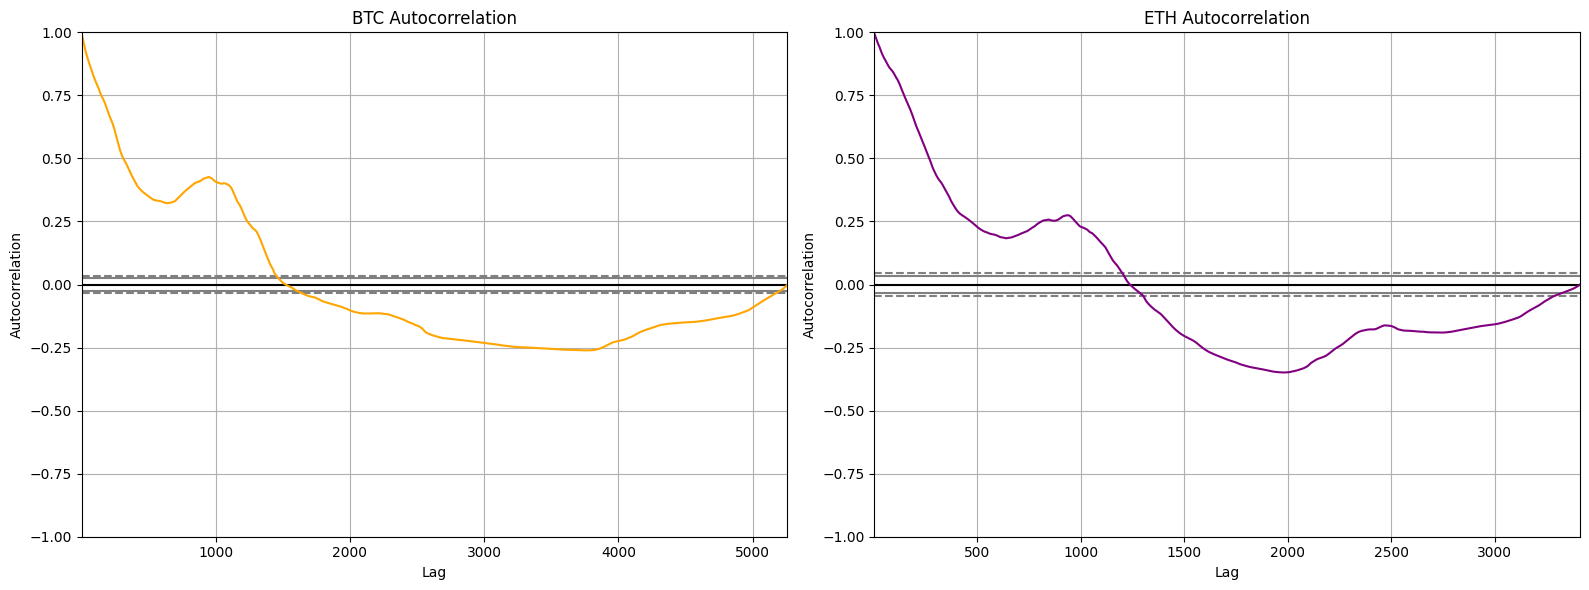

In [ ]:
plt.figure(figsize=(16, 6))

# BTC Autocorrelation Plot
plt.subplot(1, 2, 1)
plt.title("BTC Autocorrelation")
autocorrelation_plot(btc_data['close'], color='orange')

# ETH Autocorrelation Plot
plt.subplot(1, 2, 2)
plt.title("ETH Autocorrelation")
autocorrelation_plot(eth_data['close'], color='purple')

plt.tight_layout()
plt.show()

Seasonal Decomposition of BTC and ETH Close Prices

Purpose:
- Break down the time series data of Bitcoin (BTC) and Ethereum (ETH) close prices into four key components:
  1. **Observed**: The original time series data.
  2. **Trend**: The long-term trend in the data.
  3. **Seasonal**: Recurring patterns or seasonality in the data.
  4. **Residual**: The remaining variability after removing trend and seasonality.

Description:
1. **BTC Decomposition (Left Column)**:
   - **Observed**: Displays the raw BTC close price data.
   - **Trend**: Highlights the overall direction (upward or downward) in BTC prices.
   - **Seasonal**: Captures recurring short-term patterns in BTC prices.
   - **Residual**: Represents the noise or random variations in BTC prices.

2. **ETH Decomposition (Right Column)**:
   - Similar analysis for ETH close prices, providing a parallel view to BTC.

Visualization Details:
- **X-axis**: Represents the time (date) shared across all subplots for comparison.
- **Y-axis**: Represents the corresponding values for each component (Observed, Trend, Seasonal, Residual).
- **Colors**:
  - BTC components are shown in blue.
  - ETH components are shown in orange.
- **Layout**:
  - The left column shows BTC components.
  - The right column shows ETH components in the same order, facilitating direct comparison.

Insights:
- **Observed**: Shows the overall price movement for both cryptocurrencies.
- **Trend**: Helps identify long-term price directions and major shifts.
- **Seasonal**: Highlights periodic patterns, which could indicate recurring market behaviors.
- **Residual**: Analyzes noise or unpredictable elements in the data after accounting for trend and seasonality.

In [ ]:
btc_decomp = seasonal_decompose(btc_data['close'], period=30, model='additive', extrapolate_trend='freq')
eth_decomp = seasonal_decompose(eth_data['close'], period=30, model='additive', extrapolate_trend='freq')

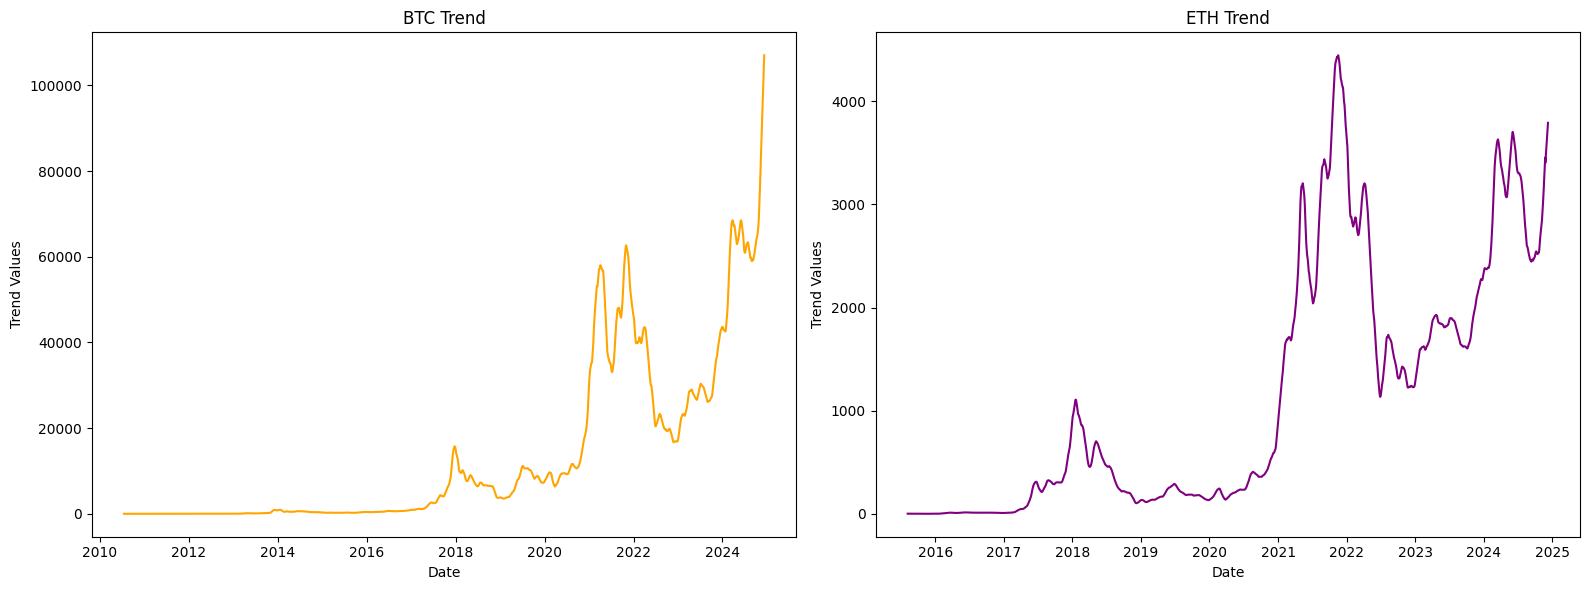

In [ ]:
plt.figure(figsize=(16, 6))

# BTC Trend
plt.subplot(1, 2, 1)
plt.plot(btc_data['date'], btc_decomp.trend, color='orange')
plt.title("BTC Trend")
plt.xlabel("Date")
plt.ylabel("Trend Values")

# ETH Trend
plt.subplot(1, 2, 2)
plt.plot(eth_data['date'], eth_decomp.trend, color='purple')
plt.title("ETH Trend")
plt.xlabel("Date")
plt.ylabel("Trend Values")

plt.tight_layout()
plt.show()


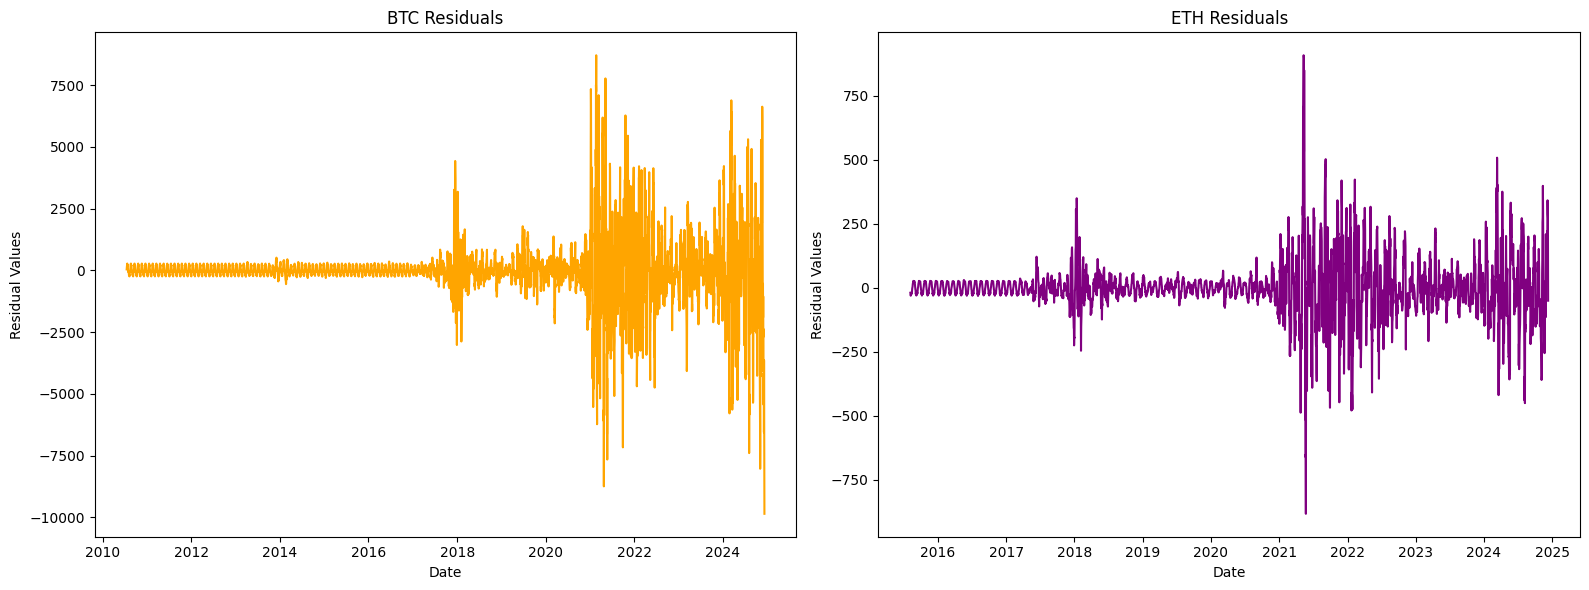

In [ ]:
plt.figure(figsize=(16, 6))

# BTC Residual
plt.subplot(1, 2, 1)
plt.plot(btc_data['date'], btc_decomp.resid, color='orange')
plt.title("BTC Residuals")
plt.xlabel("Date")
plt.ylabel("Residual Values")

# ETH Residual
plt.subplot(1, 2, 2)
plt.plot(eth_data['date'], eth_decomp.resid, color='purple')
plt.title("ETH Residuals")
plt.xlabel("Date")
plt.ylabel("Residual Values")

plt.tight_layout()
plt.show()


Scale Data for BTC and ETH
- Create `MinMaxScaler` objects for scaling the `close` column values of BTC and ETH.
- Filter the DataFrame to separate BTC and ETH data into two DataFrames: `df_btc` and `df_eth`.
- Scale the `close` values for both BTC and ETH using the respective scalers.
- Print a confirmation message after successful scaling.


In [ ]:
scaler_btc = MinMaxScaler()
scaler_eth = MinMaxScaler()

df_btc = df[df['ticker'] == 'BTC']
df_eth = df[df['ticker'] == 'ETH']

btc_scaled = scaler_btc.fit_transform(df_btc[['close']])
eth_scaled = scaler_eth.fit_transform(df_eth[['close']])
print("Data for BTC and ETH scaled successfully.")

Data for BTC and ETH scaled successfully.


Create Time Series Generators
- Define the parameters for the time series generators: `look_back` period (number of past observations) and `batch_size`.
- Use `TimeseriesGenerator` to create time series datasets for BTC and ETH based on their scaled `close` values.
- Print a confirmation message indicating successful creation of the generators.

In [ ]:
look_back = 10
batch_size = 16

btc_gen = TimeseriesGenerator(btc_scaled, btc_scaled, length=look_back, batch_size=batch_size)
eth_gen = TimeseriesGenerator(eth_scaled, eth_scaled, length=look_back, batch_size=batch_size)

print("Generators created successfully.")

Generators created successfully.


Build and Train LSTM Models for BTC and ETH
- **Define the LSTM model**:
  - Use the `Sequential` API to build the model.
  - Add an `Input` layer to define the input shape (`look_back`, 1).
  - Include two LSTM layers with 50 units each and ReLU activation:
    - The first LSTM layer returns sequences (`return_sequences=True`) to pass output to the next LSTM layer.
  - Add a `Dropout` layer with a rate of 0.2 to reduce overfitting.
  - Add a `Dense` output layer with 1 unit to predict the target value.
  - Compile the model with the Adam optimizer and mean squared error (MSE) as the loss function.

- **Initialize models for BTC and ETH**:
  - Create two separate LSTM models using the `build_lstm_model` function, one for BTC and one for ETH.

- **Train the models**:
  - Train both models on their respective time series generators (`btc_gen` and `eth_gen`) for 20 epochs.
  - Set `verbose=1` to display training progress.

In [ ]:
def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(50, activation='relu', return_sequences=True),
        Dropout(0.2),
        LSTM(50, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

input_shape = (look_back, 1)

btc_lstm_model = build_lstm_model(input_shape)
eth_lstm_model = build_lstm_model(input_shape)

btc_lstm_model.fit(btc_gen, epochs=20, verbose=1)
eth_lstm_model.fit(eth_gen, epochs=20, verbose=1)

Epoch 1/20
  7/329 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0293      

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


329/329 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0108
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0012
Epoch 3/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 5.7883e-04
Epoch 4/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 8.1598e-04
Epoch 5/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 4.6462e-04
Epoch 6/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5.8265e-04
Epoch 7/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5.3035e-04
Epoch 8/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5.1012e-04
Epoch 9/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 3.8489e-04
Epoch 10/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5.7157e-04
Epoch 11/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 3.6491e-04
Epoch 12/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 3.5721e-04
Epoch 13/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5.3765e-04
Epoch 14/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5.1274e-04
Epoch 15/20
32

Build and Train RNN Models for BTC and ETH
- **Define the RNN model**:
  - Use the `Sequential` API to build the model.
  - Add two `SimpleRNN` layers with 50 units each and ReLU activation:
    - The first `SimpleRNN` layer returns sequences (`return_sequences=True`) to pass output to the next RNN layer.
  - Add a `Dropout` layer with a rate of 0.2 between the two RNN layers to reduce overfitting.
  - Add a `Dense` output layer with 1 unit to predict the target value.
  - Compile the model with the Adam optimizer and mean squared error (MSE) as the loss function.

- **Initialize models for BTC and ETH**:
  - Create two separate RNN models using the `build_rnn_model` function, one for BTC and one for ETH.

- **Train the models**:
  - Train both models on their respective time series generators (`btc_gen` and `eth_gen`) for 20 epochs.
  - Set `verbose=1` to display training progress.


In [ ]:
def build_rnn_model(input_shape):
    model = Sequential([
        SimpleRNN(50, activation='relu', return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        SimpleRNN(50, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

input_shape = (look_back, 1)

btc_rnn_model = build_rnn_model(input_shape)
eth_rnn_model = build_rnn_model(input_shape)

btc_rnn_model.fit(btc_gen, epochs=20, verbose=1)
eth_rnn_model.fit(eth_gen, epochs=20, verbose=1)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0133
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0047
Epoch 3/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.0272e-04
Epoch 4/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 3.7106e-04
Epoch 5/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 3.3420e-04
Epoch 6/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 8.9265e-04
Epoch 7/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5.5526e-04
Epoch 8/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.7323e-04
Epoch 9/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.8943e-04
Epoch 10/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.6434e-04
Epoch 11/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.3340e-04
Epoch 12/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 3.2655e-04
Epoch 13/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 4.5212e-04
Epoch 14/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 3.3690e-04
Epoch 15/20
329/329

Build and Train CNN Models for BTC and ETH
- **Define the CNN model**:
  - Use the `Sequential` API to build the model.
  - Add two `Conv1D` layers:
    - The first layer has 64 filters, a kernel size of 3, ReLU activation, and accepts the input shape (`look_back`, 1).
    - The second layer has 32 filters, a kernel size of 3, and ReLU activation.
  - Include a `Dropout` layer with a rate of 0.2 after the first convolutional layer to reduce overfitting.
  - Add a `Flatten` layer to convert the 2D output of the convolutional layers into a 1D vector.
  - Add a `Dense` hidden layer with 50 units and ReLU activation for feature extraction.
  - Add a final `Dense` output layer with 1 unit to predict the target value.
  - Compile the model with the Adam optimizer and mean squared error (MSE) as the loss function.

- **Initialize models for BTC and ETH**:
  - Create two separate CNN models using the `build_cnn_model` function, one for BTC and one for ETH.

- **Train the models**:
  - Train both models on their respective time series generators (`btc_gen` and `eth_gen`) for 20 epochs.
  - Set `verbose=1` to display training progress.

In [ ]:
def build_cnn_model(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        Dropout(0.2),
        Conv1D(32, kernel_size=3, activation='relu'),
        Flatten(),
        Dense(50, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

input_shape = (look_back, 1)

btc_cnn_model = build_cnn_model(input_shape)
eth_cnn_model = build_cnn_model(input_shape)

btc_cnn_model.fit(btc_gen, epochs=20, verbose=1)
eth_cnn_model.fit(eth_gen, epochs=20, verbose=1)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0033
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.4060e-04
Epoch 3/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0014
Epoch 4/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.8964e-04
Epoch 5/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0020
Epoch 6/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.9703e-04
Epoch 7/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.9182e-04
Epoch 8/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0022
Epoch 9/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.7226e-04
Epoch 10/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.8446e-04
Epoch 11/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.2431e-04
Epoch 12/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.8534e-04
Epoch 13/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.7806e-04
Epoch 14/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0011
Epoch 15/20
329/329 ━━━━━━━━━━━━

Build and Train GRU Models for BTC and ETH
- **Define the GRU model**:
  - Use the `Sequential` API to build the model.
  - Add two `GRU` layers with 50 units each and ReLU activation:
    - The first `GRU` layer returns sequences (`return_sequences=True`) to pass output to the next GRU layer.
  - Include a `Dropout` layer with a rate of 0.2 between the two GRU layers to reduce overfitting.
  - Add a `Dense` output layer with 1 unit to predict the target value.
  - Compile the model with the Adam optimizer and mean squared error (MSE) as the loss function.

- **Initialize models for BTC and ETH**:
  - Create two separate GRU models using the `build_gru_model` function, one for BTC and one for ETH.

- **Train the models**:
  - Train both models on their respective time series generators (`btc_gen` and `eth_gen`) for 20 epochs.
  - Set `verbose=1` to display training progress.

In [ ]:
def build_gru_model(input_shape):
    model = Sequential([
        GRU(50, activation='relu', return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(50, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

input_shape = (look_back, 1)

btc_gru_model = build_gru_model(input_shape)
eth_gru_model = build_gru_model(input_shape)

btc_gru_model.fit(btc_gen, epochs=20, verbose=1)
eth_gru_model.fit(eth_gen, epochs=20, verbose=1)

Epoch 1/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0189
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 4.9766e-04
Epoch 3/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 9.7887e-04
Epoch 4/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 6.1438e-04
Epoch 5/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 2.8432e-04
Epoch 6/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 4.2773e-04
Epoch 7/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 3.7796e-04
Epoch 8/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 6.8542e-04
Epoch 9/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0017
Epoch 10/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 3.0845e-04
Epoch 11/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 3.7199e-04
Epoch 12/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5.5704e-04
Epoch 13/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 4.1842e-04
Epoch 14/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 2.8857

Build and Train LightGBM Models for BTC and ETH
- **Define the LightGBM model**:
  - Use the `LGBMRegressor` from the LightGBM library to create a regression model.
  - Set a fixed `random_state` for reproducibility.

- **Training the LightGBM model**:
  - Extract features (`X`) and targets (`y`) from the time series data:
    - For each window of length `look_back`, the flattened data becomes a feature vector.
    - The target is the next value in the sequence after the `look_back` window.
  - Convert `X` and `y` to NumPy arrays for compatibility with LightGBM.
  - Fit the model using the extracted `X` and `y` values.

- **Initialize and train models for BTC and ETH**:
  - Create two separate LightGBM models using the `build_lgbm_model` function, one for BTC and one for ETH.
  - Train both models on their respective time series data using the `train_lgbm_model` function.

In [ ]:
def build_lgbm_model(input_shape):
    model = LGBMRegressor(random_state=42)
    return model

def train_lgbm_model(model, gen):
    X, y = [], []
    for i in range(len(gen.data) - look_back):
        X.append(gen.data[i:i+look_back].flatten())
        y.append(gen.data[i+look_back])
    X, y = np.array(X), np.array(y)
    model.fit(X, y)
    return model

input_shape = (look_back, 1)

btc_lgbm_model = build_lgbm_model(input_shape)
eth_lgbm_model = build_lgbm_model(input_shape)

btc_lgbm_model = train_lgbm_model(btc_lgbm_model, btc_gen)
eth_lgbm_model = train_lgbm_model(eth_lgbm_model, eth_gen)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001371 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 5250, number of used features: 10
[LightGBM] [Info] Start training from score 0.135609
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000642 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 3403, number of used features: 10
[LightGBM] [Info] Start training from score 0.237798


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Build and Train XGBoost Models for BTC and ETH
- **Define the XGBoost model**:
  - Use the `XGBRegressor` from the XGBoost library to create a regression model.
  - Set the `objective` to `'reg:squarederror'` for regression tasks.
  - Use a fixed `random_state` for reproducibility.

- **Training the XGBoost model**:
  - Extract features (`X`) and targets (`y`) from the time series data:
    - For each window of length `look_back`, the flattened data is used as a feature vector.
    - The target value is the next point in the sequence after the `look_back` window.
  - Convert `X` and `y` to NumPy arrays for compatibility with XGBoost.
  - Train the model by fitting it to the extracted features and targets.

- **Initialize and train models for BTC and ETH**:
  - Create two separate XGBoost models using the `build_xgb_model` function, one for BTC and one for ETH.
  - Train both models on their respective time series data using the `train_xgb_model` function.


In [ ]:
def build_xgb_model(input_shape):
    model = XGBRegressor(objective='reg:squarederror', random_state=42)
    return model

def train_xgb_model(model, gen):
    X, y = [], []
    for i in range(len(gen.data) - look_back):
        X.append(gen.data[i:i+look_back].flatten())
        y.append(gen.data[i+look_back])
    X, y = np.array(X), np.array(y)
    model.fit(X, y)
    return model

input_shape = (look_back, 1)
btc_xgb_model = build_xgb_model(input_shape)
eth_xgb_model = build_xgb_model(input_shape)
btc_xgb_model = train_xgb_model(btc_xgb_model, btc_gen)
eth_xgb_model = train_xgb_model(eth_xgb_model, eth_gen)

Evaluate Model Performance
- **Evaluate the model**:
  - Depending on the `model_type` parameter, the evaluation function handles two types of models:
    - **Neural models** (`model_type="neural"`): Predictions are generated directly from the time series generator.
    - **Tree-based models** (`model_type="tree"`): Features are extracted manually from the time series generator to create a test set.
  - The actual target values are extracted from the scaled data, skipping the `look_back` period.

- **Rescale predictions and actual values**:
  - Both the predicted and actual values are rescaled back to their original scale using the provided scaler.

- **Calculate evaluation metrics**:
  - `mse` (Mean Squared Error): Measures the average squared difference between predicted and actual values.
  - `mae` (Mean Absolute Error): Measures the average absolute difference between predicted and actual values.
  - `r2` (R-squared Score): Indicates the proportion of the variance in the target variable explained by the model.

- **Return evaluation results**:
  - Rescaled predictions, actual values, and the calculated metrics (`mse`, `mae`, `r2`) are returned.

In [ ]:
def evaluate_model(model, gen, scaler, actual_scaled, model_type="neural"):
    if model_type == "neural":
        predictions = model.predict(gen)
        actual = actual_scaled[look_back:]
    elif model_type == "tree":
        X_test = [gen.data[i:i+look_back].flatten() for i in range(len(gen.data) - look_back)]
        predictions = model.predict(np.array(X_test))
        actual = actual_scaled[look_back:]
    else:
        raise ValueError("Invalid model_type. Allowed values: 'neural', 'tree'.")

    predictions_rescaled = scaler.inverse_transform(predictions.reshape(-1, 1))
    actual_rescaled = scaler.inverse_transform(actual)

    mse = mean_squared_error(actual_rescaled, predictions_rescaled)
    mae = mean_absolute_error(actual_rescaled, predictions_rescaled)
    r2 = r2_score(actual_rescaled, predictions_rescaled)

    return predictions_rescaled, actual_rescaled, mse, mae, r2

Model Evaluation
This section evaluates the performance of various models trained on BTC and ETH data. For each model, predictions are compared with actual values, and performance metrics are calculated to assess the accuracy and effectiveness of the model.

Workflow:
1. **Generate Predictions**:
   - Predictions are made using the trained models (e.g., LSTM, RNN, CNN, GRU, XGBoost, and LightGBM) on their respective datasets.
   - For neural models (LSTM, RNN, CNN, GRU), predictions are generated directly from the sequence generator (`TimeseriesGenerator`).
   - For tree-based models (XGBoost, LightGBM), predictions are generated using manually extracted features (`look_back` windows).

2. **Rescale Predictions and Actual Values**:
   - Both predicted and actual values, originally scaled during preprocessing, are transformed back to their original scale using the scaler.

3. **Calculate Metrics**:
   - **MSE (Mean Squared Error)**: Indicates the average squared difference between predicted and actual values. Lower values indicate better performance.
   - **MAE (Mean Absolute Error)**: Measures the average absolute difference between predicted and actual values. Lower values suggest better accuracy.
   - **R² (R-squared)**: Represents how well the model explains the variance in the target data. Values closer to 1 indicate better explanatory power.

4. **Print Results**:
   - Metrics (MSE, MAE, R²) are printed for each model and for both cryptocurrencies (BTC and ETH).

Included Models:
- **LSTM**: Evaluates long-term dependencies in sequential data.
- **RNN**: Processes sequential data with a simpler architecture compared to LSTM.
- **CNN**: Captures local patterns in the time series data.
- **GRU**: A variant of LSTM with a simpler structure and faster computation.
- **XGBoost**: Tree-based ensemble model optimized for accuracy and speed.
- **LightGBM**: Gradient boosting framework optimized for performance on structured data.

Purpose:
This evaluation helps identify which model performs best for forecasting BTC and ETH prices, providing insight into their predictive accuracy and reliability.

In [ ]:
# Evaluation for LSTM
btc_lstm_pred, btc_lstm_actual, mse, mae, r2 = evaluate_model(btc_lstm_model, btc_gen, scaler_btc, btc_scaled)
print(f"BTC LSTM - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

eth_lstm_pred, eth_lstm_actual, mse, mae, r2 = evaluate_model(eth_lstm_model, eth_gen, scaler_eth, eth_scaled)
print(f"ETH LSTM - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

# Evaluation for RNN
btc_rnn_pred, btc_rnn_actual, mse, mae, r2 = evaluate_model(btc_rnn_model, btc_gen, scaler_btc, btc_scaled)
print(f"BTC RNN - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

eth_rnn_pred, eth_rnn_actual, mse, mae, r2 = evaluate_model(eth_rnn_model, eth_gen, scaler_eth, eth_scaled)
print(f"ETH RNN - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

# Evaluation for GRU
btc_gru_pred, btc_gru_actual, mse, mae, r2 = evaluate_model(btc_gru_model, btc_gen, scaler_btc, btc_scaled)
print(f"BTC GRU - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

eth_gru_pred, eth_gru_actual, mse, mae, r2 = evaluate_model(eth_gru_model, eth_gen, scaler_eth, eth_scaled)
print(f"ETH GRU - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

# Evaluation for CNN
btc_cnn_pred, btc_cnn_actual, mse, mae, r2 = evaluate_model(btc_cnn_model, btc_gen, scaler_btc, btc_scaled)
print(f"BTC CNN - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

eth_cnn_pred, eth_cnn_actual, mse, mae, r2 = evaluate_model(eth_cnn_model, eth_gen, scaler_eth, eth_scaled)
print(f"ETH CNN - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

# Evaluation for LightGBM
btc_lgbm_pred, btc_lgbm_actual, mse, mae, r2 = evaluate_model(btc_lgbm_model, btc_gen, scaler_btc, btc_scaled, model_type="tree")
print(f"BTC LightGBM - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

eth_lgbm_pred, eth_lgbm_actual, mse, mae, r2 = evaluate_model(eth_lgbm_model, eth_gen, scaler_eth, eth_scaled, model_type="tree")
print(f"ETH LightGBM - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

# Evaluation for XGBoost
btc_xgb_pred, btc_xgb_actual, mse, mae, r2 = evaluate_model(btc_xgb_model, btc_gen, scaler_btc, btc_scaled, model_type="tree")
print(f"BTC XGBoost - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

eth_xgb_pred, eth_xgb_actual, mse, mae, r2 = evaluate_model(eth_xgb_model, eth_gen, scaler_eth, eth_scaled, model_type="tree")
print(f"ETH XGBoost - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
BTC LSTM - MSE: 35938239.3296, MAE: 3290.9246, R2: 0.9097
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
ETH LSTM - MSE: 13120.0584, MAE: 75.7905, R2: 0.9912
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
BTC RNN - MSE: 3202779.3478, MAE: 1555.3061, R2: 0.9920
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
ETH RNN - MSE: 36063.9621, MAE: 117.6853, R2: 0.9758
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
BTC GRU - MSE: 1321847.6998, MAE: 617.0166, R2: 0.9967
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
ETH GRU - MSE: 11793.1931, MAE: 75.4309, R2: 0.9921
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
BTC CNN - MSE: 3268782.9789, MAE: 1000.5808, R2: 0.9918
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
ETH CNN - MSE: 14782.3225, MAE: 76.7351, R2: 0.9901
BTC LightGBM - MSE: 306545.9506, MAE: 260.1958, R2: 0.9992
ETH LightGBM - MSE: 1859.0597, MAE: 23.7673, R2: 0.9988
BTC XGBoost - MSE: 65870.6694, MAE: 124.5931, R2: 0.9998
ETH XGBoost - MSE: 269.8971, MAE: 10.2501, R2: 0.9998


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
def save_evaluation_to_csv(file_path, evaluation_data):
    with open(file_path, mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["Ticker", "Model", "MSE", "MAE", "R2"])
        writer.writerows(evaluation_data)

def collect_results():
    evaluation_results = []

    models = [
        ("BTC", "LSTM", btc_lstm_pred, btc_lstm_actual),
        ("ETH", "LSTM", eth_lstm_pred, eth_lstm_actual),
        ("BTC", "RNN", btc_rnn_pred, btc_rnn_actual),
        ("ETH", "RNN", eth_rnn_pred, eth_rnn_actual),
        ("BTC", "GRU", btc_gru_pred, btc_gru_actual),
        ("ETH", "GRU", eth_gru_pred, eth_gru_actual),
        ("BTC", "CNN", btc_cnn_pred, btc_cnn_actual),
        ("ETH", "CNN", eth_cnn_pred, eth_cnn_actual),
        ("BTC", "LightGBM", btc_lgbm_pred, btc_lgbm_actual),
        ("ETH", "LightGBM", eth_lgbm_pred, eth_lgbm_actual),
        ("BTC", "XGBoost", btc_xgb_pred, btc_xgb_actual),
        ("ETH", "XGBoost", eth_xgb_pred, eth_xgb_actual),
    ]

    for ticker, model, predictions, actual in models:
        mse = mean_squared_error(actual, predictions)
        mae = mean_absolute_error(actual, predictions)
        r2 = r2_score(actual, predictions)
        evaluation_results.append([ticker, model, mse, mae, r2])

    return evaluation_results

output_file = "/content/model_evaluation.csv"

evaluation_data = collect_results()
save_evaluation_to_csv(output_file, evaluation_data)

In [ ]:
print(f"Evaluation results saved to: {output_file}\nContents:")
with open(output_file, mode="r") as file:
    print(file.read())

Evaluation results saved to: /content/model_evaluation.csv
Contents:
Ticker,Model,MSE,MAE,R2
BTC,LSTM,35938239.32960294,3290.9246188667375,0.9097050616835132
ETH,LSTM,13120.058351806621,75.79050959837289,0.991182173770599
BTC,RNN,3202779.3477502414,1555.306053394732,0.9919530069073748
ETH,RNN,36063.962112631816,117.68533243018675,0.9757618645797337
BTC,GRU,1321847.6997972473,617.0165637942508,0.9966788535347455
ETH,GRU,11793.19305157371,75.43086205848695,0.9920739432531384
BTC,CNN,3268782.978891515,1000.5808094284934,0.9917871725784333
ETH,CNN,14782.322487014451,76.73512232597949,0.9900649869488187
BTC,LightGBM,306545.9505552558,260.19580679905835,0.9992298023438851
ETH,LightGBM,1859.059745790195,23.767319832999533,0.9987505493231137
BTC,XGBoost,65870.66938178832,124.59311598152561,0.9998344997378935
ETH,XGBoost,269.8971233085022,10.25014890331052,0.9998186055374654



Predicted vs Actual Price Plots (BTC and ETH)

Purpose:
- Compare predicted prices with actual prices for Bitcoin (BTC) and Ethereum (ETH) across different models.
- Visualize the model's performance over time to assess how closely predictions align with reality.

Description:
1. **Function Overview**:
   - The function `plot_predictions` takes the actual values, predicted values, and a title as input.
   - Generates a time-series line plot showing actual and predicted prices.
   - **X-axis**: Time (e.g., date index).
   - **Y-axis**: Price (e.g., close price).
   - Includes a legend to distinguish between actual and predicted values.

2. **Model Comparisons**:
   - Predictions and actual values are plotted for the following models:
     - **LSTM**: Captures long-term dependencies in time-series data.
     - **RNN**: Processes sequential data with simpler architecture compared to LSTM.
     - **CNN**: Focuses on local patterns in the data.
     - **GRU**: A simplified version of LSTM for faster computations.
     - **XGBoost**: A tree-based model known for speed and accuracy.
     - **LightGBM**: Another tree-based model optimized for performance.

3. **BTC vs ETH**:
   - Plots are created separately for BTC and ETH for each model to allow for focused analysis.
   - Differences in prediction accuracy between the two cryptocurrencies can be observed.

Insights:
- The closer the predicted line is to the actual line, the better the model's performance.
- Helps identify periods where models struggle to capture trends or are more accurate.
- Facilitates model selection by comparing prediction quality visually across different architectures.


In [ ]:
dates_btc = df_btc['date'].iloc[look_back:].values
dates_eth = df_eth['date'].iloc[look_back:].values

In [ ]:
close_btc = df_btc['close'].iloc[look_back:].values
close_eth = df_eth['close'].iloc[look_back:].values

In [ ]:
def plot_predictions(dates, actual, predictions, title):
    plt.figure(figsize=(12, 6))
    plt.plot(dates, actual, label="Actual", color='orange')
    plt.plot(dates, predictions, label="Predicted", color='purple')
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Price in USD")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

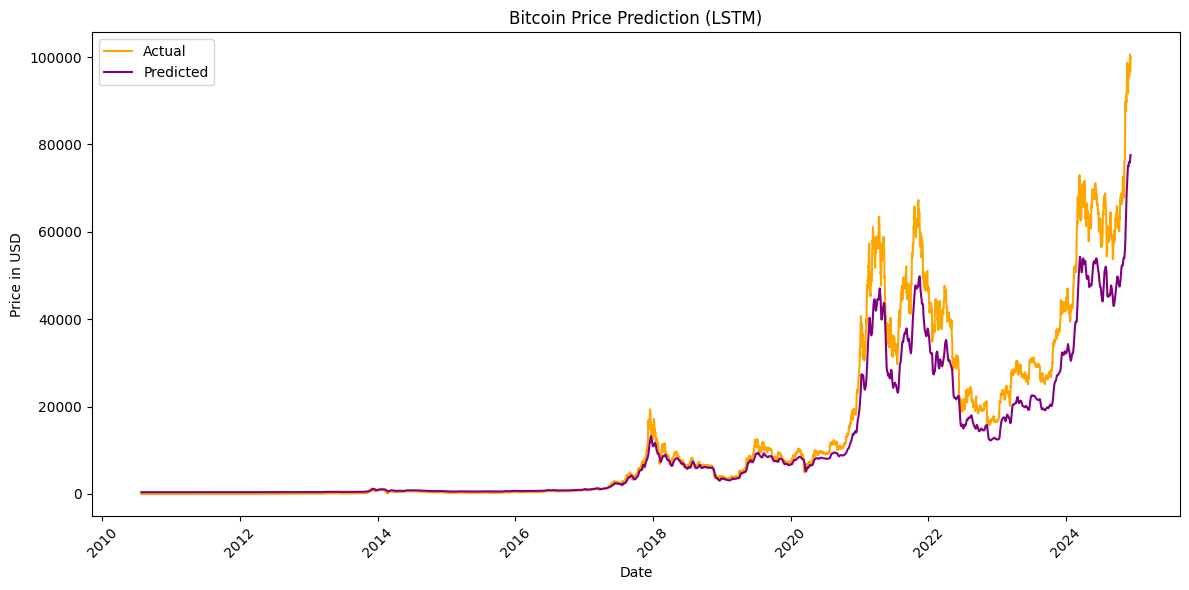

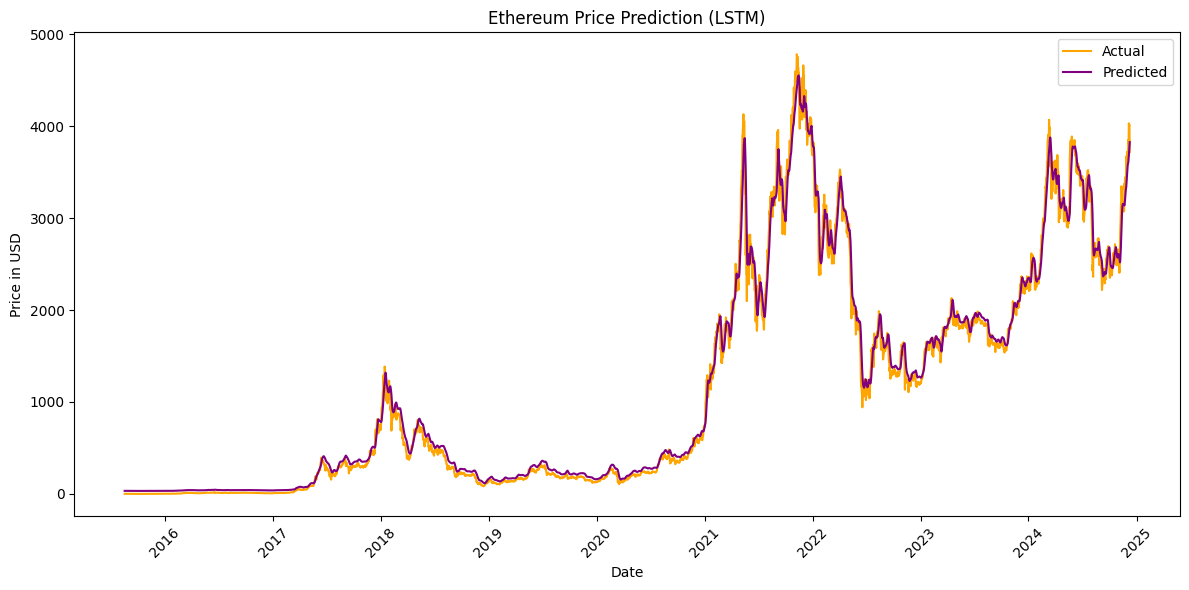

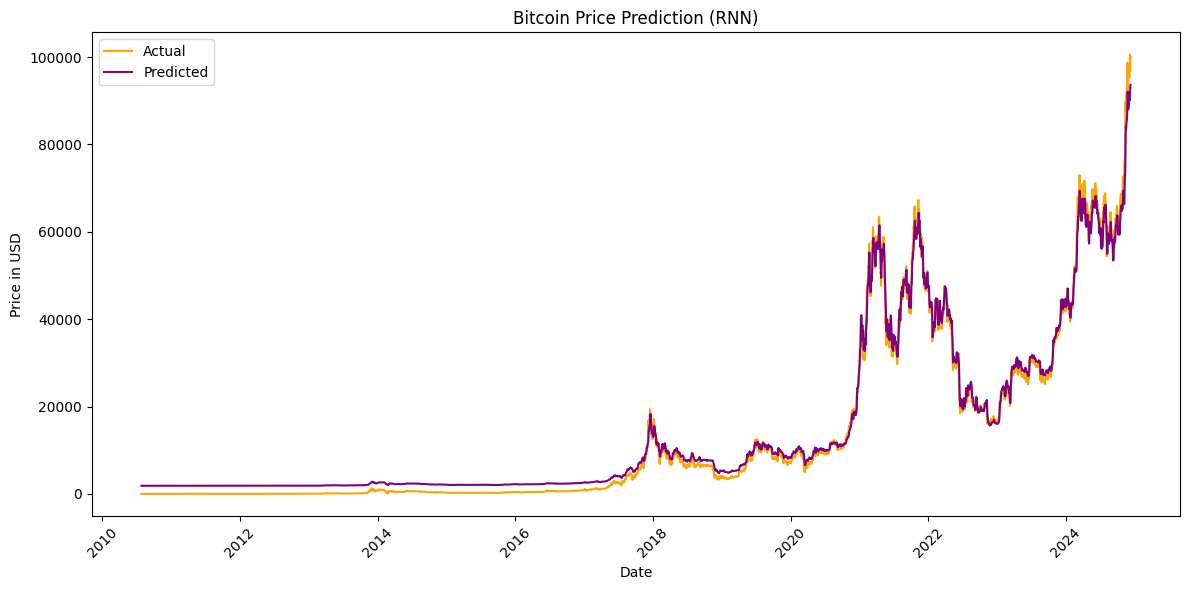

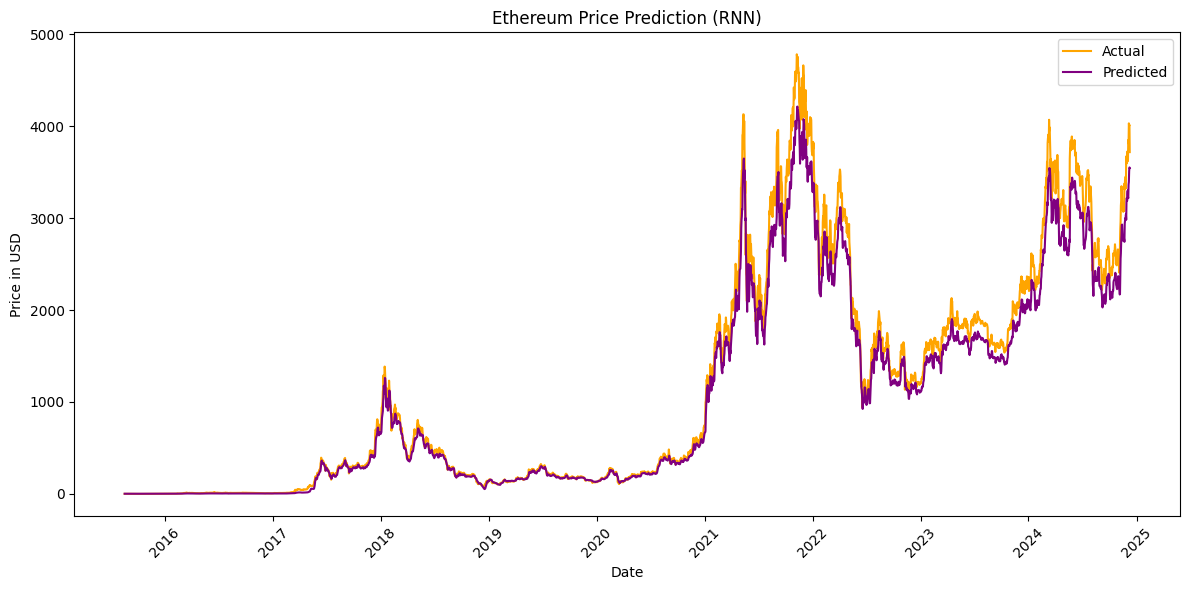

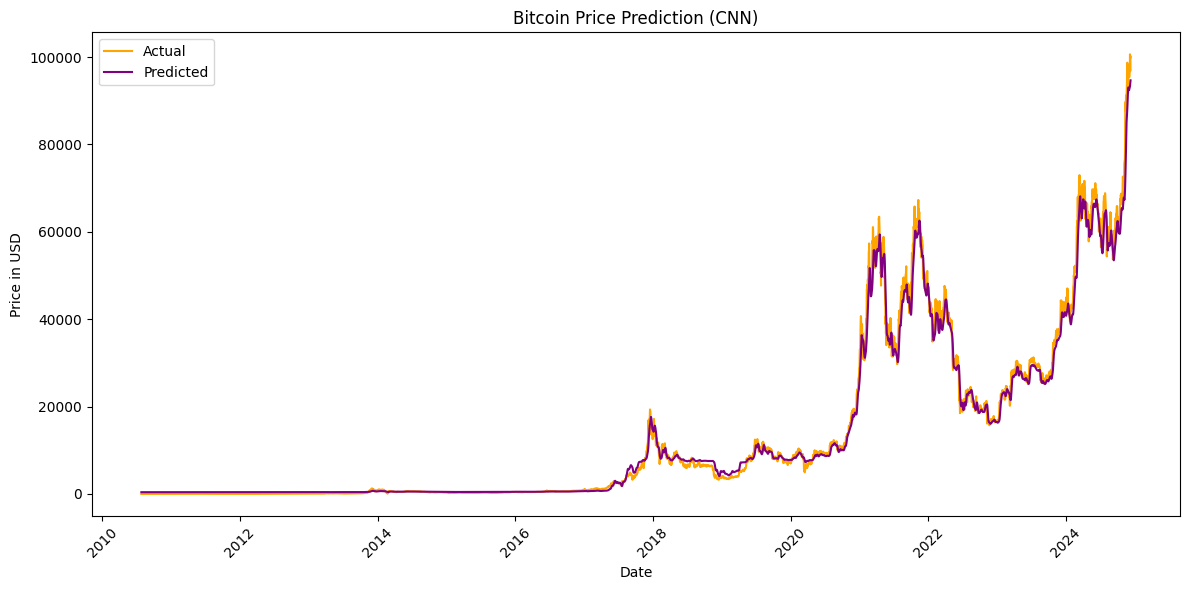

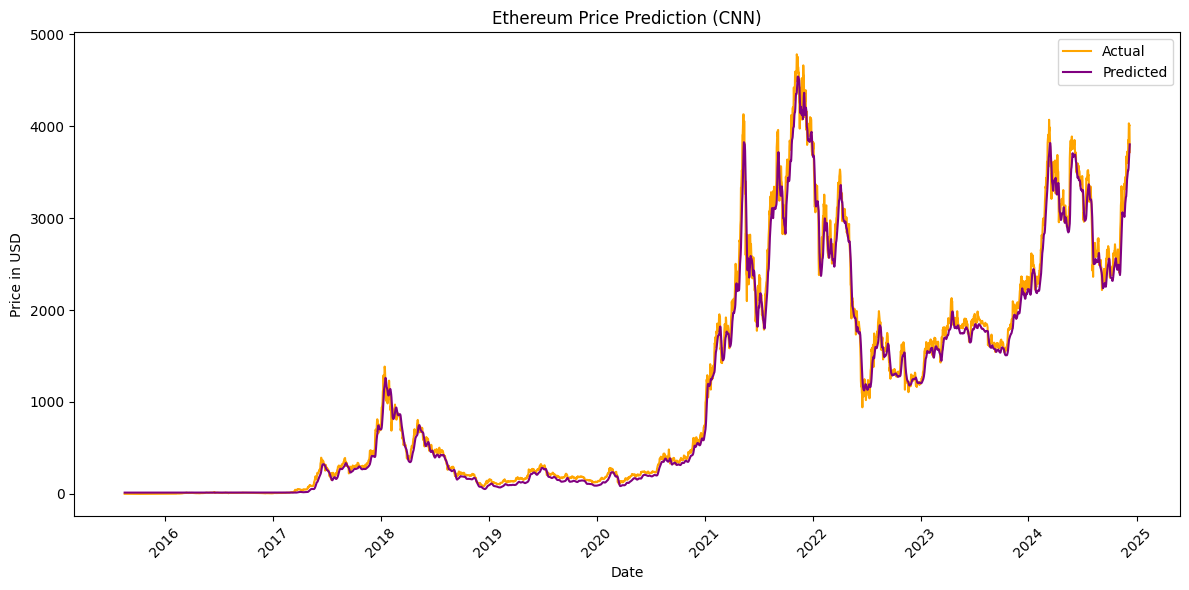

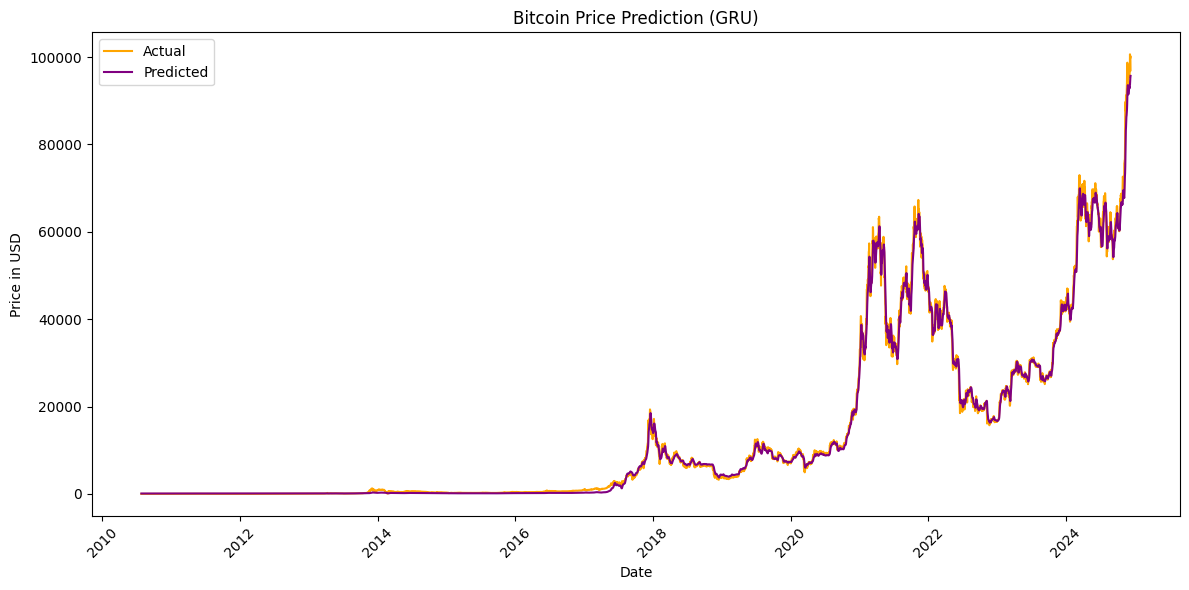

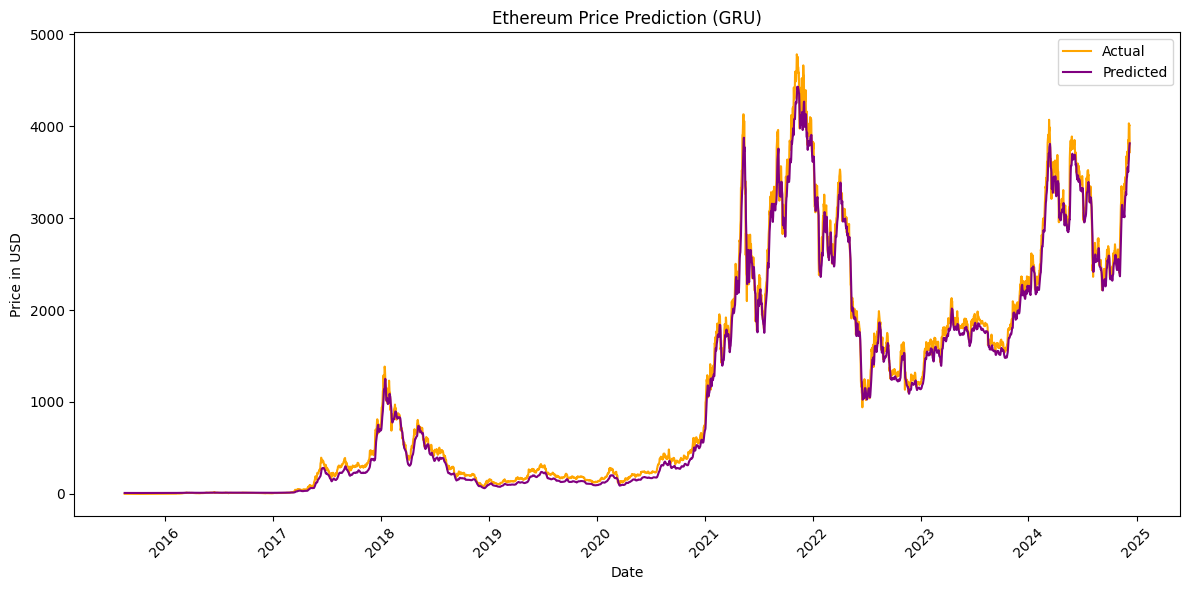

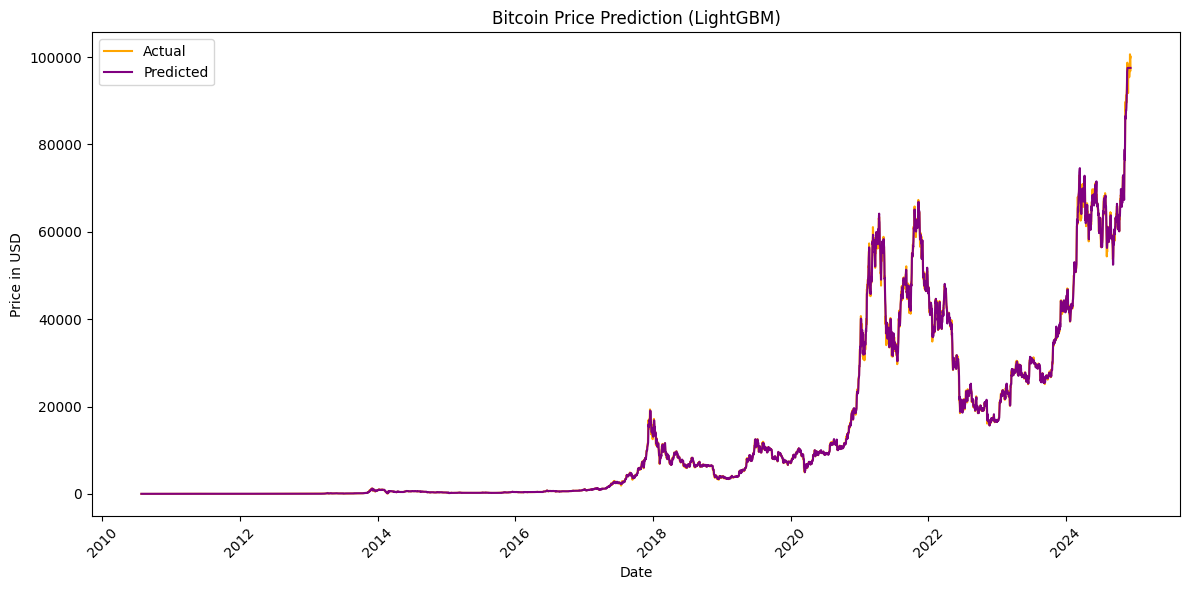

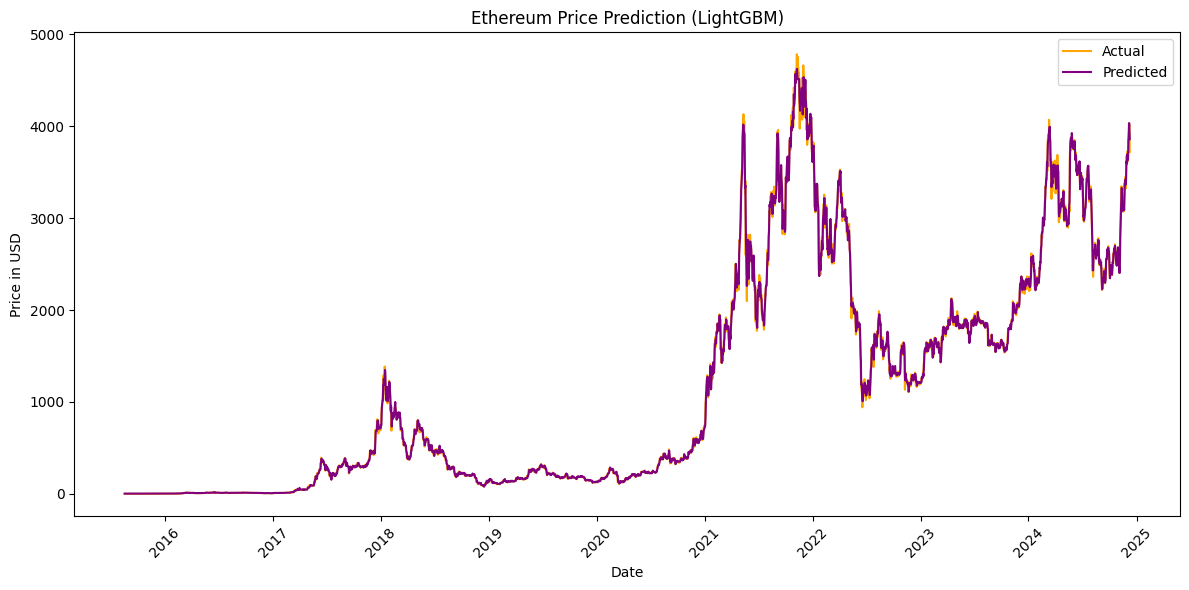

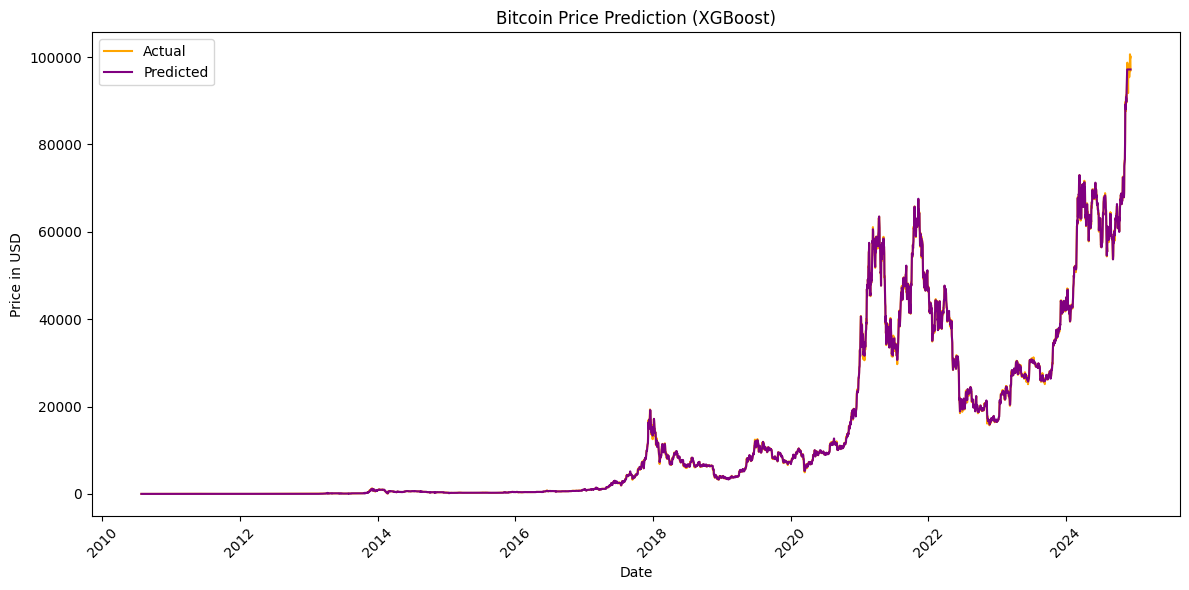

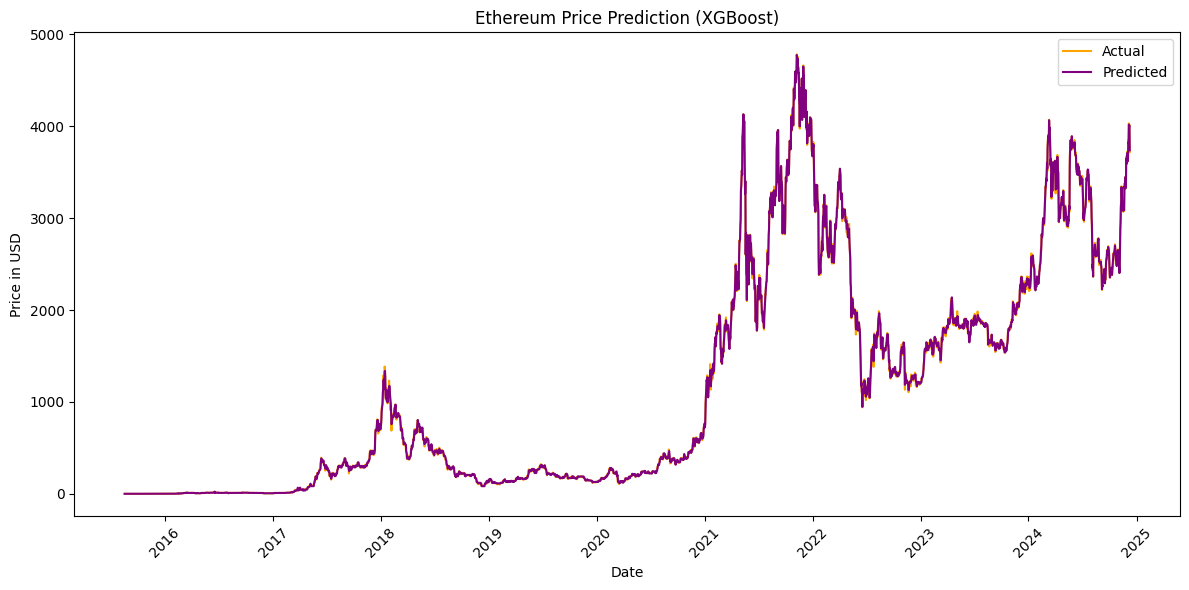

In [ ]:
# BTC and ETH - LSTM
plot_predictions(dates_btc, btc_lstm_actual, btc_lstm_pred, "Bitcoin Price Prediction (LSTM)")
plot_predictions(dates_eth, eth_lstm_actual, eth_lstm_pred, "Ethereum Price Prediction (LSTM)")

# BTC and ETH - RNN
plot_predictions(dates_btc, btc_rnn_actual, btc_rnn_pred, "Bitcoin Price Prediction (RNN)")
plot_predictions(dates_eth, eth_rnn_actual, eth_rnn_pred, "Ethereum Price Prediction (RNN)")

# BTC and ETH - CNN
plot_predictions(dates_btc, btc_cnn_actual, btc_cnn_pred, "Bitcoin Price Prediction (CNN)")
plot_predictions(dates_eth, eth_cnn_actual, eth_cnn_pred, "Ethereum Price Prediction (CNN)")

# BTC and ETH - GRU
plot_predictions(dates_btc, btc_gru_actual, btc_gru_pred, "Bitcoin Price Prediction (GRU)")
plot_predictions(dates_eth, eth_gru_actual, eth_gru_pred, "Ethereum Price Prediction (GRU)")

# BTC and ETH - LightGBM
plot_predictions(dates_btc, btc_lgbm_actual, btc_lgbm_pred, "Bitcoin Price Prediction (LightGBM)")
plot_predictions(dates_eth, eth_lgbm_actual, eth_lgbm_pred, "Ethereum Price Prediction (LightGBM)")

# BTC and ETH - XGBoost
plot_predictions(dates_btc, btc_xgb_actual, btc_xgb_pred, "Bitcoin Price Prediction (XGBoost)")
plot_predictions(dates_eth, eth_xgb_actual, eth_xgb_pred, "Ethereum Price Prediction (XGBoost)")

In [ ]:
def save_predictions_to_csv(ticker, model_name, dates, actual, predicted, prices, filename="/content/models_predictions_results.csv"):
    file_exists = False
    try:
        with open(filename, "r", encoding='utf-8'):
            file_exists = True
    except FileNotFoundError:
        pass

    formatted_dates = [str(date).split("T")[0] for date in dates]

    with open(filename, mode='a', newline='', encoding='utf-8') as file:
        writer = csv.writer(file, delimiter=';')
        if not file_exists:
            writer.writerow(["ticker", "model", "date", "actual", "predicted", "price_in_usd"])
        for date, act, pred, price in zip(formatted_dates, actual, predicted, prices):
            act_value = act[0] if isinstance(act, (list, np.ndarray)) else act
            pred_value = pred[0] if isinstance(pred, (list, np.ndarray)) else pred
            writer.writerow([
                ticker, model_name, date,
                f"{act_value:.2f}".replace('.', ','),
                f"{pred_value:.2f}".replace('.', ','),
                f"{price:.2f}".replace('.', ',')
            ])

In [ ]:
save_predictions_to_csv("BTC", "LSTM", dates_btc, btc_lstm_actual, btc_lstm_pred, close_btc)
save_predictions_to_csv("ETH", "LSTM", dates_eth, eth_lstm_actual, eth_lstm_pred, close_eth)

save_predictions_to_csv("BTC", "RNN", dates_btc, btc_rnn_actual, btc_rnn_pred, close_btc)
save_predictions_to_csv("ETH", "RNN", dates_eth, eth_rnn_actual, eth_rnn_pred, close_eth)

save_predictions_to_csv("BTC", "GRU", dates_btc, btc_gru_actual, btc_gru_pred, close_btc)
save_predictions_to_csv("ETH", "GRU", dates_eth, eth_gru_actual, eth_gru_pred, close_eth)

save_predictions_to_csv("BTC", "CNN", dates_btc, btc_cnn_actual, btc_cnn_pred, close_btc)
save_predictions_to_csv("ETH", "CNN", dates_eth, eth_cnn_actual, eth_cnn_pred, close_eth)

save_predictions_to_csv("BTC", "LightGBM", dates_btc, btc_lgbm_actual, btc_lgbm_pred, close_btc)
save_predictions_to_csv("ETH", "LightGBM", dates_eth, eth_lgbm_actual, eth_lgbm_pred, close_eth)

save_predictions_to_csv("BTC", "XGBoost", dates_btc, btc_xgb_actual, btc_xgb_pred, close_btc)
save_predictions_to_csv("ETH", "XGBoost", dates_eth, eth_xgb_actual, eth_xgb_pred, close_eth)

In [ ]:
df = pd.read_csv("/content/models_predictions_results.csv")
print(df)

                                             ticker;model;date;actual;predicted;price_in_usd
BTC;LSTM;2010-07-27;0       06;393  59;0                                                   6
BTC;LSTM;2010-07-28;0       06;393  59;0                                                   6
BTC;LSTM;2010-07-29;0       07;393  59;0                                                   7
BTC;LSTM;2010-07-30;0       06;393  58;0                                                   6
BTC;LSTM;2010-07-31;0       07;393  58;0                                                   7
...                                                                                      ...
ETH;XGBoost;2024-12-05;3810 87;3814 44;3810                                               87
ETH;XGBoost;2024-12-06;4029 36;4016 34;4029                                               36
ETH;XGBoost;2024-12-07;4002 99;3997 45;4002                                               99
ETH;XGBoost;2024-12-08;4012 79;4005 70;4012                           

Residual Plots for BTC and ETH

**Purpose**:
- Visualize the residuals (the differences between actual and predicted values) for Bitcoin (BTC) and Ethereum (ETH) across different prediction models.
- Evaluate how well each model performs in terms of prediction accuracy and identify any patterns or biases in the residuals.

**Description**:
1. **Function Overview**:
   - The `plot_residuals` function calculates and plots the residuals, which are the differences between actual and predicted values.
   - **X-axis**: Index of data points (time or observation number).
   - **Y-axis**: Residuals (the error between actual and predicted values).
   - A horizontal line at `y=0` is included to indicate the ideal case where the predictions are perfect. Points above or below this line represent errors in the predictions.

2. **Model Comparisons**:
   - Residual plots are generated for the following models:
     - **LSTM**: Long Short-Term Memory networks, designed to capture long-term dependencies in time-series data.
     - **RNN**: Recurrent Neural Networks, which process sequential data with a simpler architecture than LSTM.
     - **CNN**: Convolutional Neural Networks, typically used to capture local patterns in data.
     - **GRU**: Gated Recurrent Units, a simplified version of LSTM with faster computation.
     - **XGBoost**: A powerful tree-based ensemble model optimized for accuracy and speed.
     - **LightGBM**: Another tree-based model known for its high efficiency and speed in handling large datasets.

3. **BTC vs ETH**:
   - Residual plots are generated separately for Bitcoin (BTC) and Ethereum (ETH) to allow for a detailed analysis of how each model performs for both cryptocurrencies.
   - Comparison of residuals across models helps to assess the accuracy of the predictions for both BTC and ETH.

**Insights**:
- By analyzing the residuals, you can determine whether the model systematically overestimates or underestimates the values.
- Patterns in the residuals could indicate underfitting, overfitting, or areas where the model fails to capture important trends.
- Helps identify the best-performing model by comparing the spread of residuals and the presence of any patterns or biases in predictions.


In [ ]:
def plot_residuals(dates, actual, predictions, title):
    residuals = actual - predictions
    plt.figure(figsize=(12, 6))
    plt.scatter(dates, residuals, alpha=0.6, color='pink')
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Residuals")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

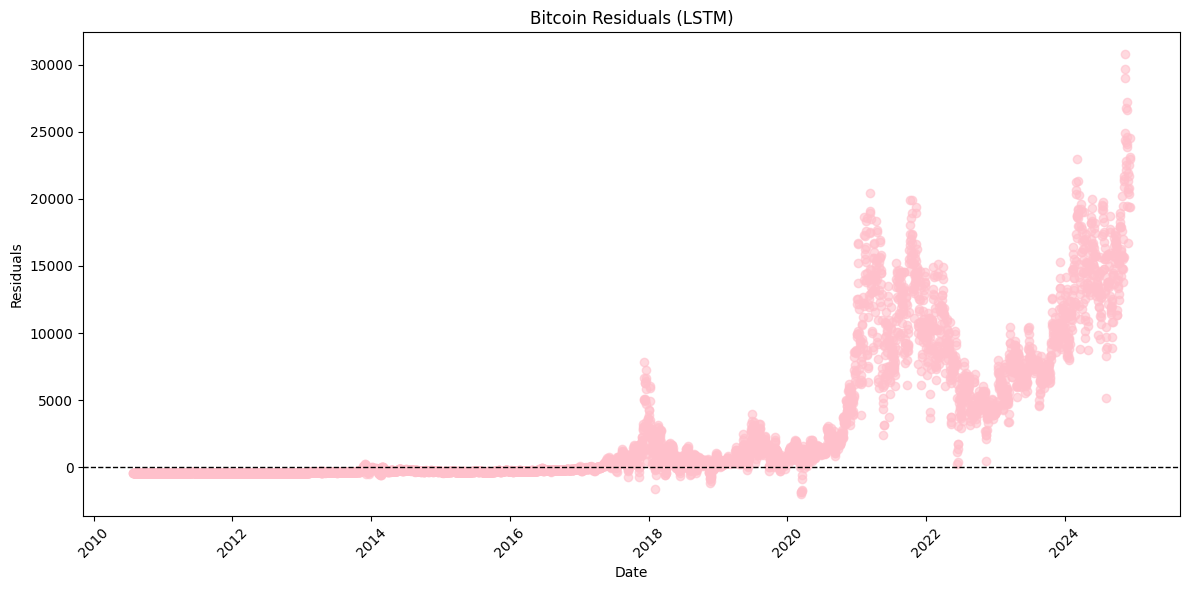

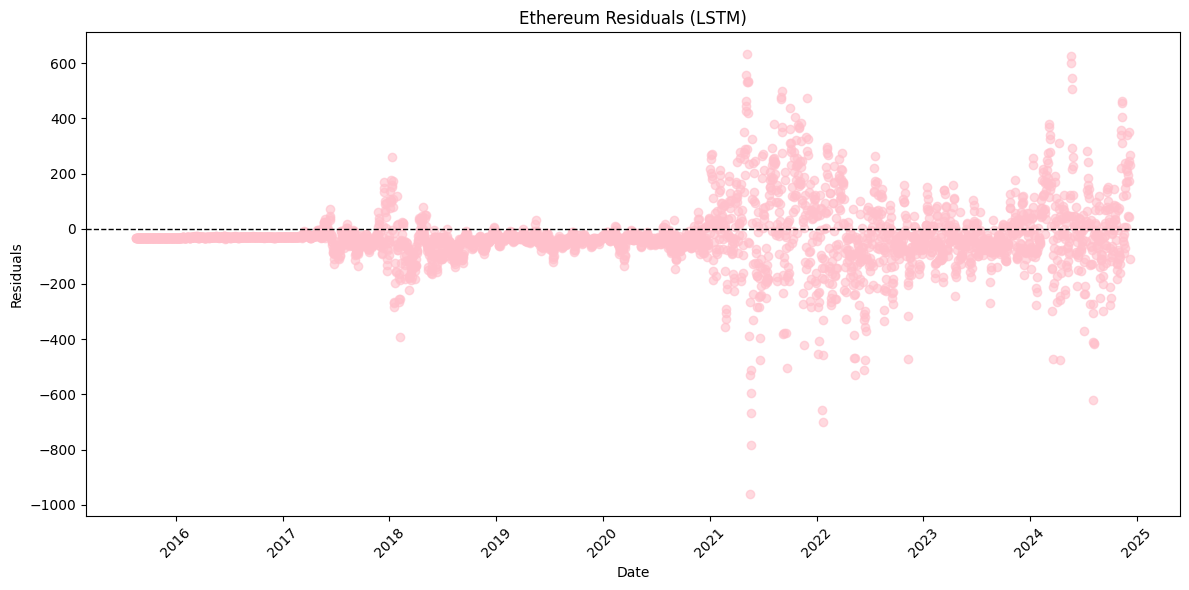

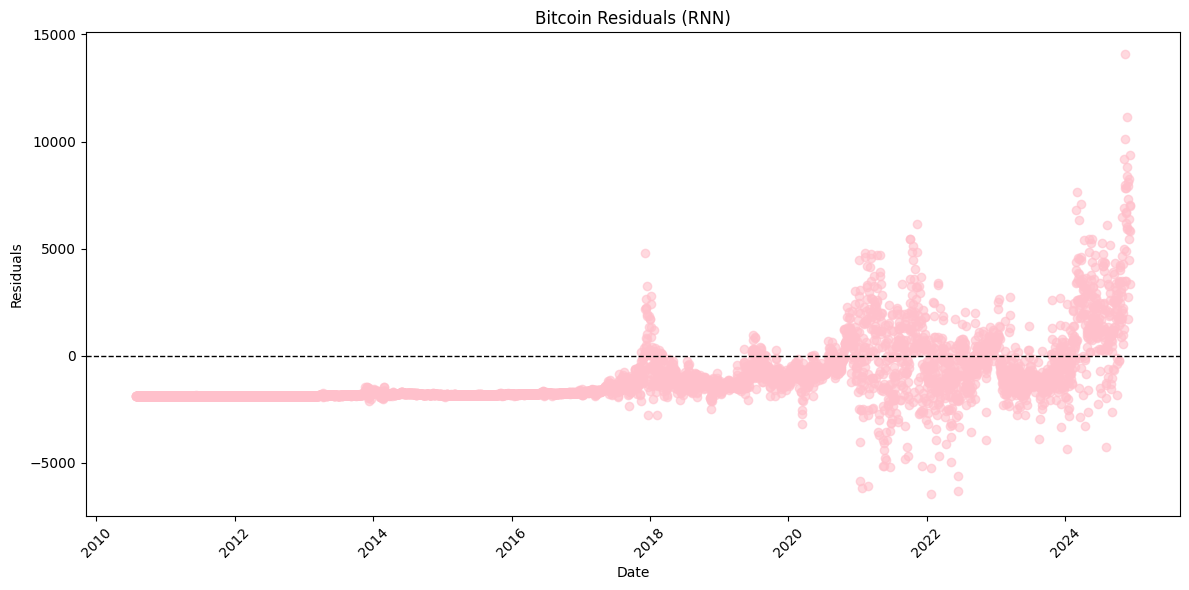

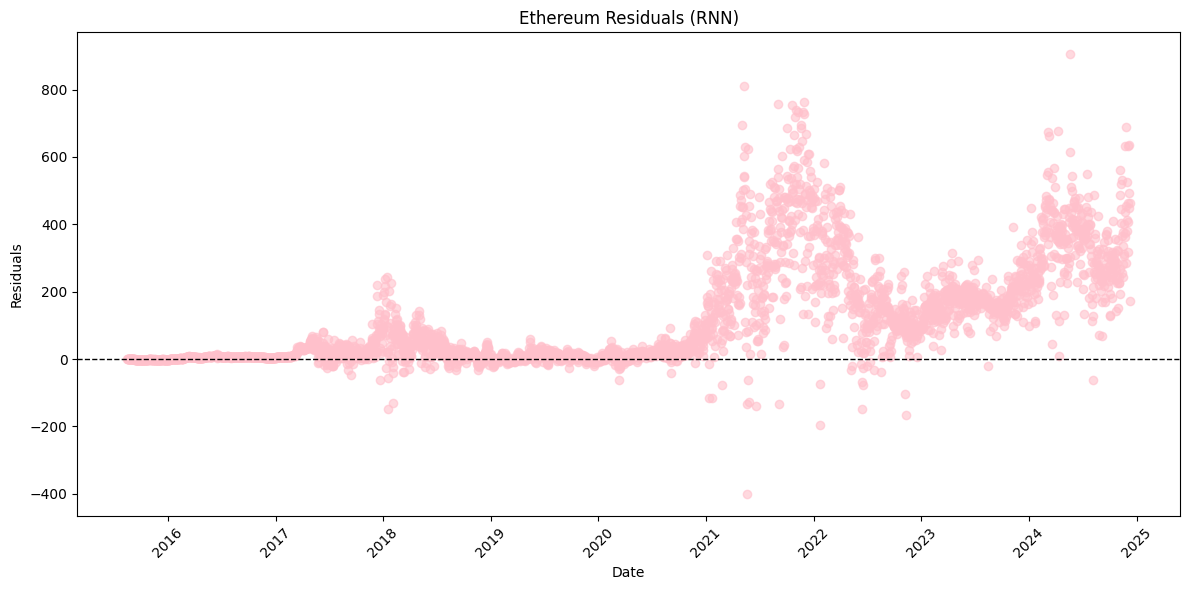

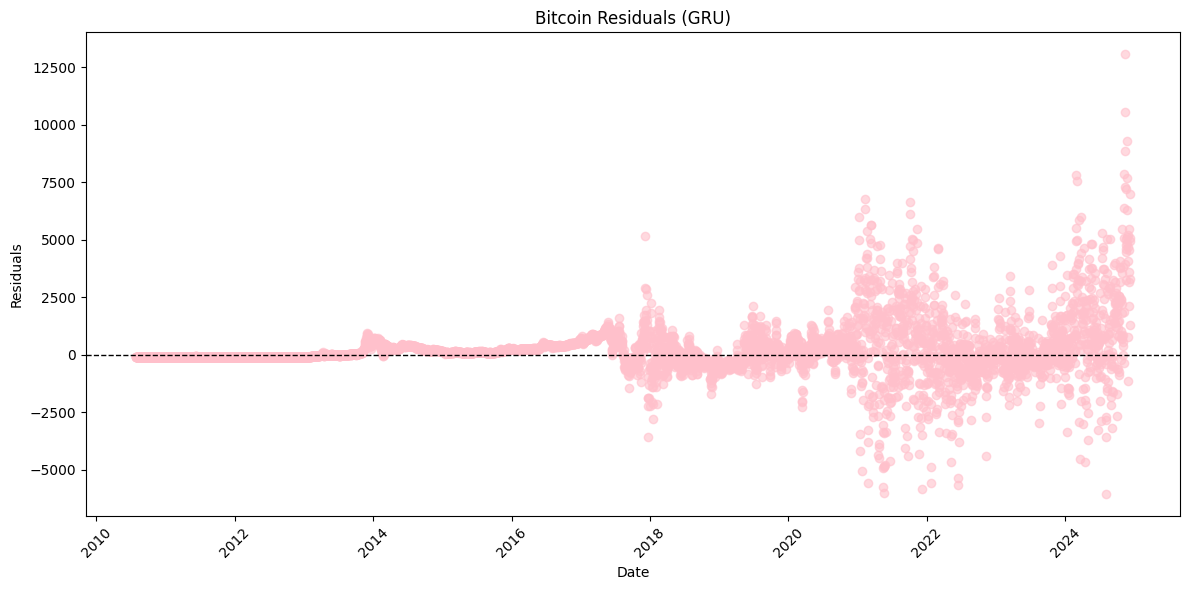

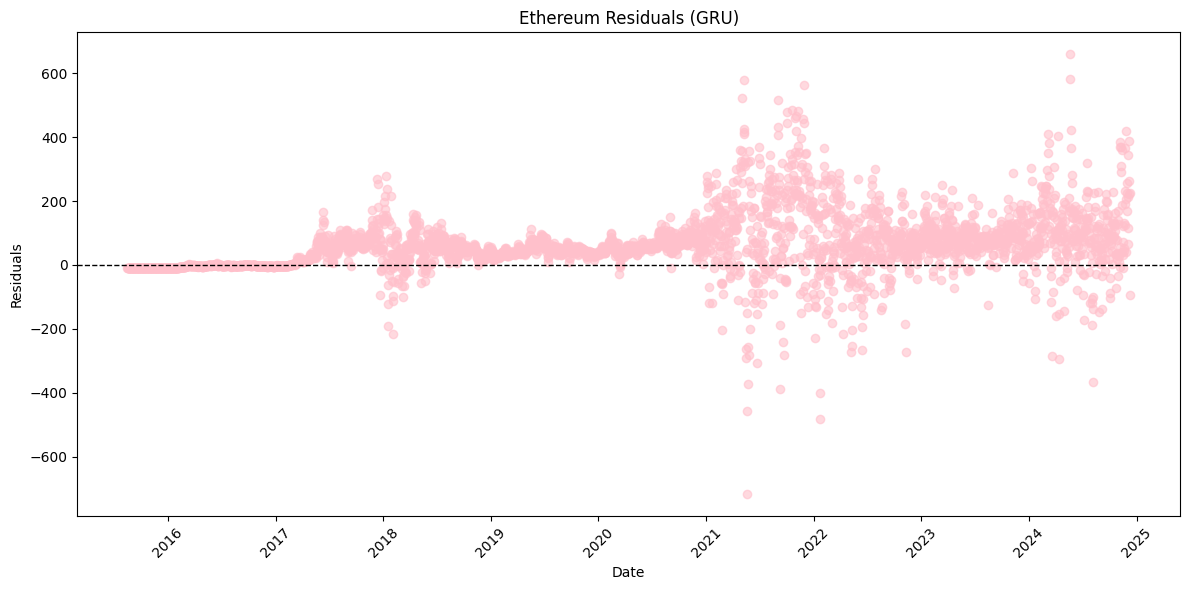

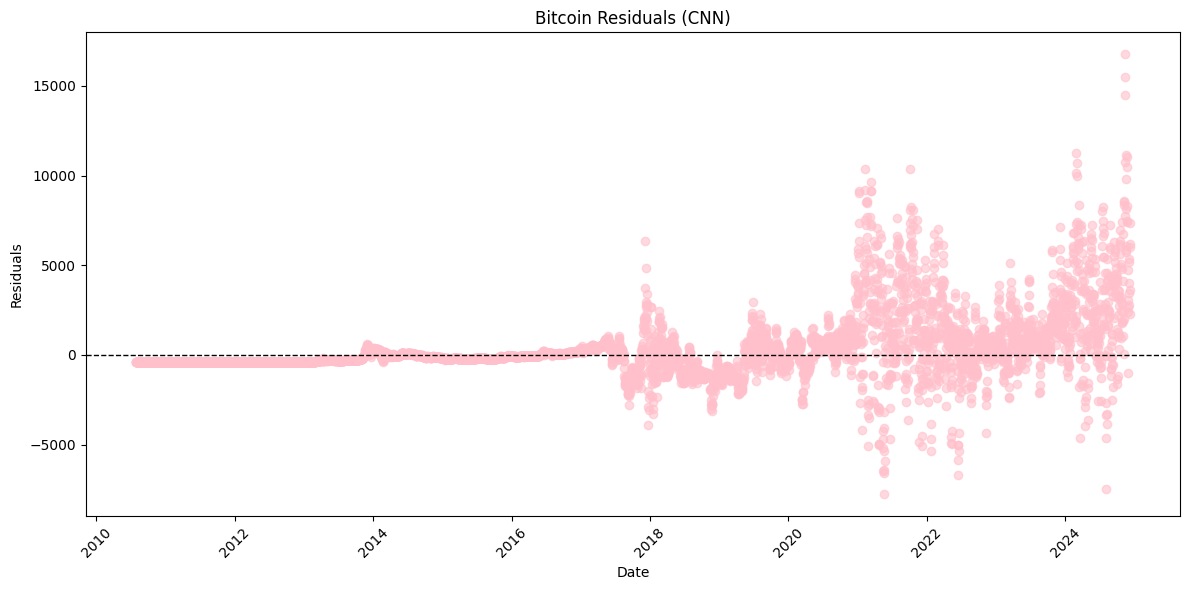

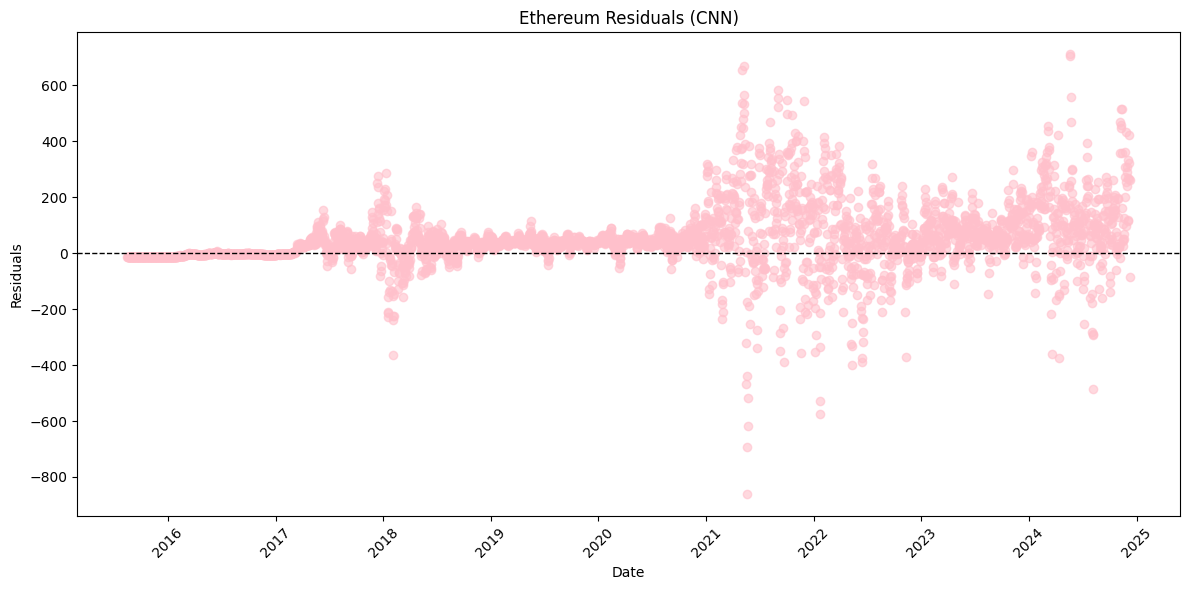

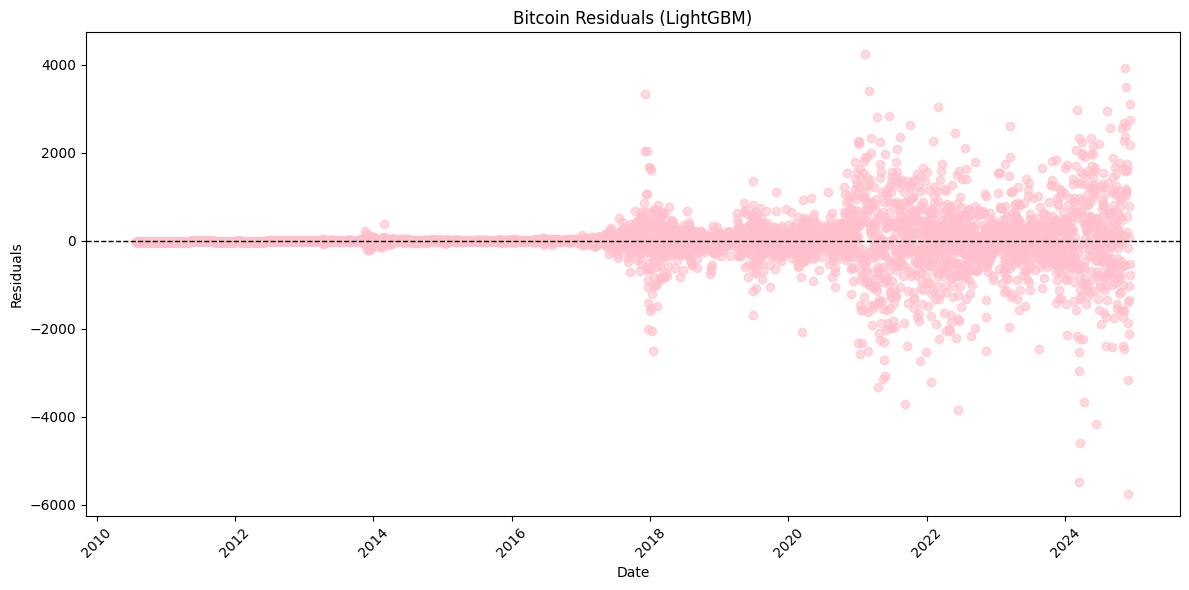

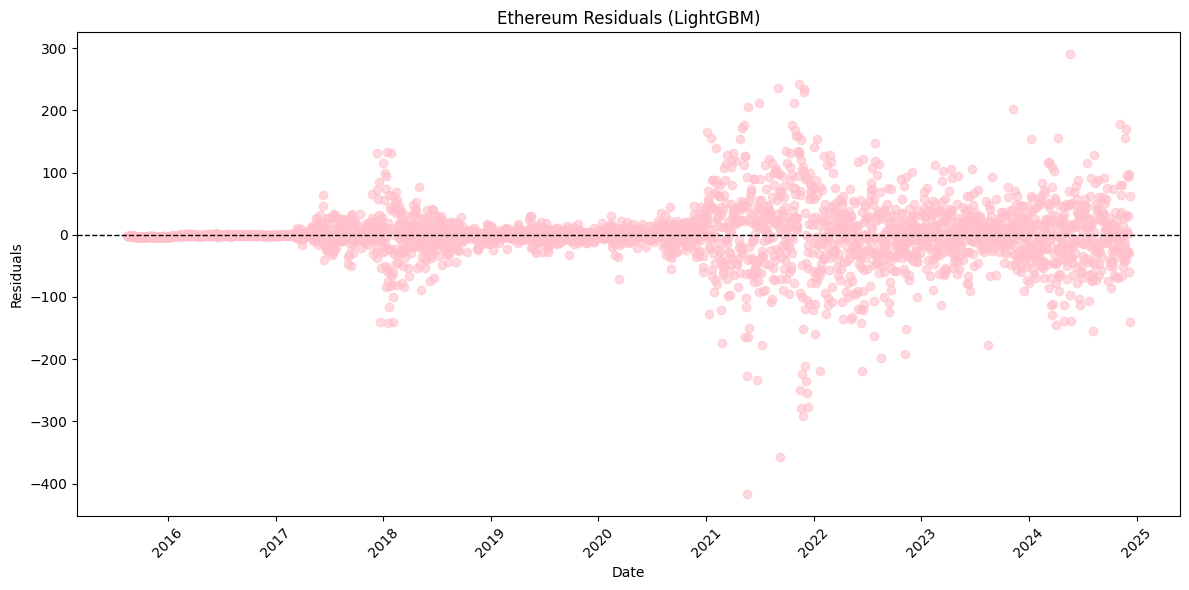

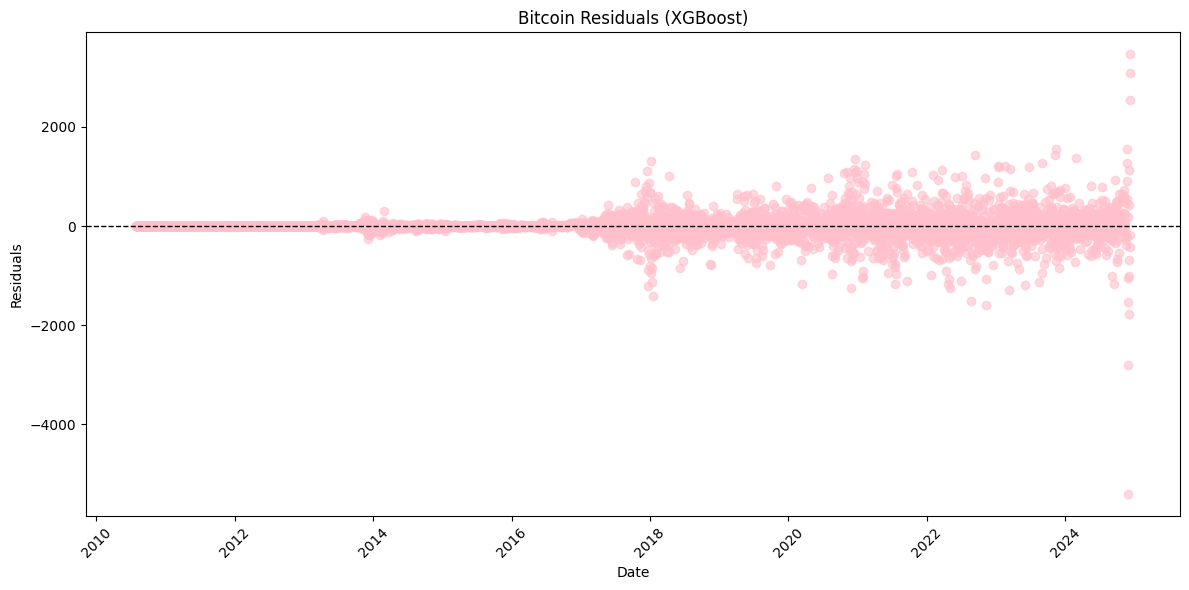

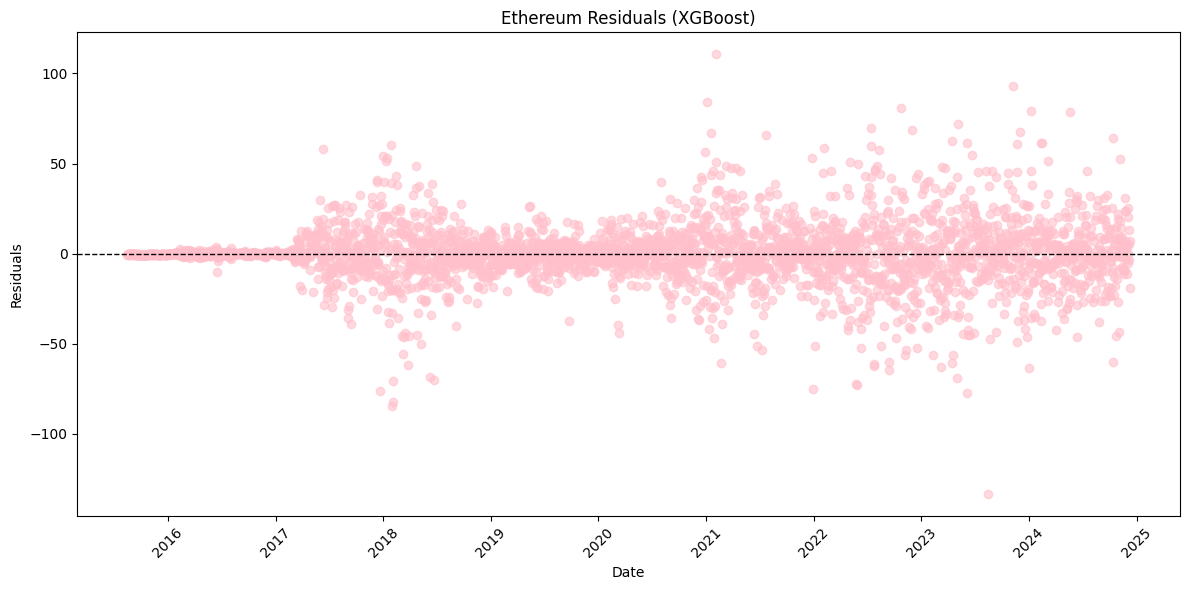

In [ ]:
# BTC and ETH - LSTM
plot_residuals(dates_btc, btc_lstm_actual, btc_lstm_pred, "Bitcoin Residuals (LSTM)")
plot_residuals(dates_eth, eth_lstm_actual, eth_lstm_pred, "Ethereum Residuals (LSTM)")

# BTC and ETH - RNN
plot_residuals(dates_btc, btc_rnn_actual, btc_rnn_pred, "Bitcoin Residuals (RNN)")
plot_residuals(dates_eth, eth_rnn_actual, eth_rnn_pred, "Ethereum Residuals (RNN)")

# BTC and ETH - GRU
plot_residuals(dates_btc, btc_gru_actual, btc_gru_pred, "Bitcoin Residuals (GRU)")
plot_residuals(dates_eth, eth_gru_actual, eth_gru_pred, "Ethereum Residuals (GRU)")

# BTC and ETH - CNN
plot_residuals(dates_btc, btc_cnn_actual, btc_cnn_pred, "Bitcoin Residuals (CNN)")
plot_residuals(dates_eth, eth_cnn_actual, eth_cnn_pred, "Ethereum Residuals (CNN)")

# BTC and ETH - LightGBM
plot_residuals(dates_btc, btc_lgbm_actual, btc_lgbm_pred, "Bitcoin Residuals (LightGBM)")
plot_residuals(dates_eth, eth_lgbm_actual, eth_lgbm_pred, "Ethereum Residuals (LightGBM)")

# BTC and ETH - XGBoost
plot_residuals(dates_btc, btc_xgb_actual, btc_xgb_pred, "Bitcoin Residuals (XGBoost)")
plot_residuals(dates_eth, eth_xgb_actual, eth_xgb_pred, "Ethereum Residuals (XGBoost)")

In [ ]:
def save_residuals_to_csv(ticker, model_name, dates, actual, predicted, filename="/content/models_residuals_results.csv"):
    file_exists = False
    try:
        with open(filename, "r", encoding="utf-8"):
            file_exists = True
    except FileNotFoundError:
        pass

    with open(filename, mode='a', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        if not file_exists:
            writer.writerow(["ticker", "model", "date", "actual", "predicted", "residuals"])

        for date, act, pred in zip(dates, actual, predicted):
            formatted_date = str(date).split("T")[0]
            act_value = float(act)
            pred_value = float(pred)
            residual = act_value - pred_value
            writer.writerow([ticker, model_name, formatted_date, act_value, pred_value, residual])

In [ ]:
# BTC and ETH - LSTM
save_residuals_to_csv("BTC", "LSTM", dates_btc, btc_lstm_actual, btc_lstm_pred)
save_residuals_to_csv("ETH", "LSTM", dates_eth, eth_lstm_actual, eth_lstm_pred)

# BTC and ETH - RNN
save_residuals_to_csv("BTC", "RNN", dates_btc, btc_rnn_actual, btc_rnn_pred)
save_residuals_to_csv("ETH", "RNN", dates_eth, eth_rnn_actual, eth_rnn_pred)

# BTC and ETH - GRU
save_residuals_to_csv("BTC", "GRU", dates_btc, btc_gru_actual, btc_gru_pred)
save_residuals_to_csv("ETH", "GRU", dates_eth, eth_gru_actual, eth_gru_pred)

# BTC and ETH - CNN
save_residuals_to_csv("BTC", "CNN", dates_btc, btc_cnn_actual, btc_cnn_pred)
save_residuals_to_csv("ETH", "CNN", dates_eth, eth_cnn_actual, eth_cnn_pred)

# BTC and ETH - LightGBM
save_residuals_to_csv("BTC", "LightGBM", dates_btc, btc_lgbm_actual, btc_lgbm_pred)
save_residuals_to_csv("ETH", "LightGBM", dates_eth, eth_lgbm_actual, eth_lgbm_pred)

# BTC and ETH - XGBoost
save_residuals_to_csv("BTC", "XGBoost", dates_btc, btc_xgb_actual, btc_xgb_pred)
save_residuals_to_csv("ETH", "XGBoost", dates_eth, eth_xgb_actual, eth_xgb_pred)

<ipython-input-45-1048d92f1ccc>:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  act_value = float(act)
<ipython-input-45-1048d92f1ccc>:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_value = float(pred)


In [ ]:
df = pd.read_csv("/content/models_residuals_results.csv")
print(df)

      ticker    model        date      actual    predicted   residuals
0        BTC     LSTM  2010-07-27     0.06000   393.586487 -393.526487
1        BTC     LSTM  2010-07-28     0.05890   393.587982 -393.529082
2        BTC     LSTM  2010-07-29     0.06990   393.585358 -393.515458
3        BTC     LSTM  2010-07-30     0.06270   393.582733 -393.520033
4        BTC     LSTM  2010-07-31     0.06785   393.581238 -393.513388
...      ...      ...         ...         ...          ...         ...
51913    ETH  XGBoost  2024-12-05  3810.87000  3814.437012   -3.567012
51914    ETH  XGBoost  2024-12-06  4029.36000  4016.336182   13.023818
51915    ETH  XGBoost  2024-12-07  4002.99000  3997.451416    5.538584
51916    ETH  XGBoost  2024-12-08  4012.79000  4005.697998    7.092002
51917    ETH  XGBoost  2024-12-09  3716.70000  3735.852783  -19.152783

[51918 rows x 6 columns]


Error Distribution Plots for BTC and ETH (Across Different Models)

**Purpose**:
- Visualize the distribution of errors (the difference between actual and predicted values) for Bitcoin (BTC) and Ethereum (ETH) across different prediction models.
- Evaluate the performance of each model by understanding the spread and nature of errors.

**Description**:
1. **Function Overview**:
   - The `plot_error_distribution` function calculates the errors by subtracting the predicted values from the actual values.
   - The errors are plotted as a histogram with a kernel density estimate (KDE) to show the distribution of prediction errors.
   - **X-axis**: Represents the error values (actual - predicted).
   - **Y-axis**: Represents the frequency (how often a particular error occurs).
   - **Color**: Red is used to highlight the error distribution.
   
2. **Model Comparisons**:
   - Error distributions are plotted for the following models:
     - **LSTM**: Long Short-Term Memory networks, which capture long-term dependencies.
     - **RNN**: Recurrent Neural Networks, designed for sequential data processing.
     - **CNN**: Convolutional Neural Networks, typically used to detect local patterns.
     - **GRU**: Gated Recurrent Units, a simplified version of LSTM for faster computation.
     - **XGBoost**: A tree-based model known for its speed and accuracy in regression tasks.
     - **LightGBM**: Another tree-based model optimized for performance on large datasets.

3. **BTC vs ETH**:
   - Error distributions are shown separately for Bitcoin (BTC) and Ethereum (ETH) for each model, allowing a detailed comparison between the two cryptocurrencies.
   
**Insights**:
- The distribution of errors helps assess the overall performance of each model.
- A narrow error distribution near zero indicates a more accurate model, while a wider distribution suggests higher error variability.
- Outliers in the error distribution may indicate areas where the model fails to capture certain trends or patterns in the data.
- By comparing the error distributions, we can better understand which models perform better for BTC and ETH.


In [ ]:
def plot_error_distribution(actual, predictions, title):
    errors = actual.flatten() - predictions.flatten()

    plt.figure(figsize=(12, 6))

    sns.histplot(errors, kde=True, bins=50, color="blue", edgecolor="black")
    plt.axvline(0, color='red', linestyle='--', linewidth=1, label="Zero Error")

    plt.title(title, fontsize=16)
    plt.xlabel("Prediction Error", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)

    max_error = max(abs(errors.min()), abs(errors.max()))
    plt.xlim(-max_error, max_error)

    plt.show()

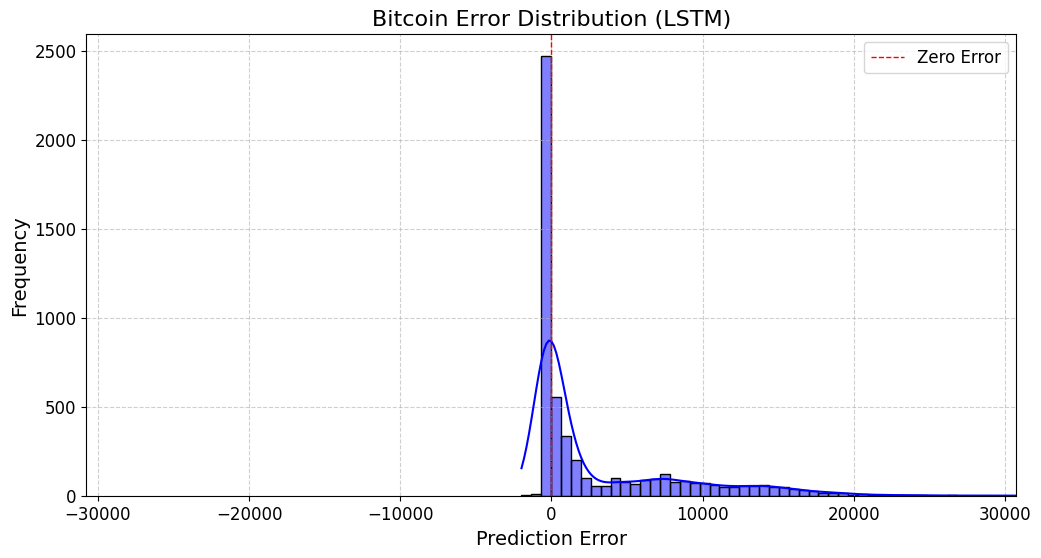

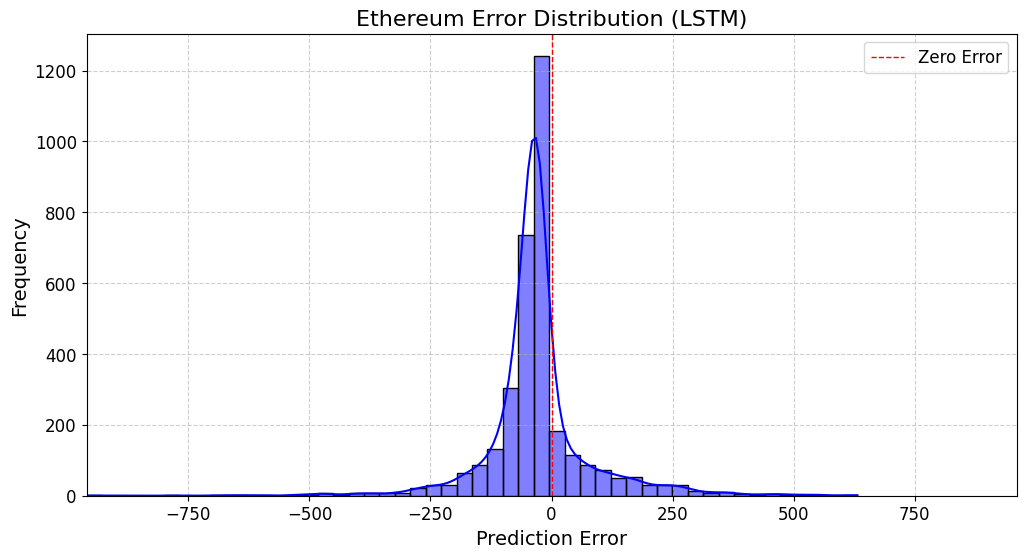

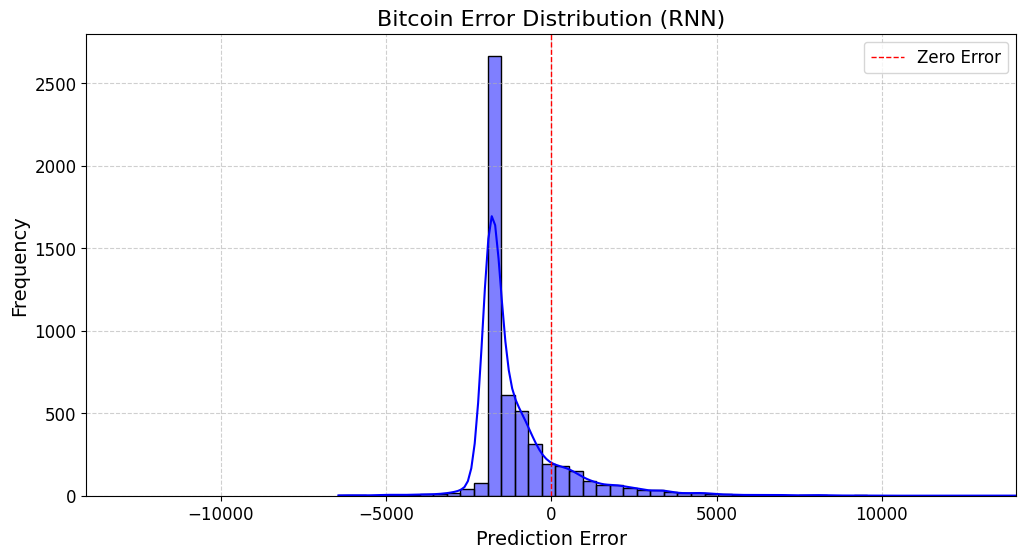

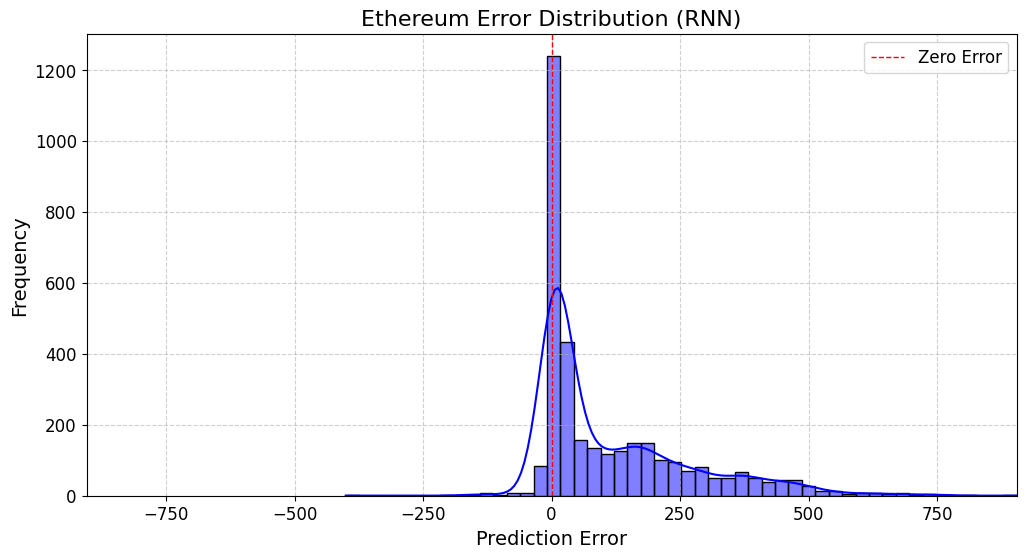

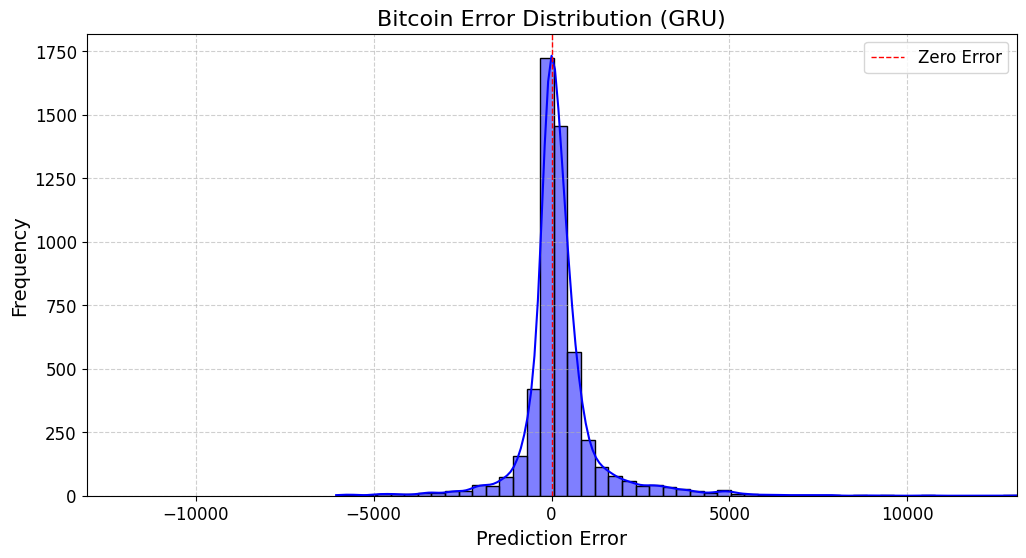

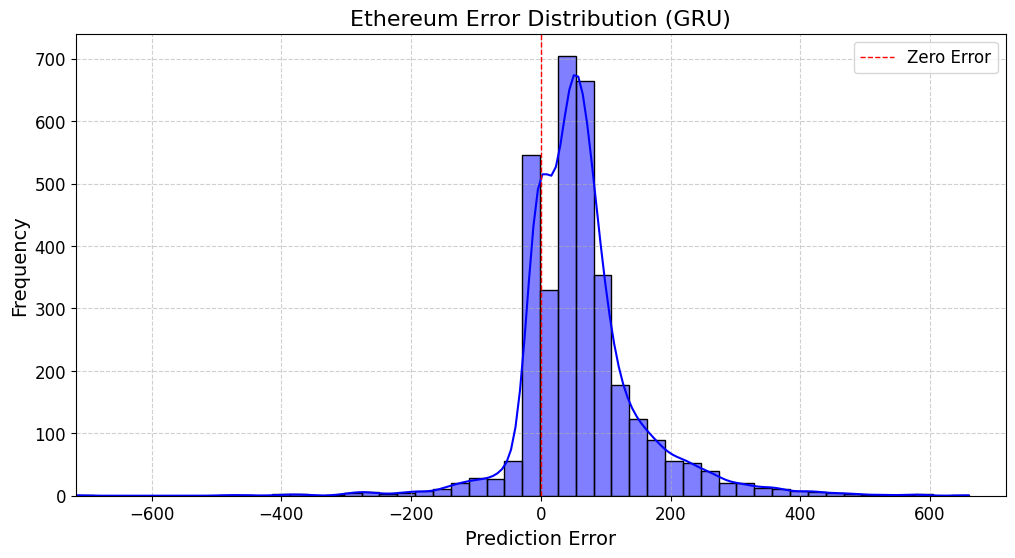

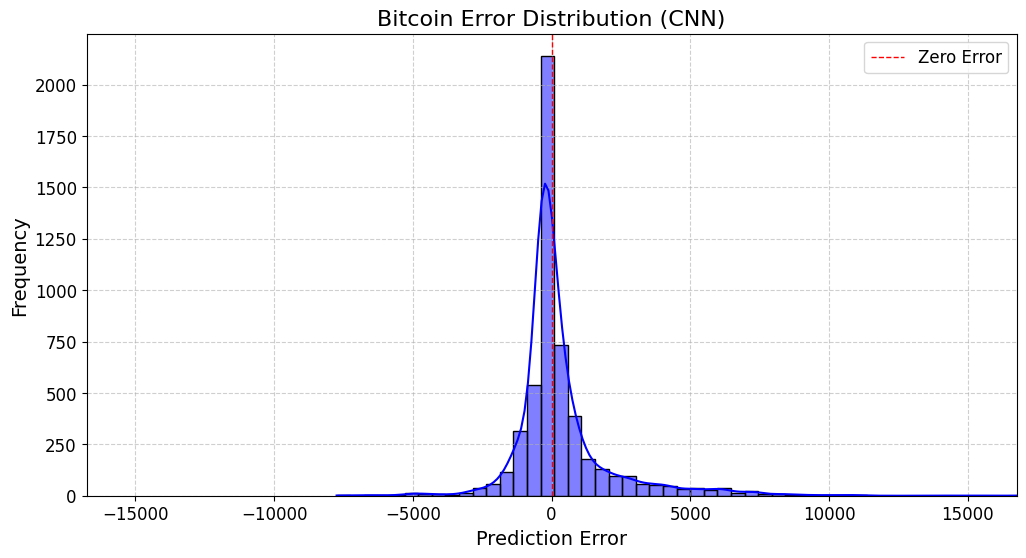

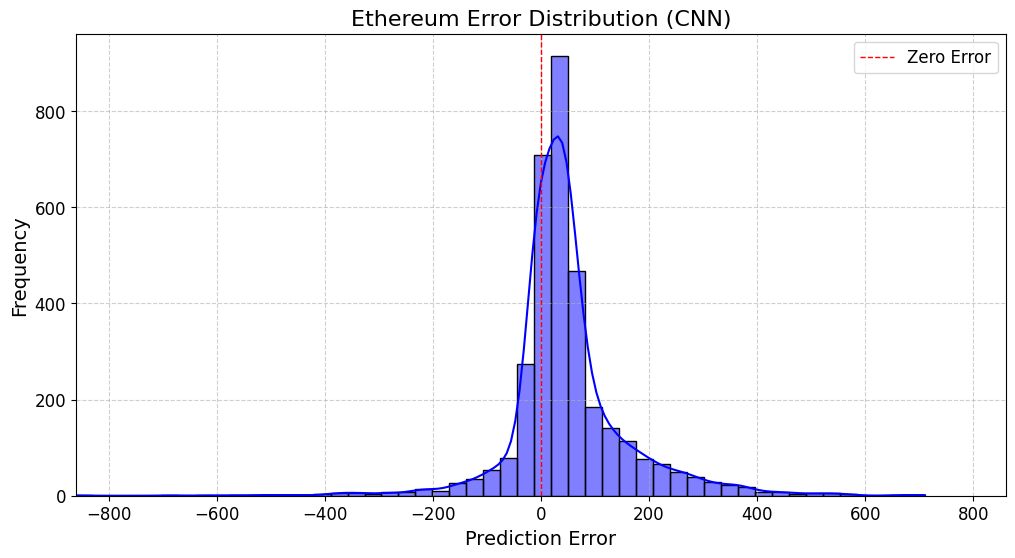

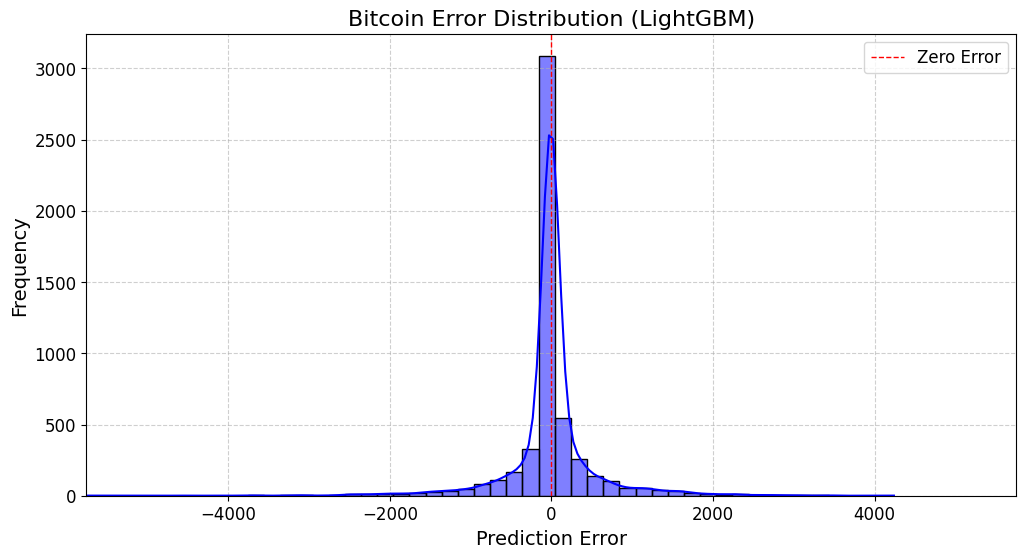

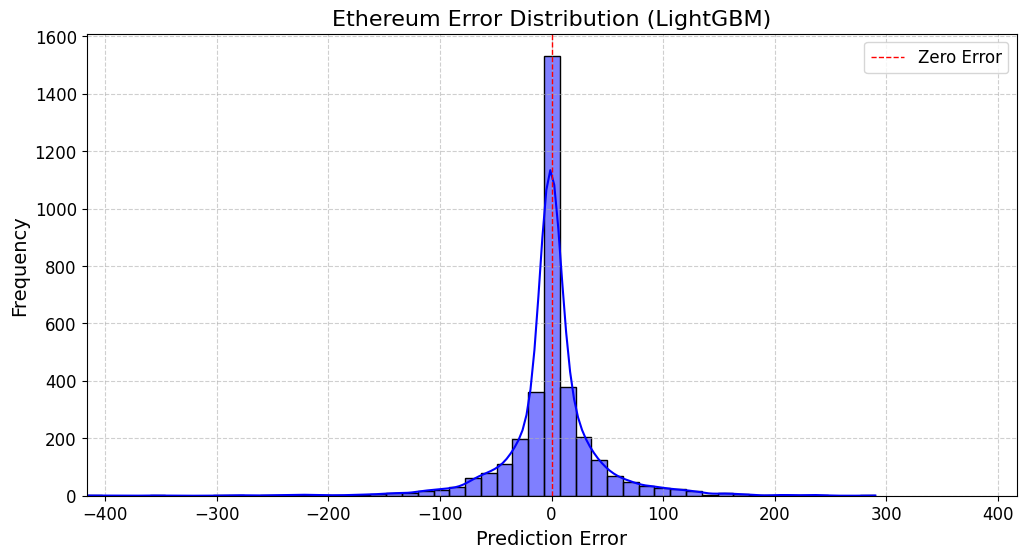

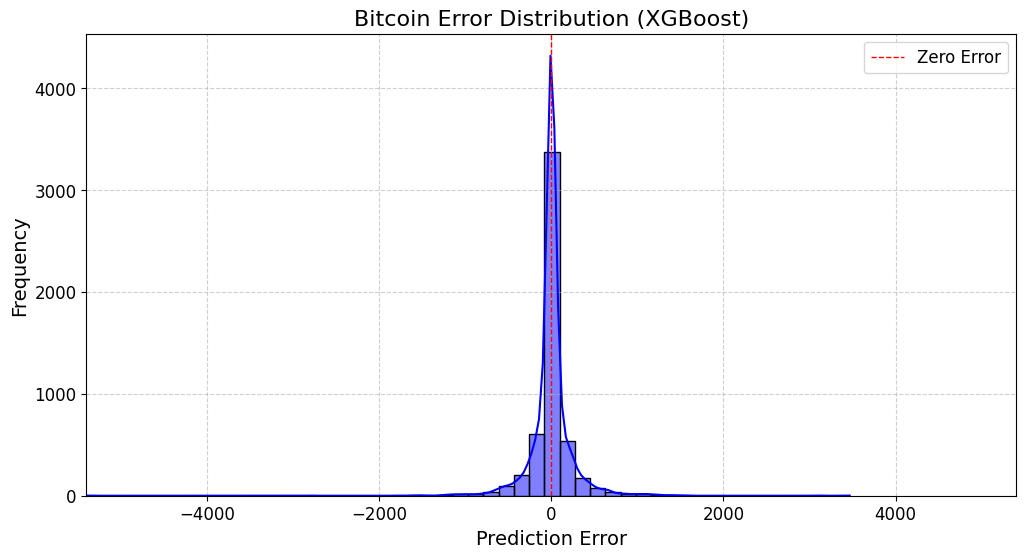

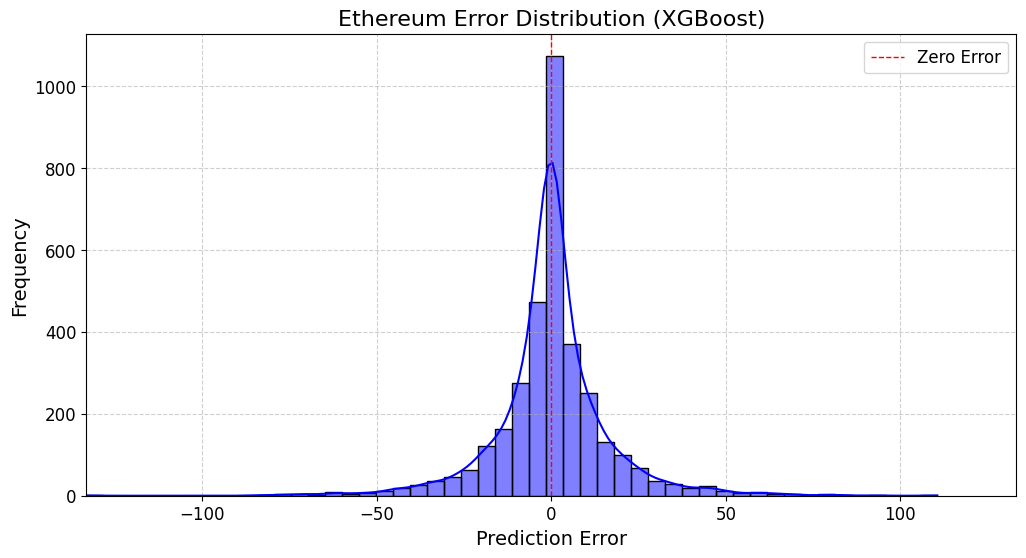

In [ ]:
# BTC and ETH - LSTM
plot_error_distribution(btc_lstm_actual, btc_lstm_pred, "Bitcoin Error Distribution (LSTM)")
plot_error_distribution(eth_lstm_actual, eth_lstm_pred, "Ethereum Error Distribution (LSTM)")

# BTC and ETH - RNN
plot_error_distribution(btc_rnn_actual, btc_rnn_pred, "Bitcoin Error Distribution (RNN)")
plot_error_distribution(eth_rnn_actual, eth_rnn_pred, "Ethereum Error Distribution (RNN)")

# BTC and ETH - GRU
plot_error_distribution(btc_gru_actual, btc_gru_pred, "Bitcoin Error Distribution (GRU)")
plot_error_distribution(eth_gru_actual, eth_gru_pred, "Ethereum Error Distribution (GRU)")

# BTC and ETH - CNN
plot_error_distribution(btc_cnn_actual, btc_cnn_pred, "Bitcoin Error Distribution (CNN)")
plot_error_distribution(eth_cnn_actual, eth_cnn_pred, "Ethereum Error Distribution (CNN)")

# BTC and ETH - LightGBM
plot_error_distribution(btc_lgbm_actual, btc_lgbm_pred, "Bitcoin Error Distribution (LightGBM)")
plot_error_distribution(eth_lgbm_actual, eth_lgbm_pred, "Ethereum Error Distribution (LightGBM)")

# BTC and ETH - XGBoost
plot_error_distribution(btc_xgb_actual, btc_xgb_pred, "Bitcoin Error Distribution (XGBoost)")
plot_error_distribution(eth_xgb_actual, eth_xgb_pred, "Ethereum Error Distribution (XGBoost)")

In [ ]:
def save_errors_distribution_to_csv(ticker, model_name, actual, predicted, filename="/content/models_errors_distribution_results.csv"):
    file_exists = False
    try:
        with open(filename, "r", encoding="utf-8"):
            file_exists = True
    except FileNotFoundError:
        pass

    with open(filename, mode='a', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        if not file_exists:
            writer.writerow(["ticker", "model", "error_bin", "frequency", "error_mean"])

        errors = [float(act) - float(pred) for act, pred in zip(actual, predicted)]

        hist, bins = np.histogram(errors, bins=50)

        bin_centers = 0.5 * (bins[:-1] + bins[1:])

        error_mean = np.mean(errors)

        for bin_center, freq in zip(bin_centers, hist):
            writer.writerow([ticker, model_name, float(bin_center), int(freq), float(error_mean)])

In [ ]:
# BTC and ETH - LSTM
save_errors_distribution_to_csv("BTC", "LSTM", btc_lstm_actual, btc_lstm_pred)
save_errors_distribution_to_csv("ETH", "LSTM", eth_lstm_actual, eth_lstm_pred)

# BTC and ETH - RNN
save_errors_distribution_to_csv("BTC", "RNN", btc_rnn_actual, btc_rnn_pred)
save_errors_distribution_to_csv("ETH", "RNN", eth_rnn_actual, eth_rnn_pred)

# BTC and ETH - GRU
save_errors_distribution_to_csv("BTC", "GRU", btc_gru_actual, btc_gru_pred)
save_errors_distribution_to_csv("ETH", "GRU", eth_gru_actual, eth_gru_pred)

# BTC and ETH - CNN
save_errors_distribution_to_csv("BTC", "CNN", btc_cnn_actual, btc_cnn_pred)
save_errors_distribution_to_csv("ETH", "CNN", eth_cnn_actual, eth_cnn_pred)

# BTC and ETH - LightGBM
save_errors_distribution_to_csv("BTC", "LightGBM", btc_lgbm_actual, btc_lgbm_pred)
save_errors_distribution_to_csv("ETH", "LightGBM", eth_lgbm_actual, eth_lgbm_pred)

# BTC and ETH - XGBoost
save_errors_distribution_to_csv("BTC", "XGBoost", btc_xgb_actual, btc_xgb_pred)
save_errors_distribution_to_csv("ETH", "XGBoost", eth_xgb_actual, eth_xgb_pred)

<ipython-input-50-ef1e173e8785>:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  errors = [float(act) - float(pred) for act, pred in zip(actual, predicted)]


In [ ]:
df = pd.read_csv("/content/models_errors_distribution_results.csv")
print(df)

    ticker    model    error_bin  frequency   error_mean
0      BTC     LSTM -1651.503002          6  2992.129354
1      BTC     LSTM  -996.739163          9  2992.129354
2      BTC     LSTM  -341.975324       2471  2992.129354
3      BTC     LSTM   312.788515        557  2992.129354
4      BTC     LSTM   967.552354        337  2992.129354
..     ...      ...          ...        ...          ...
595    ETH  XGBoost    88.657915          0    -0.003386
596    ETH  XGBoost    93.535363          1    -0.003386
597    ETH  XGBoost    98.412811          0    -0.003386
598    ETH  XGBoost   103.290259          0    -0.003386
599    ETH  XGBoost   108.167707          1    -0.003386

[600 rows x 5 columns]


Actual vs Predicted Plots for BTC and ETH (Across Different Models)

**Purpose**:
- Visualize the relationship between actual and predicted values for Bitcoin (BTC) and Ethereum (ETH) across various prediction models.
- Assess how well each model's predictions align with the actual data by comparing the two sets of values.

**Description**:
1. **Function Overview**:
   - The `plot_actual_vs_predicted` function creates a scatter plot that shows the actual values on the x-axis and the predicted values on the y-axis.
   - **X-axis**: Represents the actual values (e.g., actual Bitcoin or Ethereum close prices).
   - **Y-axis**: Represents the predicted values generated by the model.
   - A diagonal line (`[actual.min(), actual.max()]`) is included to represent the ideal case where predicted values exactly match the actual values.
   - **Color**: The points are shown in green to represent the relationship between actual and predicted values.
   - The closer the points are to the diagonal line, the better the model’s performance.

2. **Model Comparisons**:
   - The scatter plot is generated for the following models:
     - **LSTM**: Long Short-Term Memory networks, designed for capturing long-term dependencies in time-series data.
     - **RNN**: Recurrent Neural Networks, which process sequential data and are simpler than LSTMs.
     - **CNN**: Convolutional Neural Networks, primarily used for detecting local patterns in time-series data.
     - **GRU**: Gated Recurrent Units, a simplified version of LSTM with faster computation.
     - **XGBoost**: A tree-based model known for its speed and accuracy in regression tasks.
     - **LightGBM**: A highly efficient gradient boosting model designed for fast performance on large datasets.

3. **BTC vs ETH**:
   - The actual vs predicted plots are displayed separately for Bitcoin (BTC) and Ethereum (ETH), allowing for a focused analysis of prediction performance for each cryptocurrency.
   
**Insights**:
- The closer the scatter points are to the diagonal line, the better the model’s ability to predict actual values.
- Helps to identify how well each model has captured the general trend in the data.
- The scatter plot provides insight into periods when predictions were far from actual values, highlighting potential areas of model weakness.
- Comparing actual vs predicted plots for different models allows for selecting the model that performs best for BTC and ETH prediction.


In [ ]:
def plot_actual_vs_predicted(actual, predictions, title):
    plt.figure(figsize=(12, 6))
    plt.scatter(actual, predictions, alpha=0.6, color='green')
    plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], color='black', linestyle='--', linewidth=1)
    plt.title(title)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

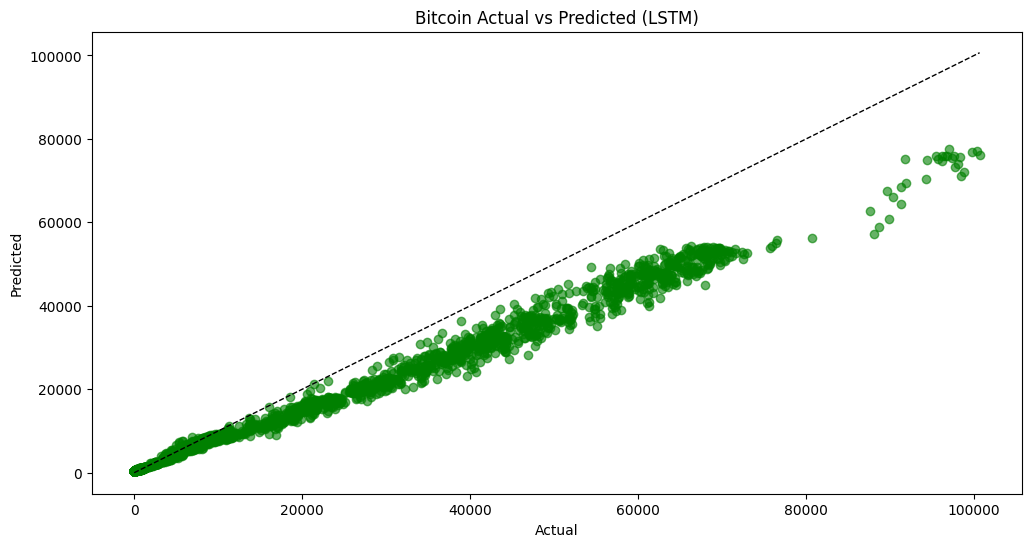

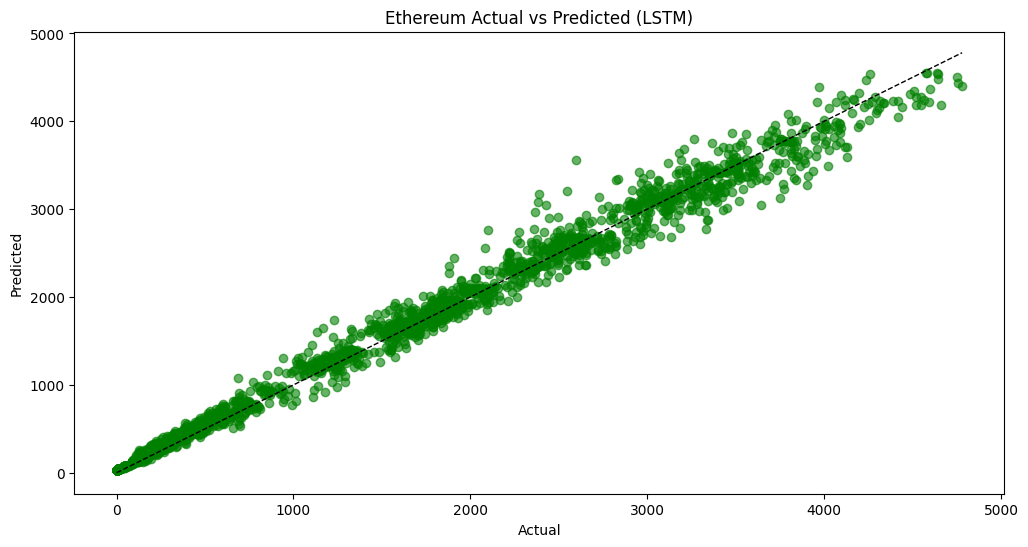

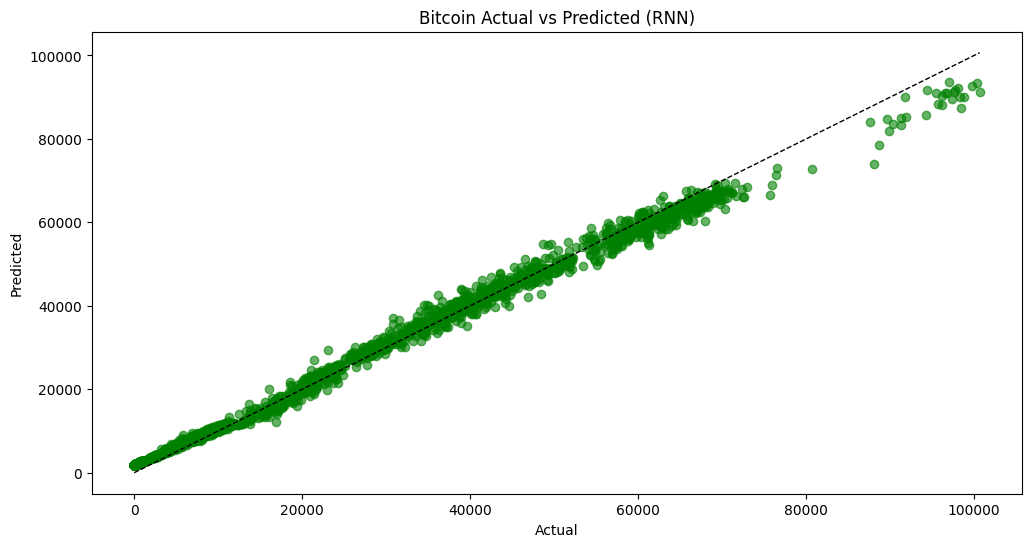

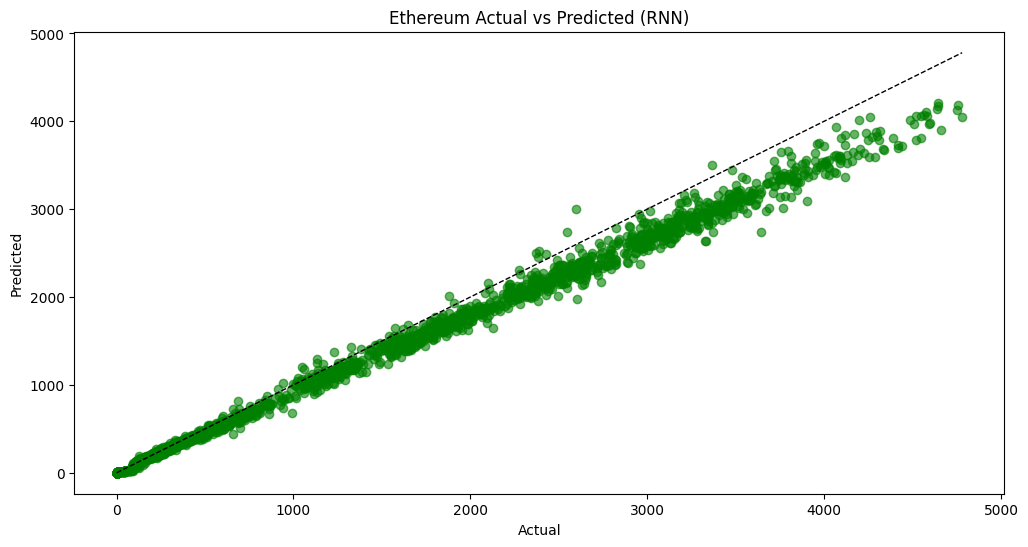

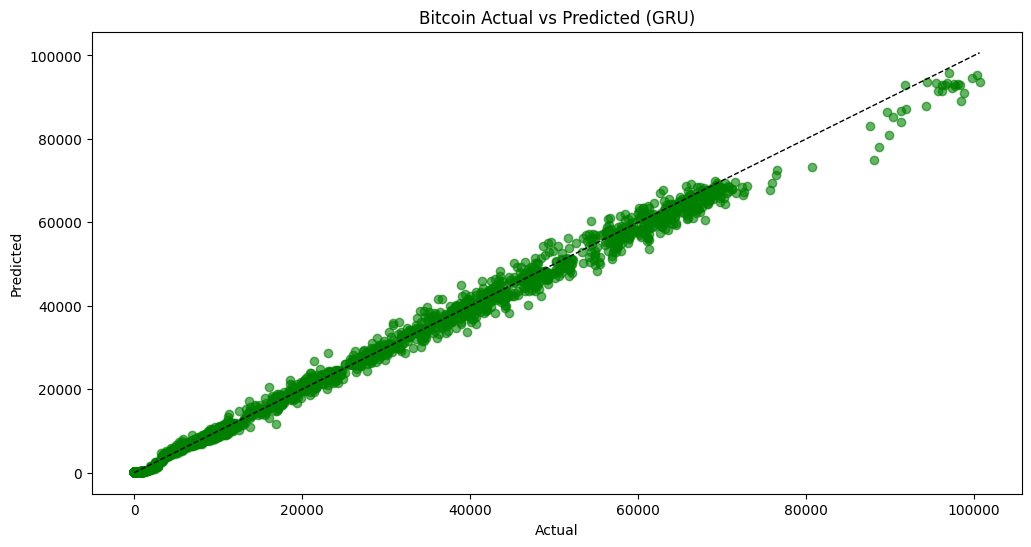

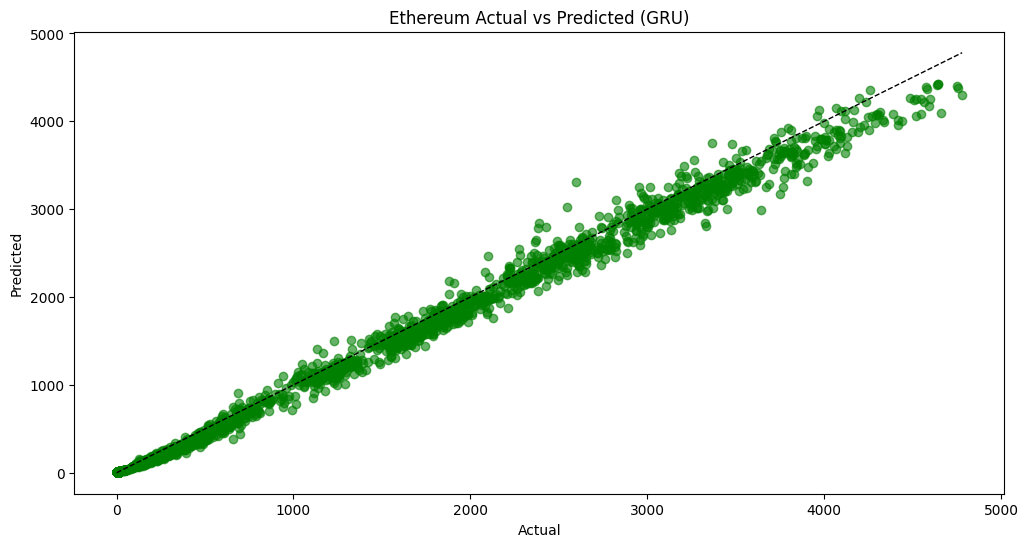

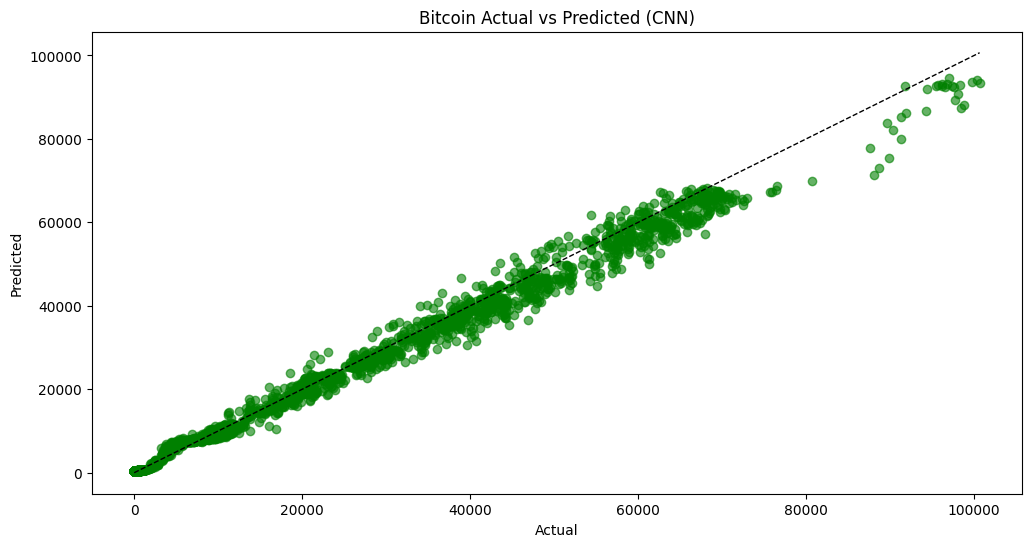

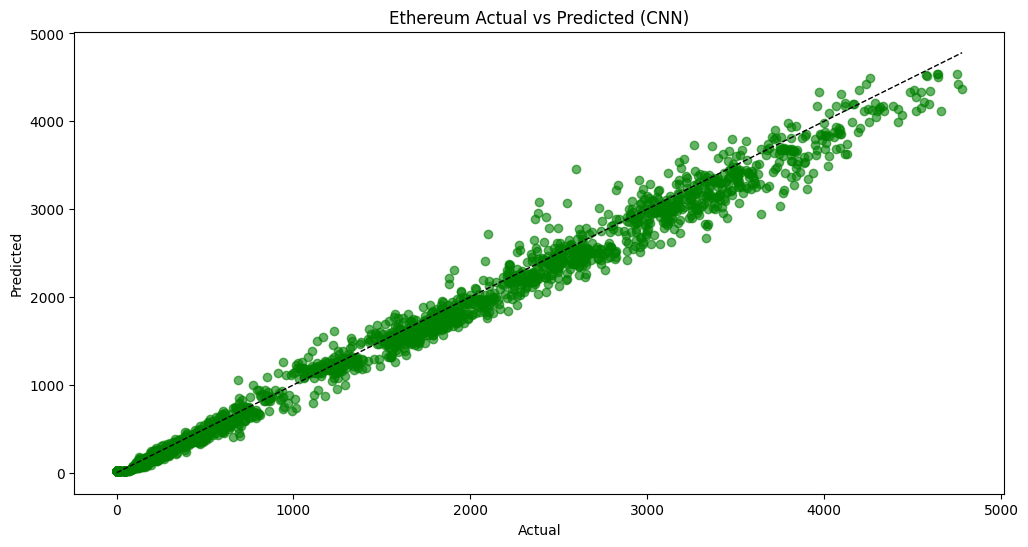

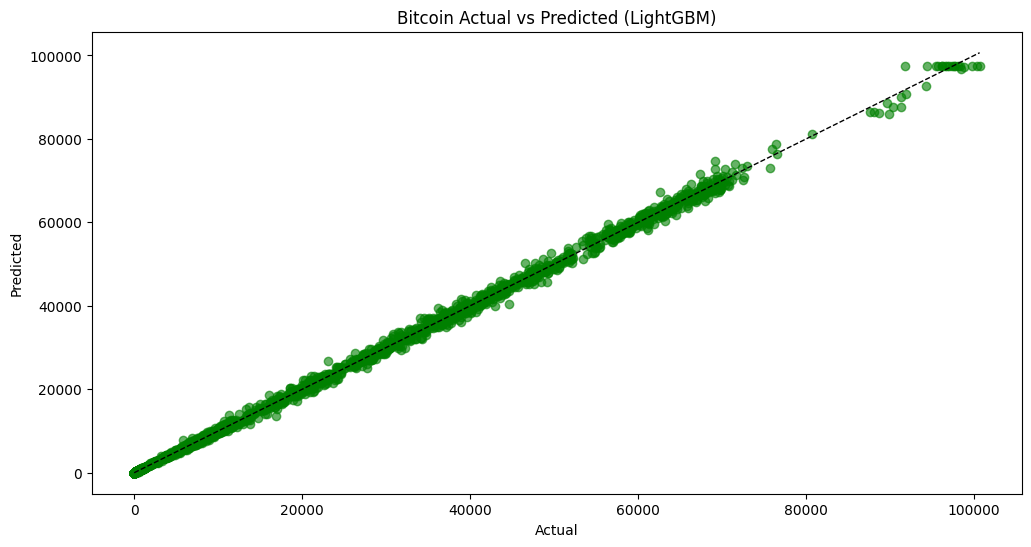

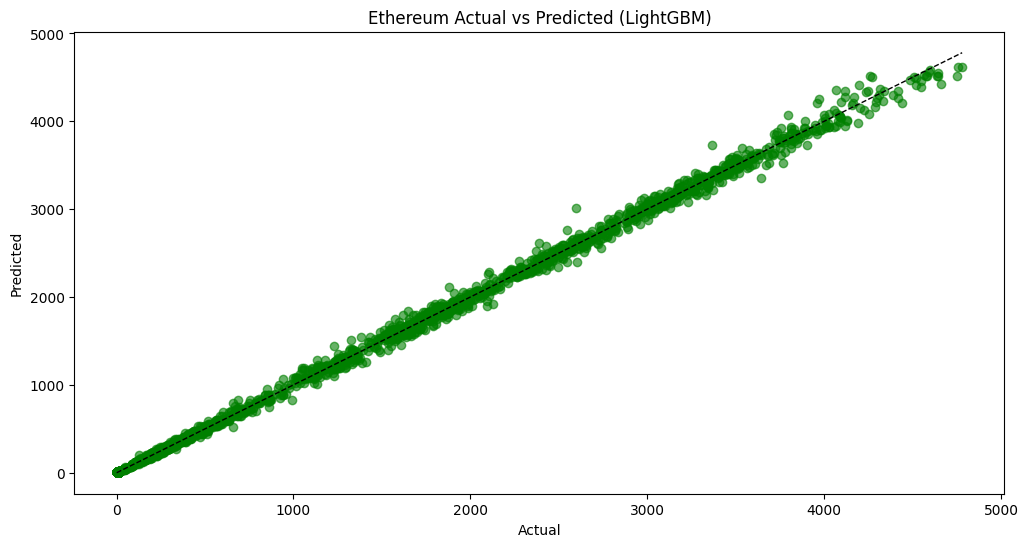

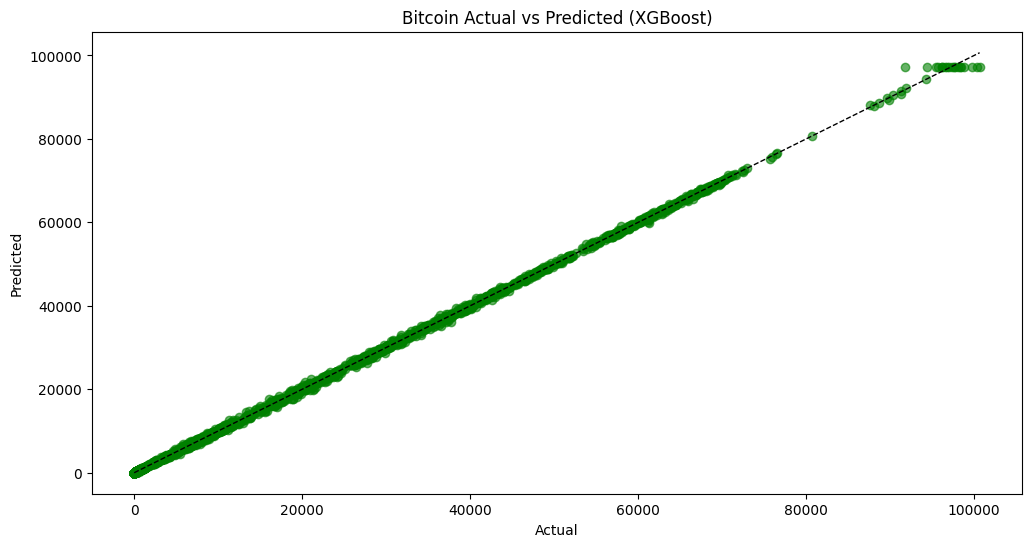

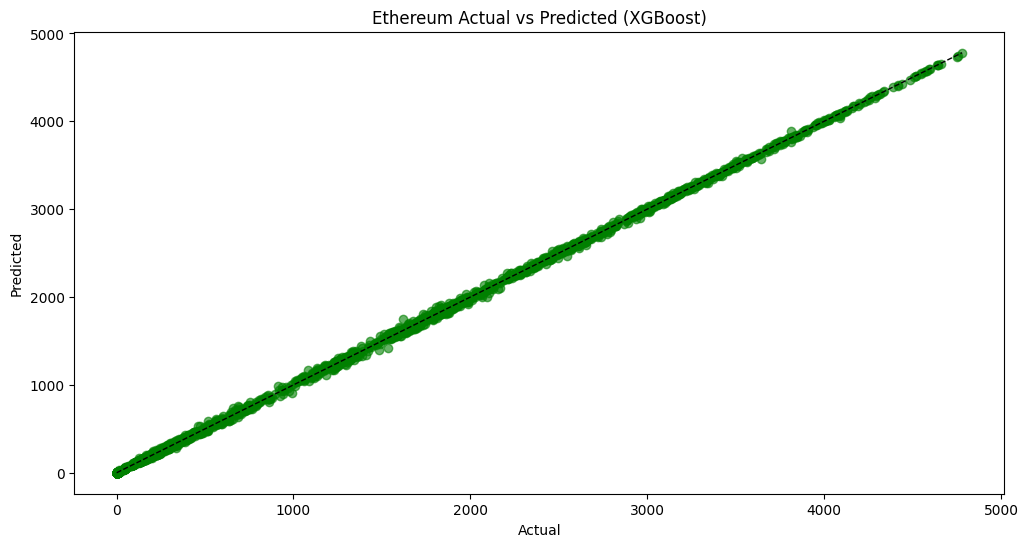

In [ ]:
# BTC and ETH - LSTM
plot_actual_vs_predicted(btc_lstm_actual, btc_lstm_pred, "Bitcoin Actual vs Predicted (LSTM)")
plot_actual_vs_predicted(eth_lstm_actual, eth_lstm_pred, "Ethereum Actual vs Predicted (LSTM)")

# BTC and ETH - RNN
plot_actual_vs_predicted(btc_rnn_actual, btc_rnn_pred, "Bitcoin Actual vs Predicted (RNN)")
plot_actual_vs_predicted(eth_rnn_actual, eth_rnn_pred, "Ethereum Actual vs Predicted (RNN)")

# BTC and ETH - GRU
plot_actual_vs_predicted(btc_gru_actual, btc_gru_pred, "Bitcoin Actual vs Predicted (GRU)")
plot_actual_vs_predicted(eth_gru_actual, eth_gru_pred, "Ethereum Actual vs Predicted (GRU)")

# BTC and ETH - CNN
plot_actual_vs_predicted(btc_cnn_actual, btc_cnn_pred, "Bitcoin Actual vs Predicted (CNN)")
plot_actual_vs_predicted(eth_cnn_actual, eth_cnn_pred, "Ethereum Actual vs Predicted (CNN)")

# BTC and ETH - LightGBM
plot_actual_vs_predicted(btc_lgbm_actual, btc_lgbm_pred, "Bitcoin Actual vs Predicted (LightGBM)")
plot_actual_vs_predicted(eth_lgbm_actual, eth_lgbm_pred, "Ethereum Actual vs Predicted (LightGBM)")

# BTC and ETH - XGBoost
plot_actual_vs_predicted(btc_xgb_actual, btc_xgb_pred, "Bitcoin Actual vs Predicted (XGBoost)")
plot_actual_vs_predicted(eth_xgb_actual, eth_xgb_pred, "Ethereum Actual vs Predicted (XGBoost)")

In [ ]:
def save_actual_vs_predicted_to_csv(ticker, model_name, actual, predicted, filename="/content/models_actual_vs_predicted_results.csv"):
    file_exists = False
    try:
        with open(filename, "r", encoding="utf-8"):
            file_exists = True
    except FileNotFoundError:
        pass

    with open(filename, mode='a', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        if not file_exists:
            writer.writerow(["ticker", "model", "actual", "predicted"])
        for act, pred in zip(actual, predicted):
            writer.writerow([ticker, model_name, float(act), float(pred)])

In [ ]:
# BTC and ETH - LSTM
save_actual_vs_predicted_to_csv("BTC", "LSTM", btc_lstm_actual, btc_lstm_pred)
save_actual_vs_predicted_to_csv("ETH", "LSTM", eth_lstm_actual, eth_lstm_pred)

# BTC and ETH - RNN
save_actual_vs_predicted_to_csv("BTC", "RNN", btc_rnn_actual, btc_rnn_pred)
save_actual_vs_predicted_to_csv("ETH", "RNN", eth_rnn_actual, eth_rnn_pred)

# BTC and ETH - GRU
save_actual_vs_predicted_to_csv("BTC", "GRU", btc_gru_actual, btc_gru_pred)
save_actual_vs_predicted_to_csv("ETH", "GRU", eth_gru_actual, eth_gru_pred)

# BTC and ETH - CNN
save_actual_vs_predicted_to_csv("BTC", "CNN", btc_cnn_actual, btc_cnn_pred)
save_actual_vs_predicted_to_csv("ETH", "CNN", eth_cnn_actual, eth_cnn_pred)

# BTC and ETH - LightGBM
save_actual_vs_predicted_to_csv("BTC", "LightGBM", btc_lgbm_actual, btc_lgbm_pred)
save_actual_vs_predicted_to_csv("ETH", "LightGBM", eth_lgbm_actual, eth_lgbm_pred)

# BTC and ETH - XGBoost
save_actual_vs_predicted_to_csv("BTC", "XGBoost", btc_xgb_actual, btc_xgb_pred)
save_actual_vs_predicted_to_csv("ETH", "XGBoost", eth_xgb_actual, eth_xgb_pred)

<ipython-input-55-0a41b3d80df7>:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  writer.writerow([ticker, model_name, float(act), float(pred)])


In [ ]:
df = pd.read_csv("/content/models_actual_vs_predicted_results.csv")
print(df)

      ticker    model      actual    predicted
0        BTC     LSTM     0.06000   393.586487
1        BTC     LSTM     0.05890   393.587982
2        BTC     LSTM     0.06990   393.585358
3        BTC     LSTM     0.06270   393.582733
4        BTC     LSTM     0.06785   393.581238
...      ...      ...         ...          ...
51913    ETH  XGBoost  3810.87000  3814.437012
51914    ETH  XGBoost  4029.36000  4016.336182
51915    ETH  XGBoost  4002.99000  3997.451416
51916    ETH  XGBoost  4012.79000  4005.697998
51917    ETH  XGBoost  3716.70000  3735.852783

[51918 rows x 4 columns]


Cumulative Returns for BTC and ETH (Across Different Models)

**Purpose**:
- Visualize the cumulative returns of Bitcoin (BTC) and Ethereum (ETH) based on actual and predicted values across different models.
- Assess the performance of the models over time by evaluating the cumulative returns, which represent the total return accumulated over time.

**Description**:
1. **Function Overview**:
   - The `plot_cumulative_returns` function calculates the cumulative sum of actual and predicted returns using `np.cumsum()`.
   - **X-axis**: Time (could be represented as the index or time period).
   - **Y-axis**: Cumulative returns (the total return over time).
   - **Actual vs Predicted**: Two lines are plotted, one representing actual cumulative returns (blue) and one representing predicted cumulative returns (orange).
   - The plot helps to visualize how well the model's predictions align with the actual cumulative returns over time.

2. **Model Comparisons**:
   - Cumulative returns are plotted for the following models:
     - **LSTM**: Long Short-Term Memory networks, which capture long-term dependencies in the data.
     - **RNN**: Recurrent Neural Networks, simpler models compared to LSTM.
     - **CNN**: Convolutional Neural Networks, used to detect local patterns in time-series data.
     - **GRU**: Gated Recurrent Units, which offer faster computation compared to LSTM.
     - **XGBoost**: A powerful tree-based model known for its accuracy and speed.
     - **LightGBM**: A gradient boosting model optimized for performance on large datasets.

3. **BTC vs ETH**:
   - The cumulative returns plots are displayed separately for Bitcoin (BTC) and Ethereum (ETH) for each model, allowing for a detailed evaluation of each cryptocurrency's performance over time.
   
**Insights**:
- The closer the predicted cumulative returns line is to the actual cumulative returns line, the better the model has performed in predicting the cumulative returns over time.
- Helps identify trends, periods of high or low returns, and how well the model captures these fluctuations.
- The comparison of actual vs predicted cumulative returns gives insight into the predictive power of each model for BTC and ETH.
- Models that consistently align with actual returns indicate better predictive accuracy and performance.


In [ ]:
def plot_cumulative_returns(dates, actual, predictions, title):
    actual_returns = np.cumsum(actual)
    predicted_returns = np.cumsum(predictions)
    plt.figure(figsize=(12, 6))
    plt.plot(dates, actual_returns, label="Actual Cumulative Returns", color='blue')
    plt.plot(dates, predicted_returns, label="Predicted Cumulative Returns", color='green')
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Cumulative Returns")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

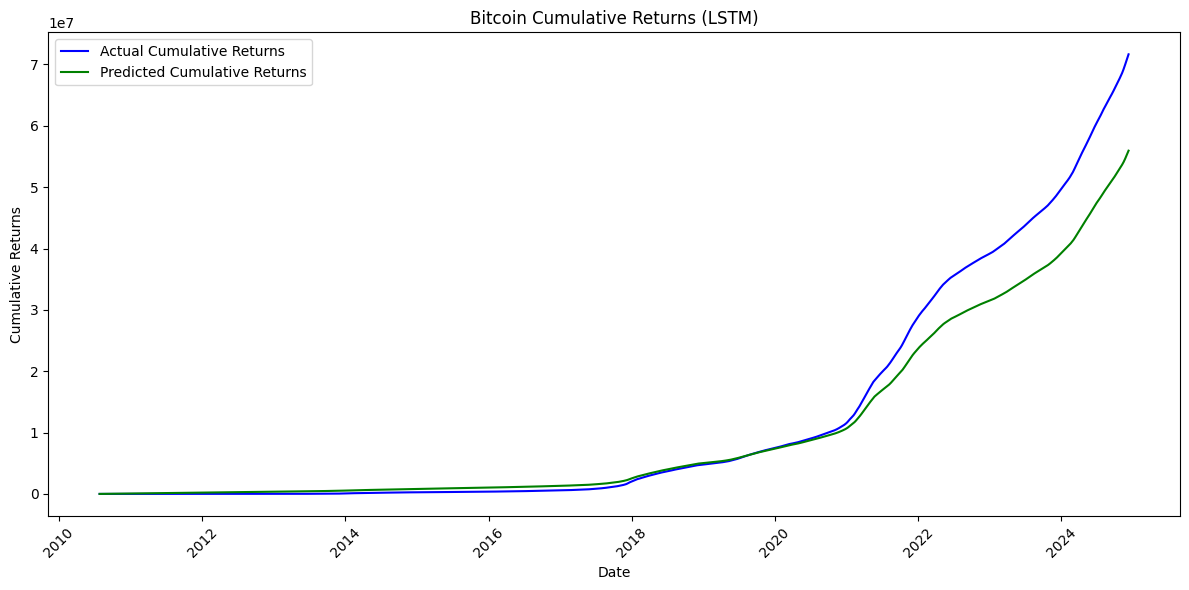

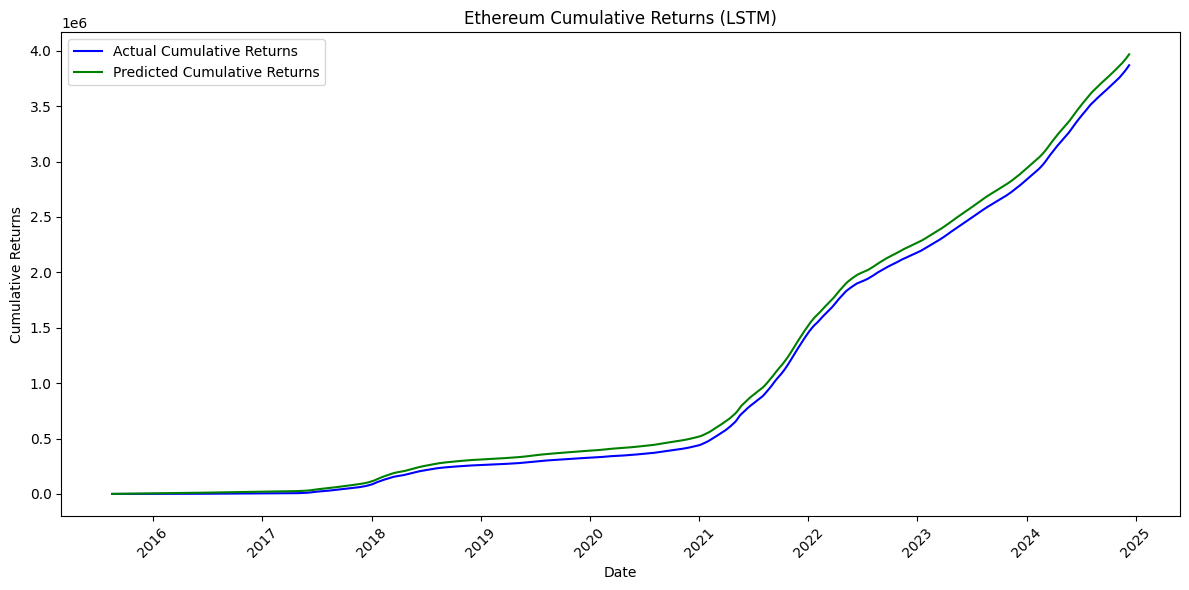

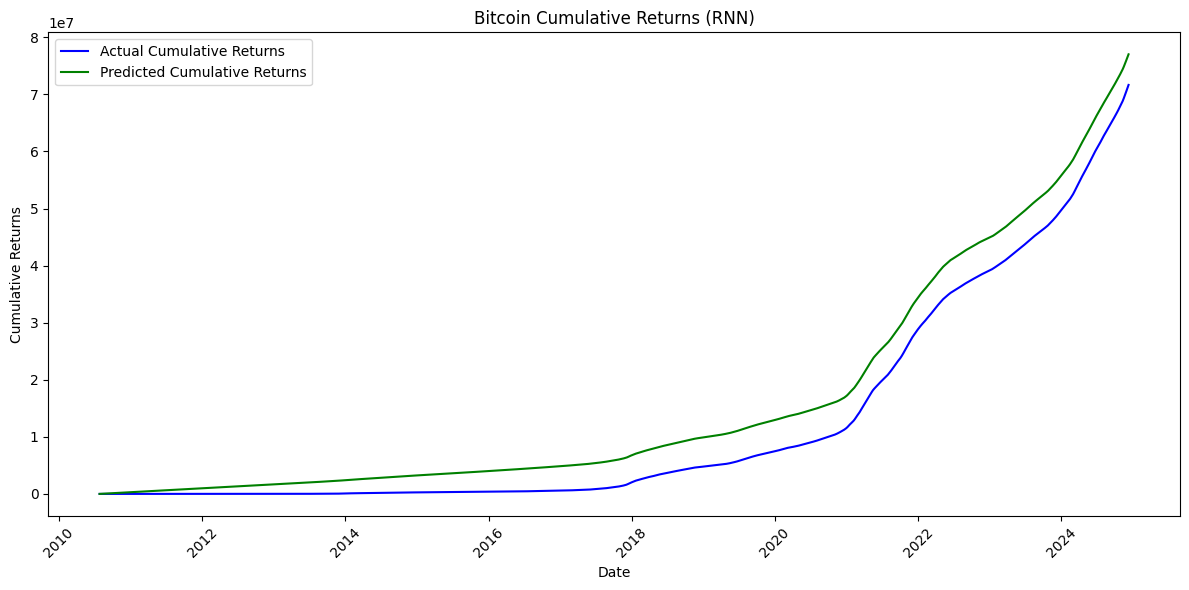

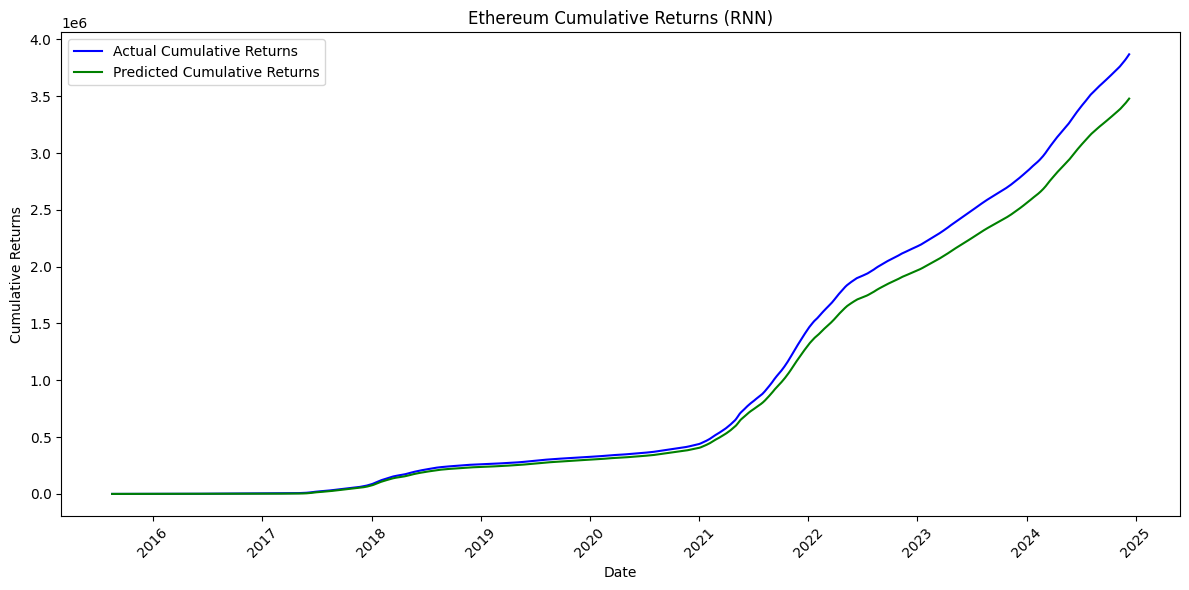

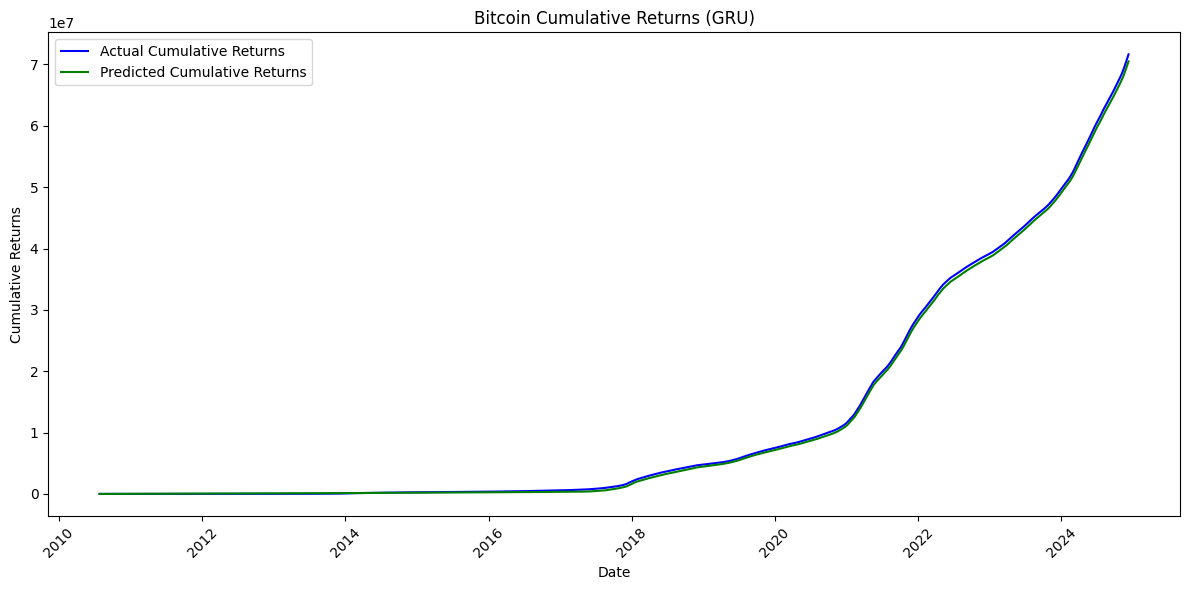

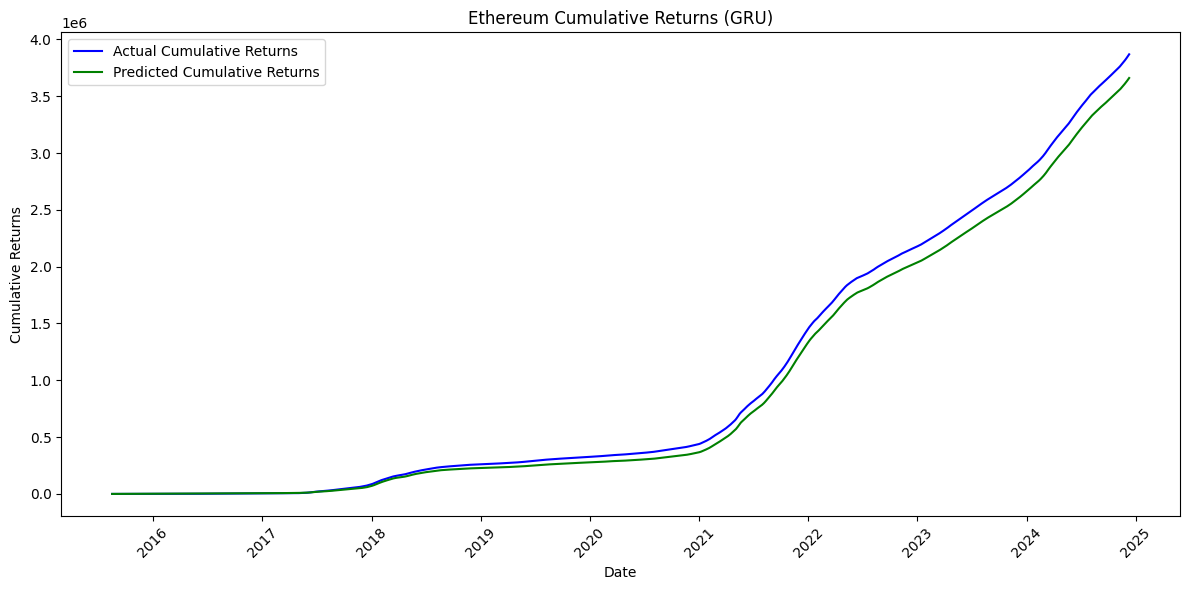

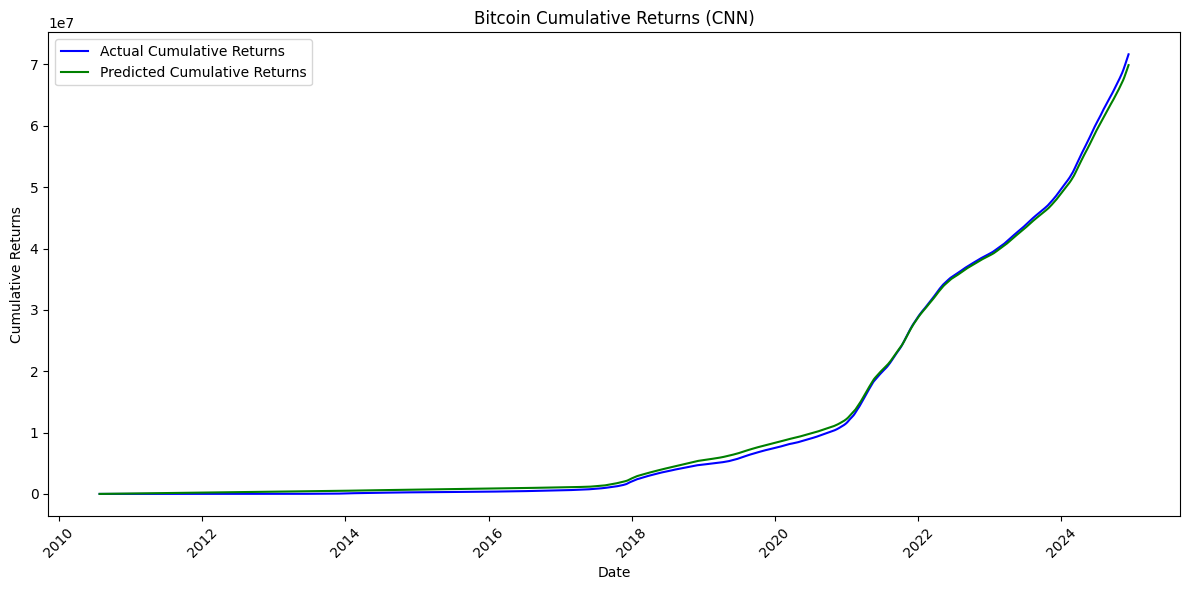

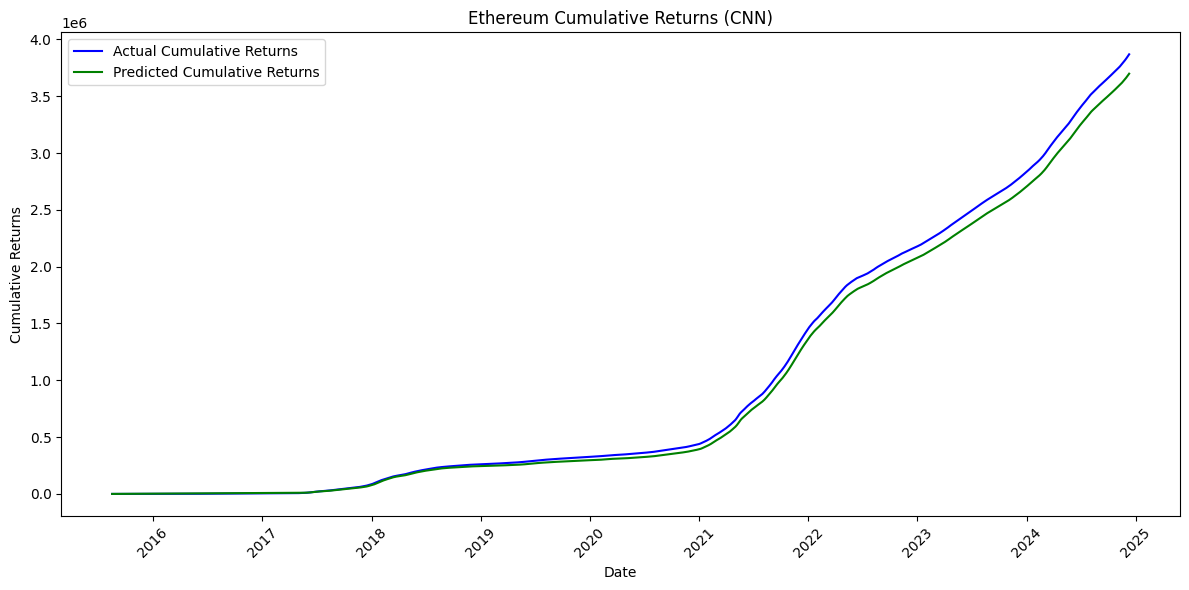

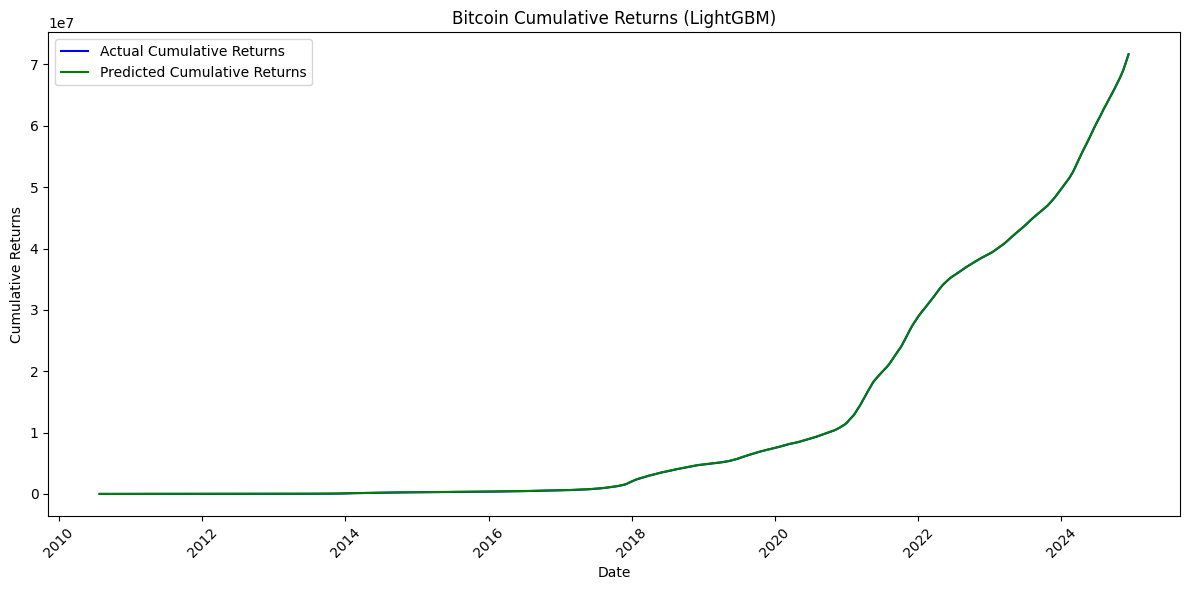

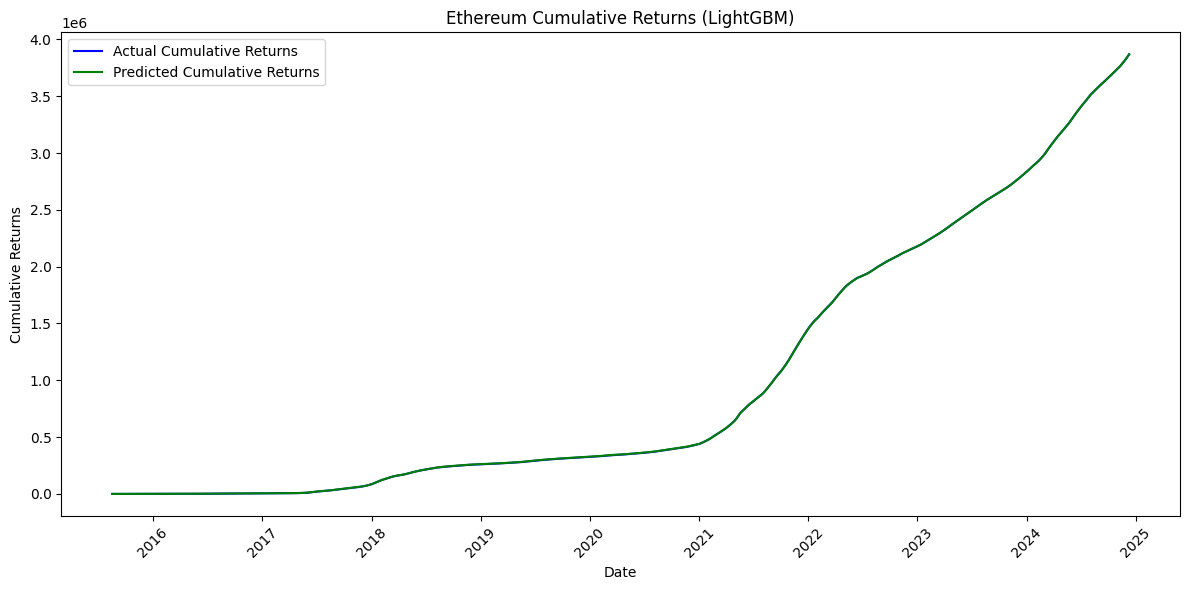

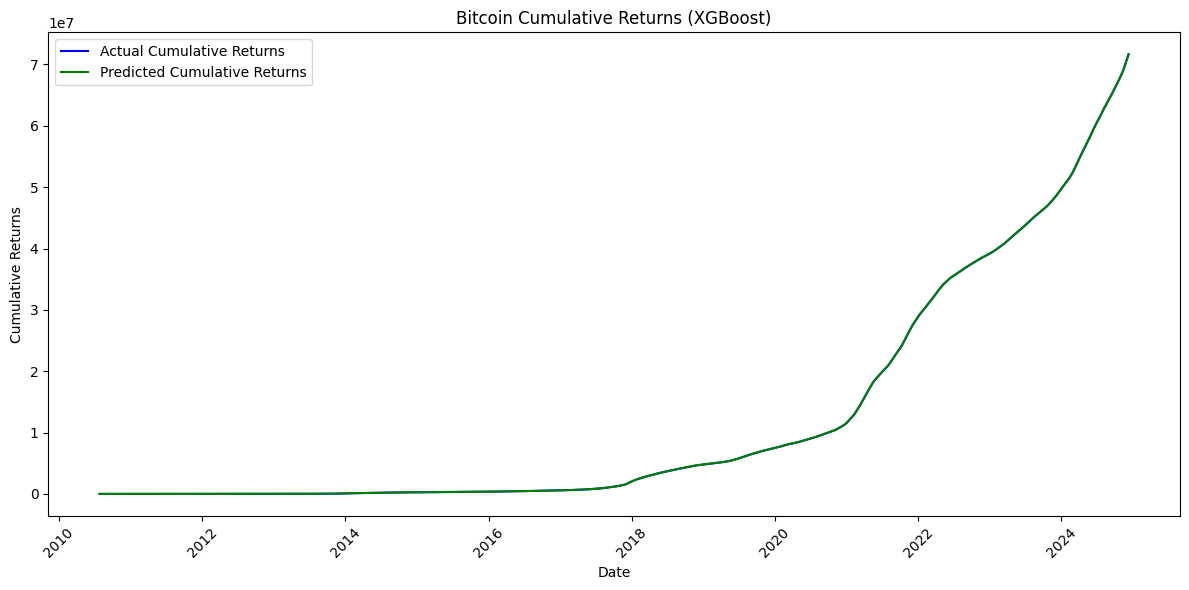

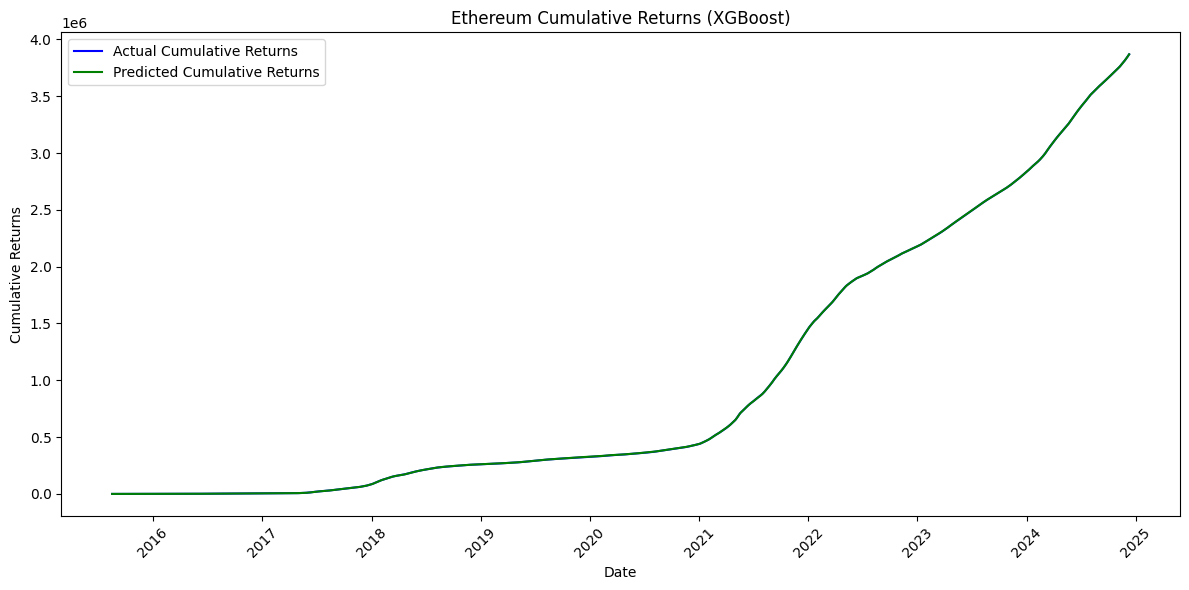

In [ ]:
# BTC and ETH - LSTM
plot_cumulative_returns(dates_btc, btc_lstm_actual, btc_lstm_pred, "Bitcoin Cumulative Returns (LSTM)")
plot_cumulative_returns(dates_eth, eth_lstm_actual, eth_lstm_pred, "Ethereum Cumulative Returns (LSTM)")

# BTC and ETH - RNN
plot_cumulative_returns(dates_btc, btc_rnn_actual, btc_rnn_pred, "Bitcoin Cumulative Returns (RNN)")
plot_cumulative_returns(dates_eth, eth_rnn_actual, eth_rnn_pred, "Ethereum Cumulative Returns (RNN)")

# BTC and ETH - GRU
plot_cumulative_returns(dates_btc, btc_gru_actual, btc_gru_pred, "Bitcoin Cumulative Returns (GRU)")
plot_cumulative_returns(dates_eth, eth_gru_actual, eth_gru_pred, "Ethereum Cumulative Returns (GRU)")

# BTC and ETH - CNN
plot_cumulative_returns(dates_btc, btc_cnn_actual, btc_cnn_pred, "Bitcoin Cumulative Returns (CNN)")
plot_cumulative_returns(dates_eth, eth_cnn_actual, eth_cnn_pred, "Ethereum Cumulative Returns (CNN)")

# BTC and ETH - LightGBM
plot_cumulative_returns(dates_btc, btc_lgbm_actual, btc_lgbm_pred, "Bitcoin Cumulative Returns (LightGBM)")
plot_cumulative_returns(dates_eth, eth_lgbm_actual, eth_lgbm_pred, "Ethereum Cumulative Returns (LightGBM)")

# BTC and ETH - XGBoost
plot_cumulative_returns(dates_btc, btc_xgb_actual, btc_xgb_pred, "Bitcoin Cumulative Returns (XGBoost)")
plot_cumulative_returns(dates_eth, eth_xgb_actual, eth_xgb_pred, "Ethereum Cumulative Returns (XGBoost)")

In [ ]:
def save_cumulative_returns_to_csv(ticker, model_name, dates, actual, predictions, filename="/content/cumulative_returns_results.csv"):
    file_exists = False
    try:
        with open(filename, "r", encoding="utf-8"):
            file_exists = True
    except FileNotFoundError:
        pass

    with open(filename, mode='a', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        if not file_exists:
            writer.writerow(["ticker", "model", "date", "actual_cumulative_return", "predicted_cumulative_return"])

        actual_returns = np.cumsum([float(act) for act in actual])
        predicted_returns = np.cumsum([float(pred) for pred in predictions])

        for date, act_ret, pred_ret in zip(dates, actual_returns, predicted_returns):
            formatted_date = str(date).split("T")[0]
            writer.writerow([ticker, model_name, formatted_date, float(act_ret), float(pred_ret)])  # Konwersja na liczby

In [ ]:
# BTC and ETH - LSTM
save_cumulative_returns_to_csv("BTC", "LSTM", dates_btc, btc_lstm_actual, btc_lstm_pred)
save_cumulative_returns_to_csv("ETH", "LSTM", dates_eth, eth_lstm_actual, eth_lstm_pred)

# BTC and ETH - RNN
save_cumulative_returns_to_csv("BTC", "RNN", dates_btc, btc_rnn_actual, btc_rnn_pred)
save_cumulative_returns_to_csv("ETH", "RNN", dates_eth, eth_rnn_actual, eth_rnn_pred)

# BTC and ETH - GRU
save_cumulative_returns_to_csv("BTC", "GRU", dates_btc, btc_gru_actual, btc_gru_pred)
save_cumulative_returns_to_csv("ETH", "GRU", dates_eth, eth_gru_actual, eth_gru_pred)

# BTC and ETH - CNN
save_cumulative_returns_to_csv("BTC", "CNN", dates_btc, btc_cnn_actual, btc_cnn_pred)
save_cumulative_returns_to_csv("ETH", "CNN", dates_eth, eth_cnn_actual, eth_cnn_pred)

# BTC and ETH - LightGBM
save_cumulative_returns_to_csv("BTC", "LightGBM", dates_btc, btc_lgbm_actual, btc_lgbm_pred)
save_cumulative_returns_to_csv("ETH", "LightGBM", dates_eth, eth_lgbm_actual, eth_lgbm_pred)

# BTC and ETH - XGBoost
save_cumulative_returns_to_csv("BTC", "XGBoost", dates_btc, btc_xgb_actual, btc_xgb_pred)
save_cumulative_returns_to_csv("ETH", "XGBoost", dates_eth, eth_xgb_actual, eth_xgb_pred)

<ipython-input-60-3afbe6a9b649>:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual_returns = np.cumsum([float(act) for act in actual])
<ipython-input-60-3afbe6a9b649>:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_returns = np.cumsum([float(pred) for pred in predictions])


In [ ]:
df = pd.read_csv("/content/models_residuals_results.csv")
print(df)

      ticker    model        date      actual    predicted   residuals
0        BTC     LSTM  2010-07-27     0.06000   393.586487 -393.526487
1        BTC     LSTM  2010-07-28     0.05890   393.587982 -393.529082
2        BTC     LSTM  2010-07-29     0.06990   393.585358 -393.515458
3        BTC     LSTM  2010-07-30     0.06270   393.582733 -393.520033
4        BTC     LSTM  2010-07-31     0.06785   393.581238 -393.513388
...      ...      ...         ...         ...          ...         ...
51913    ETH  XGBoost  2024-12-05  3810.87000  3814.437012   -3.567012
51914    ETH  XGBoost  2024-12-06  4029.36000  4016.336182   13.023818
51915    ETH  XGBoost  2024-12-07  4002.99000  3997.451416    5.538584
51916    ETH  XGBoost  2024-12-08  4012.79000  4005.697998    7.092002
51917    ETH  XGBoost  2024-12-09  3716.70000  3735.852783  -19.152783

[51918 rows x 6 columns]
